# Marketing Mix Modeling with Meridian and SHAP Explainability

## Project Objective

This project develops a Marketing Mix Model for a multi-channel eCommerce company. The analysis estimates channel contributions, ROI, marginal ROI, saturation effects, SHAP-based feature importance, and future advertising budget scenarios.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
TABLE_DIR = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "reports"

CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /home/muzzamil/Documents/duuaproject/marketing_mmm_project
Data directory: /home/muzzamil/Documents/duuaproject/marketing_mmm_project/data


## Task 1: Exploratory Data Analysis

### 1.1 Load the Dataset

The raw dataset and data dictionary are loaded to inspect their structure, variables, and overall data quality.

In [2]:
DATA_PATH = DATA_DIR / "conjura_mmm_data.csv"
DICTIONARY_PATH = DATA_DIR / "conjura_mmm_data_dictionary.xlsx"

df = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_excel(DICTIONARY_PATH)

print("Dataset shape:", df.shape)
print("Data dictionary shape:", data_dictionary.shape)

display(df.head())
display(data_dictionary.head(20))

Dataset shape: (132759, 50)
Data dictionary shape: (29, 3)


,MMM_TIMESERIES_ID,ORGANISATION_ID,ORGANISATION_VERTICAL,ORGANISATION_SUBVERTICAL,ORGANISATION_MARKETING_SOURCES,ORGANISATION_PRIMARY_TERRITORY_NAME,TERRITORY_NAME,DATE_DAY,CURRENCY_CODE,FIRST_PURCHASES,FIRST_PURCHASES_UNITS,FIRST_PURCHASES_ORIGINAL_PRICE,FIRST_PURCHASES_GROSS_DISCOUNT,ALL_PURCHASES,ALL_PURCHASES_UNITS,ALL_PURCHASES_ORIGINAL_PRICE,ALL_PURCHASES_GROSS_DISCOUNT,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND,GOOGLE_PAID_SEARCH_CLICKS,GOOGLE_SHOPPING_CLICKS,GOOGLE_PMAX_CLICKS,GOOGLE_DISPLAY_CLICKS,GOOGLE_VIDEO_CLICKS,META_FACEBOOK_CLICKS,META_INSTAGRAM_CLICKS,META_OTHER_CLICKS,TIKTOK_CLICKS,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_DISPLAY_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,META_OTHER_IMPRESSIONS,TIKTOK_IMPRESSIONS,DIRECT_CLICKS,BRANDED_SEARCH_CLICKS,ORGANIC_SEARCH_CLICKS,EMAIL_CLICKS,REFERRAL_CLICKS,ALL_OTHER_CLICKS
0,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-29,USD,22,27,3837.980834,632.595555,27,32,4552.984240,846.593069,NaN,NaN,205.528905,NaN,NaN,233.75,NaN,NaN,NaN,NaN,NaN,255.0,NaN,NaN,163.0,NaN,NaN,NaN,NaN,NaN,31907.0,NaN,NaN,18997.0,NaN,NaN,NaN,139.0,NaN,300.0,1.0,61.0,40.0
1,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-30,USD,14,21,2747.998631,443.996522,17,26,3177.998032,613.806522,NaN,NaN,277.082025,NaN,NaN,248.84,NaN,NaN,NaN,NaN,NaN,348.0,NaN,NaN,128.0,NaN,NaN,NaN,NaN,NaN,44483.0,NaN,NaN,20188.0,NaN,NaN,NaN,209.0,NaN,442.0,8.0,110.0,62.0
2,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-07-31,USD,31,39,4567.998818,1185.197966,39,48,5468.998818,1504.997966,NaN,NaN,427.436429,NaN,NaN,274.51,NaN,NaN,NaN,NaN,NaN,405.0,NaN,NaN,148.0,NaN,NaN,NaN,NaN,NaN,58173.0,NaN,NaN,24718.0,NaN,NaN,NaN,262.0,NaN,427.0,631.0,108.0,65.0
3,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-01,USD,18,30,2878.982385,696.519993,22,34,3335.970202,754.410747,35.24,NaN,347.232798,NaN,NaN,270.06,NaN,NaN,NaN,48.0,NaN,320.0,NaN,NaN,163.0,NaN,NaN,NaN,890.0,NaN,55559.0,NaN,NaN,25076.0,NaN,NaN,NaN,247.0,NaN,400.0,117.0,125.0,68.0
4,596eef7c71f933d820d0e485935d0e8f,04769dac8b828ec7a85676d9e2bffe6f,Beauty & Fitness,Hair Care,"Google, Meta",US,All Territories,2022-08-02,USD,23,27,3107.993669,627.097427,28,33,3991.987441,934.011083,38.40,NaN,314.952971,NaN,NaN,257.62,NaN,NaN,NaN,46.0,NaN,330.0,NaN,NaN,127.0,NaN,NaN,NaN,702.0,NaN,47854.0,NaN,NaN,22688.0,NaN,NaN,NaN,255.0,NaN,425.0,37.0,146.0,65.0


,Field,Definition,Notes
0,mmm_timeseries_id,unique identifier for a single MMM timeseries.,if aggregating accross multiple timeseries IDs...
1,organisation_id,"unique, anonymous identifier for an eCommerce ...",NaN
2,organisation_vertical,the top-level category of the highest selling ...,categorisation follows Google's eCommerce taxo...
3,organisation_subvertical,the sub-category of the highest selling products,""""""
4,organisation_marketing_sources,"at least one of Google, Meta, and/or Tiktok",spend from listed sources may not be present i...
5,organisation_primary_territory_name,the organisation's territory with the highest ...,NaN
6,territory_name,"values include mult-country ""All Territories"" ...","some orgs will have multiple territory spits, ..."
7,currency_code,currency for monetary fields,"when territory_name = ""all territories"" we use..."
8,date_day,observation date,each timeseries has a minimum of 449 sequentia...
9,first_purchases,"number of web purchases for new customers, i.e...",NaN


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['MMM_TIMESERIES_ID', 'ORGANISATION_ID', 'ORGANISATION_VERTICAL', 'ORGANISATION_SUBVERTICAL', 'ORGANISATION_MARKETING_SOURCES', 'ORGANISATION_PRIMARY_TERRITORY_NAME', 'TERRITORY_NAME', 'DATE_DAY', 'CURRENCY_CODE', 'FIRST_PURCHASES', 'FIRST_PURCHASES_UNITS', 'FIRST_PURCHASES_ORIGINAL_PRICE', 'FIRST_PURCHASES_GROSS_DISCOUNT', 'ALL_PURCHASES', 'ALL_PURCHASES_UNITS', 'ALL_PURCHASES_ORIGINAL_PRICE', 'ALL_PURCHASES_GROSS_DISCOUNT', 'GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_DISPLAY_SPEND', 'GOOGLE_VIDEO_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND', 'META_OTHER_SPEND', 'TIKTOK_SPEND', 'GOOGLE_PAID_SEARCH_CLICKS', 'GOOGLE_SHOPPING_CLICKS', 'GOOGLE_PMAX_CLICKS', 'GOOGLE_DISPLAY_CLICKS', 'GOOGLE_VIDEO_CLICKS', 'META_FACEBOOK_CLICKS', 'META_INSTAGRAM_CLICKS', 'META_OTHER_CLICKS', 'TIKTOK_CLICKS', 'GOOGLE_PAID_SEARCH_IMPRESSIONS', 'GOOGLE_SHOPPING_IMPRESSIONS', 'GOOGLE_PMAX_IMPRESSIONS', 'GOOGLE_DISPLAY_IMPRESSIONS', 'GOOGLE_VIDEO_IMPRE

In [4]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique()
}).sort_values("missing_percentage", ascending=False)

display(summary)

,dtype,missing_count,missing_percentage,unique_values
TIKTOK_CLICKS,float64,129297,97.39,1044
TIKTOK_SPEND,float64,129297,97.39,2487
TIKTOK_IMPRESSIONS,float64,129297,97.39,2806
GOOGLE_VIDEO_SPEND,float64,125131,94.25,5853
GOOGLE_VIDEO_IMPRESSIONS,float64,125131,94.25,5932
GOOGLE_VIDEO_CLICKS,float64,125131,94.25,737
GOOGLE_DISPLAY_SPEND,float64,114013,85.88,8906
GOOGLE_DISPLAY_CLICKS,float64,114013,85.88,832
GOOGLE_DISPLAY_IMPRESSIONS,float64,114013,85.88,11496
META_OTHER_CLICKS,float64,109214,82.26,123


### Initial Data Quality Findings

The dataset contains 132,759 daily observations and 50 variables.

The target variables, including `ALL_PURCHASES` and
`ALL_PURCHASES_ORIGINAL_PRICE`, contain no missing values. Missing values are
mainly concentrated in media spend, click, and impression columns.

This pattern suggests structural missingness: not every organization used every
marketing channel throughout the observation period. Therefore, missing media
values will be evaluated after selecting the organization for modeling rather
than being filled globally.

In [5]:
df["DATE_DAY"] = pd.to_datetime(df["DATE_DAY"])

print("Date range:")
print(df["DATE_DAY"].min(), "to", df["DATE_DAY"].max())

print("\nNumber of organizations:", df["ORGANISATION_ID"].nunique())
print("Number of time series:", df["MMM_TIMESERIES_ID"].nunique())
print("Number of territories:", df["TERRITORY_NAME"].nunique())
print("Number of currencies:", df["CURRENCY_CODE"].nunique())

duplicate_count = df.duplicated(
    subset=["MMM_TIMESERIES_ID", "DATE_DAY"]
).sum()

print("\nDuplicate time-series/date rows:", duplicate_count)

Date range:
2019-07-21 00:00:00 to 2024-06-02 00:00:00

Number of organizations: 93
Number of time series: 143
Number of territories: 19
Number of currencies: 14

Duplicate time-series/date rows: 0


In [6]:
spend_columns = [
    column for column in df.columns
    if column.endswith("_SPEND")
]

click_columns = [
    column for column in df.columns
    if column.endswith("_CLICKS")
]

impression_columns = [
    column for column in df.columns
    if column.endswith("_IMPRESSIONS")
]

print("Spend columns:", len(spend_columns))
print(spend_columns)

print("\nClick columns:", len(click_columns))
print(click_columns)

print("\nImpression columns:", len(impression_columns))
print(impression_columns)

Spend columns: 9
['GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_DISPLAY_SPEND', 'GOOGLE_VIDEO_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND', 'META_OTHER_SPEND', 'TIKTOK_SPEND']

Click columns: 15
['GOOGLE_PAID_SEARCH_CLICKS', 'GOOGLE_SHOPPING_CLICKS', 'GOOGLE_PMAX_CLICKS', 'GOOGLE_DISPLAY_CLICKS', 'GOOGLE_VIDEO_CLICKS', 'META_FACEBOOK_CLICKS', 'META_INSTAGRAM_CLICKS', 'META_OTHER_CLICKS', 'TIKTOK_CLICKS', 'DIRECT_CLICKS', 'BRANDED_SEARCH_CLICKS', 'ORGANIC_SEARCH_CLICKS', 'EMAIL_CLICKS', 'REFERRAL_CLICKS', 'ALL_OTHER_CLICKS']

Impression columns: 9
['GOOGLE_PAID_SEARCH_IMPRESSIONS', 'GOOGLE_SHOPPING_IMPRESSIONS', 'GOOGLE_PMAX_IMPRESSIONS', 'GOOGLE_DISPLAY_IMPRESSIONS', 'GOOGLE_VIDEO_IMPRESSIONS', 'META_FACEBOOK_IMPRESSIONS', 'META_INSTAGRAM_IMPRESSIONS', 'META_OTHER_IMPRESSIONS', 'TIKTOK_IMPRESSIONS']


In [7]:
organisation_profile = (
    df.groupby("ORGANISATION_ID")
      .agg(
          rows=("DATE_DAY", "size"),
          time_series=("MMM_TIMESERIES_ID", "nunique"),
          territories=("TERRITORY_NAME", "nunique"),
          currencies=("CURRENCY_CODE", "nunique"),
          start_date=("DATE_DAY", "min"),
          end_date=("DATE_DAY", "max"),
          total_purchases=("ALL_PURCHASES", "sum"),
          vertical=("ORGANISATION_VERTICAL", "first"),
          subvertical=("ORGANISATION_SUBVERTICAL", "first"),
          primary_territory=("ORGANISATION_PRIMARY_TERRITORY_NAME", "first"),
      )
)

organisation_profile["calendar_days"] = (
    organisation_profile["end_date"]
    - organisation_profile["start_date"]
).dt.days + 1

organisation_profile["coverage_ratio"] = (
    organisation_profile["rows"]
    / (
        organisation_profile["calendar_days"]
        * organisation_profile["time_series"]
    )
)

organisation_spend = (
    df.groupby("ORGANISATION_ID")[spend_columns]
      .sum(min_count=1)
      .fillna(0)
)

organisation_profile["active_paid_channels"] = (
    organisation_spend.gt(0).sum(axis=1)
)

organisation_profile = organisation_profile.sort_values(
    ["calendar_days", "active_paid_channels", "total_purchases"],
    ascending=False
)

display(organisation_profile.head(15))

,rows,time_series,territories,currencies,start_date,end_date,total_purchases,vertical,subvertical,primary_territory,calendar_days,coverage_ratio,active_paid_channels
ORGANISATION_ID,,,,,,,,,,,,,
72a86a208d24d68b80be0e44a8a4872d,1751,1,1,1,2019-08-16,2024-05-31,55405,Autos & Vehicles,Parts & Services,US,1751,1.000000,4
882ce7e286d66facc66518783e2192c7,9342,7,7,4,2019-09-27,2024-06-02,1181831,Beauty & Fitness,Face & Body Care,UK,1711,0.779995,6
bfb6f6a326141ed6a751fc83ba836984,1654,1,1,1,2019-11-23,2024-06-02,495035,Home & Garden,Home Improvement,UK,1654,1.000000,5
7059e30b528ed5f14ee9921de13248e5,1642,1,1,1,2019-11-22,2024-05-20,169714,Home & Garden,Bed & Bath,UK,1642,1.000000,6
ba773ebd7ec0a08f1d042187d086ccb4,16228,13,13,7,2020-01-06,2024-06-02,2007029,Business & Industrial,Business Services,UK,1610,0.775346,8
2b15eedfc4faa6293dc4b3bf8c1c9c1f,1576,1,1,1,2020-02-05,2024-05-29,20415,Apparel,Clothing Accessories,US,1576,1.000000,7
09113a73f8618b48b3cf53b24cd78d2f,1450,1,1,1,2020-06-14,2024-06-02,171705,Apparel,Footwear,US,1450,1.000000,8
75d7dc601d55a71ee1d7932b560934ed,1438,1,1,1,2020-06-12,2024-05-19,46327,Apparel,Children's Clothing,UK,1438,1.000000,4
76d1d35d893b943b098102e5e32f30ce,1425,1,1,1,2020-06-25,2024-05-19,61517,Apparel,Women's Clothing,UK,1425,1.000000,5


In [8]:
candidate_organisations = organisation_profile[
    (organisation_profile["time_series"] == 1)
    & (organisation_profile["currencies"] == 1)
    & (organisation_profile["calendar_days"] >= 730)
    & (organisation_profile["coverage_ratio"] >= 0.95)
    & (organisation_profile["active_paid_channels"] >= 4)
].copy()

display(
    candidate_organisations[
        [
            "rows",
            "calendar_days",
            "coverage_ratio",
            "active_paid_channels",
            "total_purchases",
            "vertical",
            "subvertical",
            "primary_territory",
        ]
    ].head(15)
)

,rows,calendar_days,coverage_ratio,active_paid_channels,total_purchases,vertical,subvertical,primary_territory
ORGANISATION_ID,,,,,,,,
72a86a208d24d68b80be0e44a8a4872d,1751,1751,1.0,4,55405,Autos & Vehicles,Parts & Services,US
bfb6f6a326141ed6a751fc83ba836984,1654,1654,1.0,5,495035,Home & Garden,Home Improvement,UK
7059e30b528ed5f14ee9921de13248e5,1642,1642,1.0,6,169714,Home & Garden,Bed & Bath,UK
2b15eedfc4faa6293dc4b3bf8c1c9c1f,1576,1576,1.0,7,20415,Apparel,Clothing Accessories,US
09113a73f8618b48b3cf53b24cd78d2f,1450,1450,1.0,8,171705,Apparel,Footwear,US
75d7dc601d55a71ee1d7932b560934ed,1438,1438,1.0,4,46327,Apparel,Children's Clothing,UK
76d1d35d893b943b098102e5e32f30ce,1425,1425,1.0,5,61517,Apparel,Women's Clothing,UK
200b4005ea8477754ef37438e66b2f4c,1375,1375,1.0,6,433336,Toys & Hobbies,Other,UK
098228bbe36aa86c8592de76f2447959,1369,1369,1.0,4,20966,Home & Garden,Kitchen & Dining,UK


### 1.2 Organization Selection

The dataset contains multiple anonymous organizations operating across different
territories and currencies. A single organization will be selected to avoid
mixing currencies, business models, and unrelated demand patterns.

The selection criteria are:

- One continuous daily time series
- One territory and one currency
- At least two years of observations
- Several consistently active paid-media channels
- Sufficient purchase volume and variation
- Minimal gaps in the daily timeline

In [9]:
candidate_ids = [
    "09113a73f8618b48b3cf53b24cd78d2f",
    "df208255d3c8eea8d60fb4ae697d20de",
    "2b15eedfc4faa6293dc4b3bf8c1c9c1f",
    "088510f2efdfd515473f8db631b732e6",
    "3fb90b66bd509e5c19fb5353d34fae3f",
    "7059e30b528ed5f14ee9921de13248e5",
]

candidate_rows = []

for organisation_id in candidate_ids:
    org_df = df[df["ORGANISATION_ID"] == organisation_id].copy()

    spend_data = org_df[spend_columns].fillna(0)

    positive_days = (spend_data > 0).sum()
    channels_with_30_days = (positive_days >= 30).sum()
    channels_with_90_days = (positive_days >= 90).sum()

    candidate_rows.append({
        "organisation_id": organisation_id,
        "vertical": org_df["ORGANISATION_VERTICAL"].iloc[0],
        "subvertical": org_df["ORGANISATION_SUBVERTICAL"].iloc[0],
        "territory": org_df["TERRITORY_NAME"].iloc[0],
        "currency": org_df["CURRENCY_CODE"].iloc[0],
        "days": len(org_df),
        "total_purchases": org_df["ALL_PURCHASES"].sum(),
        "mean_daily_purchases": org_df["ALL_PURCHASES"].mean(),
        "purchase_std": org_df["ALL_PURCHASES"].std(),
        "zero_purchase_days": (org_df["ALL_PURCHASES"] == 0).sum(),
        "total_paid_spend": spend_data.sum().sum(),
        "channels_30_plus_days": channels_with_30_days,
        "channels_90_plus_days": channels_with_90_days,
    })

candidate_comparison = pd.DataFrame(candidate_rows).set_index(
    "organisation_id"
)

display(
    candidate_comparison.sort_values(
        ["channels_90_plus_days", "days", "total_purchases"],
        ascending=False
    )
)

,vertical,subvertical,territory,currency,days,total_purchases,mean_daily_purchases,purchase_std,zero_purchase_days,total_paid_spend,channels_30_plus_days,channels_90_plus_days
organisation_id,,,,,,,,,,,,
df208255d3c8eea8d60fb4ae697d20de,Beauty & Fitness,Face & Body Care,All Territories,USD,1276,359805,281.978840,166.332170,0,9.071030e+06,8,8
2b15eedfc4faa6293dc4b3bf8c1c9c1f,Apparel,Clothing Accessories,All Territories,USD,1576,20415,12.953680,10.094525,0,8.960680e+05,7,7
3fb90b66bd509e5c19fb5353d34fae3f,Apparel,Athletic Apparel,All Territories,GBP,1227,254906,207.747351,138.290500,0,1.883507e+06,7,7
09113a73f8618b48b3cf53b24cd78d2f,Apparel,Footwear,All Territories,USD,1450,171705,118.417241,82.598928,0,8.644951e+05,8,6
088510f2efdfd515473f8db631b732e6,Home & Garden,Home Appliances,All Territories,GBP,1278,28745,22.492175,12.757955,0,1.597299e+05,6,6
7059e30b528ed5f14ee9921de13248e5,Home & Garden,Bed & Bath,All Territories,GBP,1642,169714,103.358100,65.882744,0,2.076258e+06,6,5


In [10]:
channel_coverage_tables = []

for organisation_id in candidate_ids:
    org_df = df[df["ORGANISATION_ID"] == organisation_id]

    positive_spend_days = (
        org_df[spend_columns]
        .fillna(0)
        .gt(0)
        .sum()
    )

    coverage_percentage = (
        positive_spend_days / len(org_df) * 100
    ).round(1)

    channel_coverage_tables.append(
        coverage_percentage.rename(organisation_id)
    )

channel_coverage = pd.concat(
    channel_coverage_tables,
    axis=1
).T

display(channel_coverage)

,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_DISPLAY_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,META_OTHER_SPEND,TIKTOK_SPEND
09113a73f8618b48b3cf53b24cd78d2f,27.4,47.4,53.2,2.6,6.1,99.7,19.0,7.0,0.0
df208255d3c8eea8d60fb4ae697d20de,96.6,77.5,48.3,7.1,28.8,100.0,94.0,93.7,0.0
2b15eedfc4faa6293dc4b3bf8c1c9c1f,38.2,85.7,22.1,14.3,0.0,98.5,39.0,22.5,0.0
088510f2efdfd515473f8db631b732e6,61.5,98.6,10.5,1.4,14.9,82.1,8.6,0.0,0.0
3fb90b66bd509e5c19fb5353d34fae3f,97.2,81.3,14.8,36.8,0.0,92.7,22.1,21.4,0.0
7059e30b528ed5f14ee9921de13248e5,100.0,27.3,38.7,4.6,20.0,94.6,0.0,0.0,0.0


### Final Organization Selection

The organization `df208255d3c8eea8d60fb4ae697d20de` was selected for the
Marketing Mix Model.

It represents a Beauty & Fitness company operating in the Face & Body Care
subcategory. The dataset contains 1,276 consecutive daily observations in USD
and is reported at the "All Territories" level.

This organization was selected because it provides:

- A continuous daily time series with no missing calendar dates
- A single currency, avoiding currency conversion issues
- High purchase volume and meaningful daily variation
- No zero-purchase days
- Broad and sustained activity across several paid-media channels
- Sufficient historical length to model seasonality, adstock, and saturation

Although other organizations contain longer time periods, this organization
offers the strongest combination of media coverage, purchase volume, and
channel diversity.

In [11]:
SELECTED_ORGANISATION = "df208255d3c8eea8d60fb4ae697d20de"

brand_df = (
    df.loc[df["ORGANISATION_ID"] == SELECTED_ORGANISATION]
      .copy()
      .sort_values("DATE_DAY")
      .reset_index(drop=True)
)

print("Selected rows:", len(brand_df))
print(
    "Date range:",
    brand_df["DATE_DAY"].min(),
    "to",
    brand_df["DATE_DAY"].max()
)
print("Territory:", brand_df["TERRITORY_NAME"].unique())
print("Currency:", brand_df["CURRENCY_CODE"].unique())
print("Vertical:", brand_df["ORGANISATION_VERTICAL"].unique())
print("Subvertical:", brand_df["ORGANISATION_SUBVERTICAL"].unique())

display(
    brand_df[
        [
            "DATE_DAY",
            "ALL_PURCHASES",
            "ALL_PURCHASES_ORIGINAL_PRICE",
            "GOOGLE_PAID_SEARCH_SPEND",
            "GOOGLE_SHOPPING_SPEND",
            "GOOGLE_PMAX_SPEND",
            "META_FACEBOOK_SPEND",
            "META_INSTAGRAM_SPEND",
        ]
    ].head()
)

Selected rows: 1276
Date range: 2020-11-21 00:00:00 to 2024-05-19 00:00:00
Territory: ['All Territories']
Currency: ['USD']
Vertical: ['Beauty & Fitness']
Subvertical: ['Face & Body Care']


,DATE_DAY,ALL_PURCHASES,ALL_PURCHASES_ORIGINAL_PRICE,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND
0,2020-11-21,87,11339.006630,95.38,773.82,NaN,1138.970648,NaN
1,2020-11-22,155,23078.991668,100.88,491.87,NaN,4486.452133,NaN
2,2020-11-23,165,22954.006947,123.95,384.94,NaN,3835.775893,NaN
3,2020-11-24,113,17747.000080,83.74,337.96,NaN,2651.402842,NaN
4,2020-11-25,95,15592.004580,140.29,485.03,NaN,2324.369601,NaN


In [12]:
expected_dates = pd.date_range(
    start=brand_df["DATE_DAY"].min(),
    end=brand_df["DATE_DAY"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(brand_df["DATE_DAY"])

print("Expected calendar days:", len(expected_dates))
print("Observed calendar days:", len(brand_df))
print("Missing calendar days:", len(missing_dates))

Expected calendar days: 1276
Observed calendar days: 1276
Missing calendar days: 0


In [13]:
channel_spend_summary = pd.DataFrame({
    "total_spend": brand_df[spend_columns].fillna(0).sum(),
    "positive_spend_days": brand_df[spend_columns].fillna(0).gt(0).sum(),
    "average_daily_spend": brand_df[spend_columns].fillna(0).mean(),
    "median_active_day_spend": [
        brand_df.loc[
            brand_df[column].fillna(0) > 0,
            column
        ].median()
        for column in spend_columns
    ]
})

channel_spend_summary["spend_share_percentage"] = (
    channel_spend_summary["total_spend"]
    / channel_spend_summary["total_spend"].sum()
    * 100
).round(2)

channel_spend_summary["coverage_percentage"] = (
    channel_spend_summary["positive_spend_days"]
    / len(brand_df)
    * 100
).round(2)

channel_spend_summary = channel_spend_summary.sort_values(
    "total_spend",
    ascending=False
)

display(channel_spend_summary)

,total_spend,positive_spend_days,average_daily_spend,median_active_day_spend,spend_share_percentage,coverage_percentage
META_INSTAGRAM_SPEND,4.527417e+06,1200,3548.132369,4010.035000,49.91,94.04
META_FACEBOOK_SPEND,3.540410e+06,1276,2774.616341,2655.428722,39.03,100.00
GOOGLE_PAID_SEARCH_SPEND,4.397090e+05,1233,344.599517,259.427108,4.85,96.63
GOOGLE_PMAX_SPEND,3.459053e+05,616,271.085662,577.445550,3.81,48.28
GOOGLE_VIDEO_SPEND,1.241546e+05,367,97.299875,273.830000,1.37,28.76
GOOGLE_SHOPPING_SPEND,7.455050e+04,989,58.425158,27.260000,0.82,77.51
GOOGLE_DISPLAY_SPEND,1.377606e+04,91,10.796285,60.866707,0.15,7.13
META_OTHER_SPEND,5.107569e+03,1196,4.002797,2.718459,0.06,93.73
TIKTOK_SPEND,0.000000e+00,0,0.000000,NaN,0.00,0.00


In [14]:
channel_spend_summary.to_csv(
    TABLE_DIR / "channel_spend_summary.csv"
)

### Media Channel Selection

Six paid-media channels were retained for modeling:

- Google Paid Search
- Google Shopping
- Google PMAX
- Google Video
- Meta Facebook
- Meta Instagram

TikTok was excluded because it recorded no spend for the selected organization.
Google Display was excluded because it represented only 0.15% of total spend
and was active for approximately 7% of observed days. Meta Other was excluded
because it represented only 0.06% of spend and lacked a clearly interpretable
channel definition.

The retained channels provide the strongest combination of business relevance,
historical coverage, and sufficient spend variation for estimating media
effects.

### Spend Concentration Finding

Paid-media investment is heavily concentrated in Meta channels. Meta Instagram
accounts for approximately 49.91% of total spend, while Meta Facebook accounts
for 39.03%.

Together, Facebook and Instagram represent approximately 88.94% of total paid
media investment. This raises an important modeling question: whether this
concentration reflects superior incremental performance or whether the Meta
channels are approaching saturation.

In [16]:
MEDIA_CHANNELS = {
    "Google Paid Search": {
        "spend": "GOOGLE_PAID_SEARCH_SPEND",
        "clicks": "GOOGLE_PAID_SEARCH_CLICKS",
        "impressions": "GOOGLE_PAID_SEARCH_IMPRESSIONS",
    },
    "Google Shopping": {
        "spend": "GOOGLE_SHOPPING_SPEND",
        "clicks": "GOOGLE_SHOPPING_CLICKS",
        "impressions": "GOOGLE_SHOPPING_IMPRESSIONS",
    },
    "Google PMAX": {
        "spend": "GOOGLE_PMAX_SPEND",
        "clicks": "GOOGLE_PMAX_CLICKS",
        "impressions": "GOOGLE_PMAX_IMPRESSIONS",
    },
    "Google Video": {
        "spend": "GOOGLE_VIDEO_SPEND",
        "clicks": "GOOGLE_VIDEO_CLICKS",
        "impressions": "GOOGLE_VIDEO_IMPRESSIONS",
    },
    "Meta Facebook": {
        "spend": "META_FACEBOOK_SPEND",
        "clicks": "META_FACEBOOK_CLICKS",
        "impressions": "META_FACEBOOK_IMPRESSIONS",
    },
    "Meta Instagram": {
        "spend": "META_INSTAGRAM_SPEND",
        "clicks": "META_INSTAGRAM_CLICKS",
        "impressions": "META_INSTAGRAM_IMPRESSIONS",
    },
}

print("Selected media channels:", list(MEDIA_CHANNELS.keys()))

Selected media channels: ['Google Paid Search', 'Google Shopping', 'Google PMAX', 'Google Video', 'Meta Facebook', 'Meta Instagram']


In [17]:
selected_spend_columns = [
    details["spend"]
    for details in MEDIA_CHANNELS.values()
]

selected_click_columns = [
    details["clicks"]
    for details in MEDIA_CHANNELS.values()
]

selected_impression_columns = [
    details["impressions"]
    for details in MEDIA_CHANNELS.values()
]

selected_media_columns = (
    selected_spend_columns
    + selected_click_columns
    + selected_impression_columns
)

print("Selected spend columns:")
print(selected_spend_columns)

print("\nSelected click columns:")
print(selected_click_columns)

print("\nSelected impression columns:")
print(selected_impression_columns)

Selected spend columns:
['GOOGLE_PAID_SEARCH_SPEND', 'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_VIDEO_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND']

Selected click columns:
['GOOGLE_PAID_SEARCH_CLICKS', 'GOOGLE_SHOPPING_CLICKS', 'GOOGLE_PMAX_CLICKS', 'GOOGLE_VIDEO_CLICKS', 'META_FACEBOOK_CLICKS', 'META_INSTAGRAM_CLICKS']

Selected impression columns:
['GOOGLE_PAID_SEARCH_IMPRESSIONS', 'GOOGLE_SHOPPING_IMPRESSIONS', 'GOOGLE_PMAX_IMPRESSIONS', 'GOOGLE_VIDEO_IMPRESSIONS', 'META_FACEBOOK_IMPRESSIONS', 'META_INSTAGRAM_IMPRESSIONS']


In [18]:
exposure_quality = []

for channel_name, columns in MEDIA_CHANNELS.items():
    spend = brand_df[columns["spend"]].fillna(0)
    clicks = brand_df[columns["clicks"]].fillna(0)
    impressions = brand_df[columns["impressions"]].fillna(0)

    active_spend_mask = spend > 0

    exposure_quality.append({
        "channel": channel_name,
        "active_spend_days": int(active_spend_mask.sum()),
        "clicks_available_on_spend_days_pct": (
            (clicks[active_spend_mask] > 0).mean() * 100
        ),
        "impressions_available_on_spend_days_pct": (
            (impressions[active_spend_mask] > 0).mean() * 100
        ),
        "total_clicks": clicks.sum(),
        "total_impressions": impressions.sum(),
    })

exposure_quality_df = (
    pd.DataFrame(exposure_quality)
      .set_index("channel")
      .round(2)
)

display(exposure_quality_df)

,active_spend_days,clicks_available_on_spend_days_pct,impressions_available_on_spend_days_pct,total_clicks,total_impressions
channel,,,,,
Google Paid Search,1233,100.00,100.0,227019.0,4143918.0
Google Shopping,989,94.14,100.0,97508.0,20544912.0
Google PMAX,616,100.00,100.0,310064.0,25673539.0
Google Video,367,99.46,100.0,84370.0,13260225.0
Meta Facebook,1276,100.00,100.0,4284938.0,300639759.0
Meta Instagram,1200,100.00,100.0,3413986.0,426602846.0


### Media Exposure Selection

Impressions were selected as the media exposure variables for the Meridian
model.

Impressions are available on 100% of active-spend days for every retained
channel. Click data is slightly less complete for Google Shopping and Google
Video. Using impressions therefore provides a more consistent exposure measure
across channels.

Media spend will be supplied separately for ROI, marginal ROI, and budget
optimization analysis.

In [19]:
selected_exposure_columns = selected_impression_columns.copy()

media_channel_names = list(MEDIA_CHANNELS.keys())

print("Meridian media channels:")
for channel, exposure, spend in zip(
    media_channel_names,
    selected_exposure_columns,
    selected_spend_columns
):
    print(f"{channel}: {exposure} | {spend}")

Meridian media channels:
Google Paid Search: GOOGLE_PAID_SEARCH_IMPRESSIONS | GOOGLE_PAID_SEARCH_SPEND
Google Shopping: GOOGLE_SHOPPING_IMPRESSIONS | GOOGLE_SHOPPING_SPEND
Google PMAX: GOOGLE_PMAX_IMPRESSIONS | GOOGLE_PMAX_SPEND
Google Video: GOOGLE_VIDEO_IMPRESSIONS | GOOGLE_VIDEO_SPEND
Meta Facebook: META_FACEBOOK_IMPRESSIONS | META_FACEBOOK_SPEND
Meta Instagram: META_INSTAGRAM_IMPRESSIONS | META_INSTAGRAM_SPEND


In [20]:
eda_df = brand_df.copy()

columns_to_fill = (
    selected_spend_columns
    + selected_exposure_columns
    + selected_click_columns
)

eda_df[columns_to_fill] = eda_df[columns_to_fill].fillna(0)

selected_missing_summary = pd.DataFrame({
    "missing_before": brand_df[columns_to_fill].isna().sum(),
    "missing_after": eda_df[columns_to_fill].isna().sum(),
})

display(selected_missing_summary)

,missing_before,missing_after
GOOGLE_PAID_SEARCH_SPEND,43,0
GOOGLE_SHOPPING_SPEND,264,0
GOOGLE_PMAX_SPEND,660,0
GOOGLE_VIDEO_SPEND,909,0
META_FACEBOOK_SPEND,0,0
META_INSTAGRAM_SPEND,76,0
GOOGLE_PAID_SEARCH_IMPRESSIONS,43,0
GOOGLE_SHOPPING_IMPRESSIONS,264,0
GOOGLE_PMAX_IMPRESSIONS,660,0
GOOGLE_VIDEO_IMPRESSIONS,909,0


### Missing-Value Treatment

Missing values in the retained media columns were replaced with zero after
selecting the organization.

For this organization, missing media observations indicate that no activity was
recorded for the corresponding channel and day. Target variables were not
imputed because purchase and revenue variables contain no missing values.

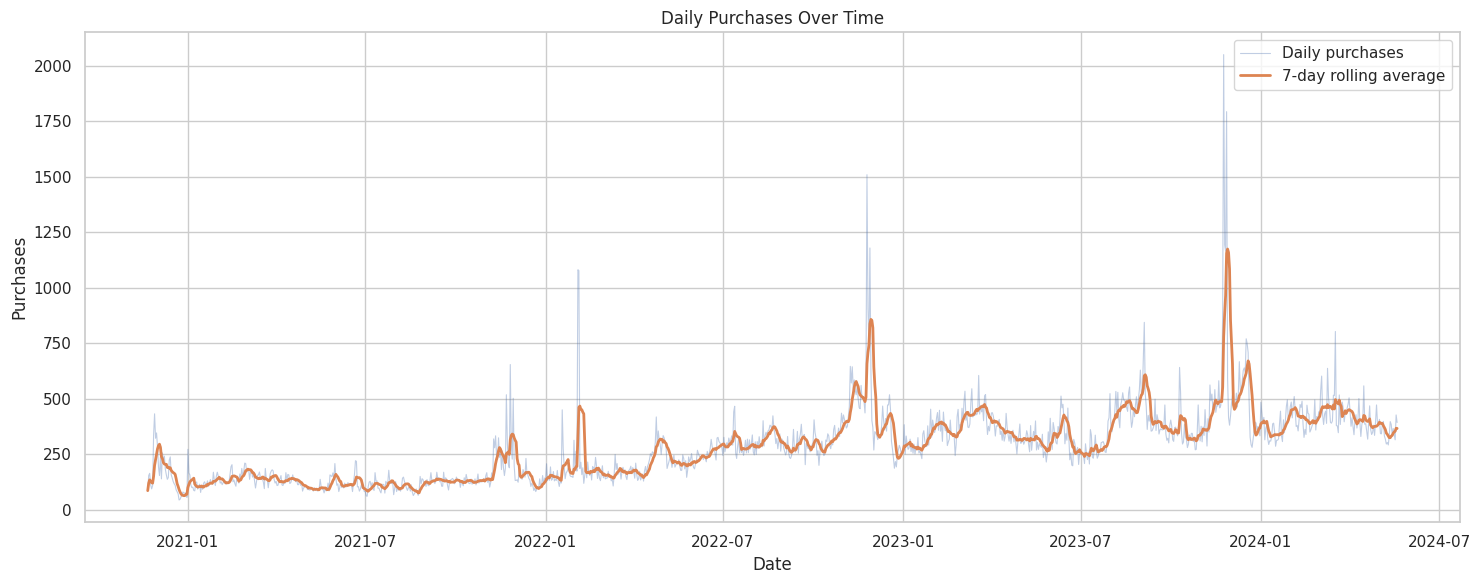

In [21]:
eda_df["PURCHASES_7D_AVG"] = (
    eda_df["ALL_PURCHASES"]
    .rolling(window=7, min_periods=1)
    .mean()
)

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    eda_df["DATE_DAY"],
    eda_df["ALL_PURCHASES"],
    alpha=0.35,
    linewidth=0.8,
    label="Daily purchases"
)

ax.plot(
    eda_df["DATE_DAY"],
    eda_df["PURCHASES_7D_AVG"],
    linewidth=2,
    label="7-day rolling average"
)

ax.set_title("Daily Purchases Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Purchases")
ax.legend()

plt.tight_layout()

fig.savefig(
    CHART_DIR / "daily_purchases.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Daily Purchases Interpretation

Daily purchases exhibit a clear upward long-term trend. The typical purchase
level increased considerably from 2021 to 2024, indicating growth in the
underlying business that should not be attributed entirely to paid media.

The series also contains recurring year-end peaks, suggesting strong seasonal
shopping effects. The largest observed value was 2,051 purchases on
November 24, 2023, which corresponds to Black Friday. Similar, though smaller,
spikes are visible in previous years.

The seven-day rolling average highlights sustained changes in demand while
reducing daily noise. Because both trend and seasonal peaks are visible,
time-based controls will be included in the Marketing Mix Model to reduce the
risk of incorrectly assigning organic business growth or holiday demand to
advertising channels.

In [22]:
purchase_summary = eda_df["ALL_PURCHASES"].describe().round(2)

print(purchase_summary)

print(
    "\nHighest-purchase day:",
    eda_df.loc[eda_df["ALL_PURCHASES"].idxmax(), "DATE_DAY"]
)

print(
    "Highest daily purchases:",
    eda_df["ALL_PURCHASES"].max()
)

count    1276.00
mean      281.98
std       166.33
min        45.00
25%       144.00
50%       273.00
75%       373.00
max      2051.00
Name: ALL_PURCHASES, dtype: float64

Highest-purchase day: 2023-11-24 00:00:00
Highest daily purchases: 2051


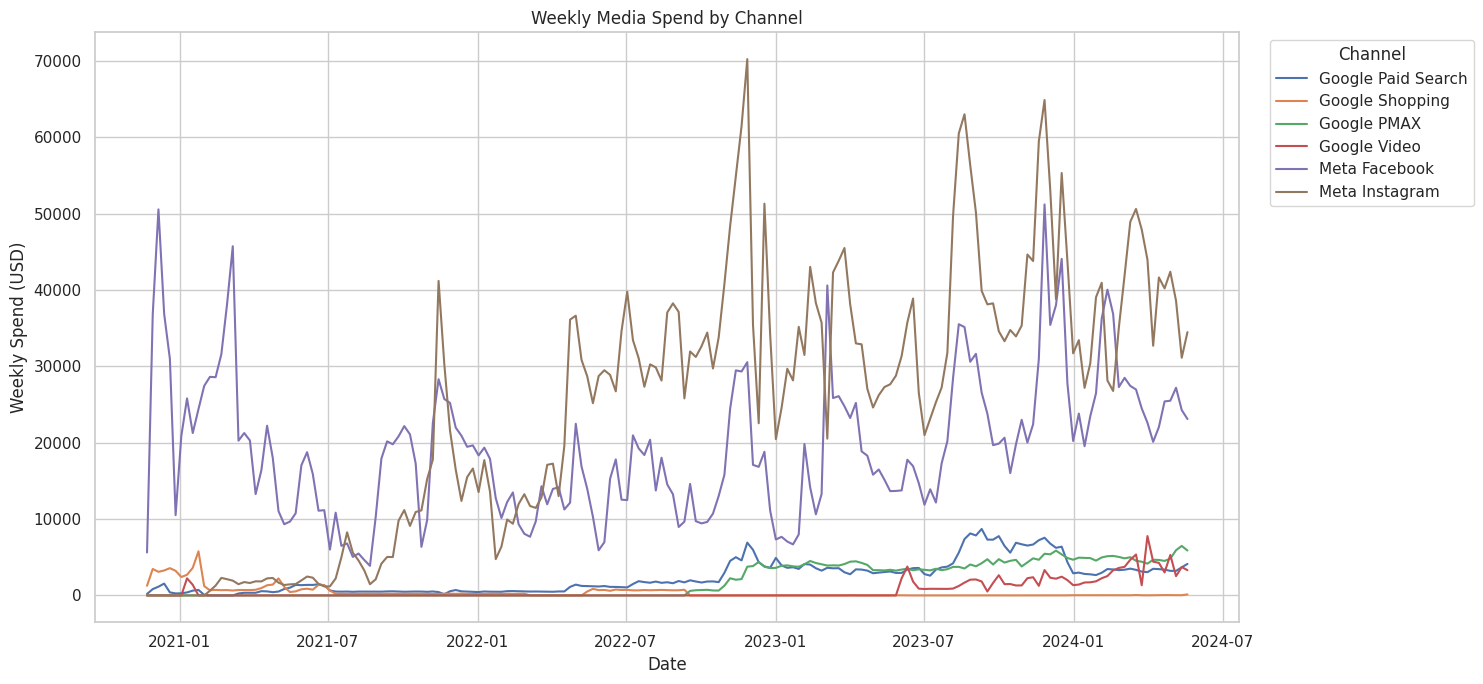

In [23]:
plot_spend_df = (
    eda_df.set_index("DATE_DAY")[selected_spend_columns]
    .resample("W")
    .sum()
)

plot_spend_df = plot_spend_df.rename(
    columns={
        details["spend"]: channel
        for channel, details in MEDIA_CHANNELS.items()
    }
)

fig, ax = plt.subplots(figsize=(15, 7))

for channel in plot_spend_df.columns:
    ax.plot(
        plot_spend_df.index,
        plot_spend_df[channel],
        linewidth=1.5,
        label=channel
    )

ax.set_title("Weekly Media Spend by Channel")
ax.set_xlabel("Date")
ax.set_ylabel("Weekly Spend (USD)")
ax.legend(
    title="Channel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

fig.savefig(
    CHART_DIR / "weekly_media_spend_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Media Spend Trend Interpretation

Weekly media investment is heavily concentrated in Meta Facebook and Meta
Instagram. These channels operate at a substantially larger spend scale than
the retained Google channels.

Meta Facebook remains active across the full observation period, while Meta
Instagram expands significantly from 2022 onward and records the largest weekly
spend peaks.

Google Paid Search investment increases from late 2022, while Google PMAX
emerges during the later part of the dataset and maintains relatively stable
spend. Google Video displays intermittent campaign activity, and Google
Shopping declines substantially over time.

The changing channel mix indicates that media strategy was not constant across
the study period. Meridian's time-varying media transformations and control
variables will therefore be important for separating channel effects from the
underlying growth and seasonal patterns.

### 1.3 Correlation Analysis

A correlation heatmap is used to examine relationships between purchases,
revenue, paid-media spend, and selected non-paid traffic variables.

Correlation indicates association rather than causation. Channel contribution
and incrementality will later be estimated using the Meridian Marketing Mix
Model.

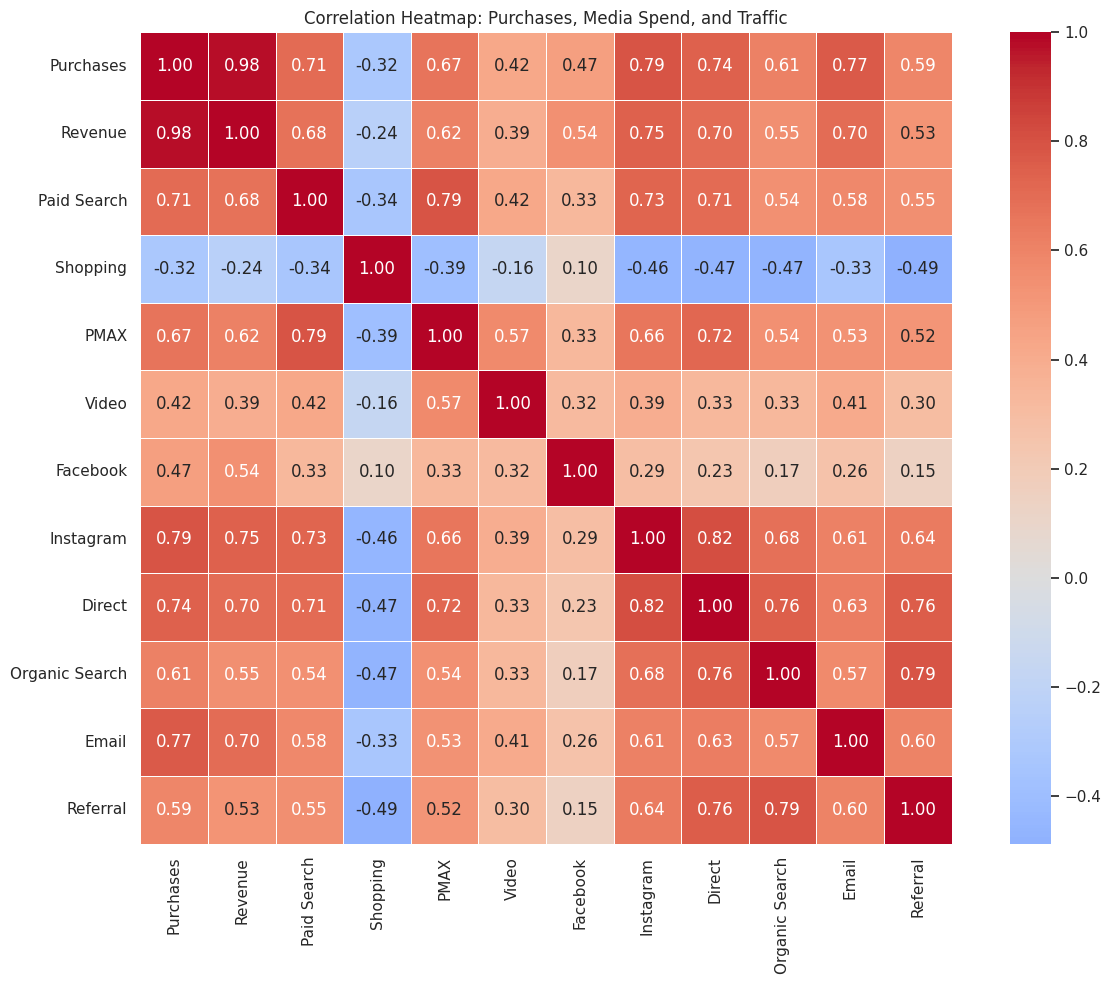

In [24]:
correlation_columns = [
    "ALL_PURCHASES",
    "ALL_PURCHASES_ORIGINAL_PRICE",
    *selected_spend_columns,
    "DIRECT_CLICKS",
    "ORGANIC_SEARCH_CLICKS",
    "EMAIL_CLICKS",
    "REFERRAL_CLICKS",
]

correlation_df = eda_df[correlation_columns].copy()
correlation_df = correlation_df.fillna(0)

correlation_names = {
    "ALL_PURCHASES": "Purchases",
    "ALL_PURCHASES_ORIGINAL_PRICE": "Revenue",
    "GOOGLE_PAID_SEARCH_SPEND": "Paid Search",
    "GOOGLE_SHOPPING_SPEND": "Shopping",
    "GOOGLE_PMAX_SPEND": "PMAX",
    "GOOGLE_VIDEO_SPEND": "Video",
    "META_FACEBOOK_SPEND": "Facebook",
    "META_INSTAGRAM_SPEND": "Instagram",
    "DIRECT_CLICKS": "Direct",
    "ORGANIC_SEARCH_CLICKS": "Organic Search",
    "EMAIL_CLICKS": "Email",
    "REFERRAL_CLICKS": "Referral",
}

correlation_df = correlation_df.rename(columns=correlation_names)

correlation_matrix = correlation_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title("Correlation Heatmap: Purchases, Media Spend, and Traffic")

plt.tight_layout()

fig.savefig(
    CHART_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
purchase_correlations = (
    correlation_matrix["Purchases"]
    .drop("Purchases")
    .sort_values(ascending=False)
    .to_frame("correlation_with_purchases")
)

display(purchase_correlations)

,correlation_with_purchases
Revenue,0.977913
Instagram,0.791012
Email,0.766513
Direct,0.742132
Paid Search,0.707049
PMAX,0.667447
Organic Search,0.610902
Referral,0.589880
Facebook,0.468644
Video,0.419157


### Correlation Analysis Interpretation

Purchases and original-price revenue are strongly correlated at 0.98, which is
expected because greater purchase volume generally produces higher revenue.

Among paid-media channels, Meta Instagram has the strongest positive raw
correlation with purchases at 0.79, followed by Google Paid Search at 0.71 and
Google PMAX at 0.67.

Meta Facebook has a moderate correlation of 0.47 despite receiving a large
share of total media spend. This may suggest weaker marginal efficiency or
saturation, although correlation alone cannot establish this.

Google Shopping has a negative correlation of -0.32. This should not be
interpreted as evidence that Shopping harms purchases. Shopping investment was
higher during earlier periods when the business purchase baseline was lower,
while its spend later declined as purchases and other channels grew.

Direct, email, and organic traffic are also strongly associated with purchases.
These variables may reflect customer demand as well as marketing activity, so
they must be used cautiously as causal controls.

Overall, the heatmap is exploratory. Channel incrementality, lagged effects, and
diminishing returns will be estimated through the Meridian model.

In [26]:
eda_df["DAY_OF_WEEK"] = eda_df["DATE_DAY"].dt.day_name()
eda_df["DAY_OF_WEEK_NUMBER"] = eda_df["DATE_DAY"].dt.dayofweek

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

day_of_week_summary = (
    eda_df.groupby("DAY_OF_WEEK")
    .agg(
        mean_purchases=("ALL_PURCHASES", "mean"),
        median_purchases=("ALL_PURCHASES", "median"),
        total_purchases=("ALL_PURCHASES", "sum"),
    )
    .reindex(day_order)
    .round(2)
)

display(day_of_week_summary)

,mean_purchases,median_purchases,total_purchases
DAY_OF_WEEK,,,
Monday,294.78,284.0,53650
Tuesday,277.16,287.5,50444
Wednesday,261.40,265.0,47574
Thursday,268.17,260.5,48807
Friday,274.09,256.5,49884
Saturday,283.30,282.0,51844
Sunday,314.77,314.0,57602


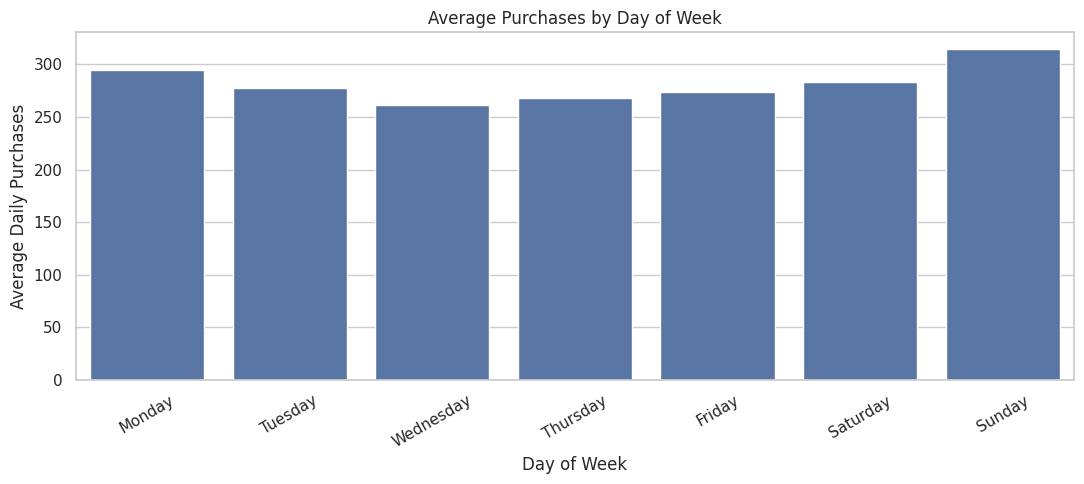

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.barplot(
    data=day_of_week_summary.reset_index(),
    x="DAY_OF_WEEK",
    y="mean_purchases",
    ax=ax
)

ax.set_title("Average Purchases by Day of Week")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Purchases")
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

fig.savefig(
    CHART_DIR / "purchases_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
eda_df["MONTH"] = eda_df["DATE_DAY"].dt.month
eda_df["MONTH_NAME"] = eda_df["DATE_DAY"].dt.month_name()

month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

monthly_summary = (
    eda_df.groupby("MONTH_NAME")
    .agg(
        mean_purchases=("ALL_PURCHASES", "mean"),
        median_purchases=("ALL_PURCHASES", "median"),
        maximum_purchases=("ALL_PURCHASES", "max"),
    )
    .reindex(month_order)
    .round(2)
)

display(monthly_summary)

,mean_purchases,median_purchases,maximum_purchases
MONTH_NAME,,,
January,244.40,254.5,496
February,292.42,294.0,1082
March,304.41,295.0,804
April,274.81,306.0,559
May,237.17,238.0,428
June,233.73,242.5,513
July,231.59,257.0,524
August,296.32,320.0,630
September,280.00,282.0,845


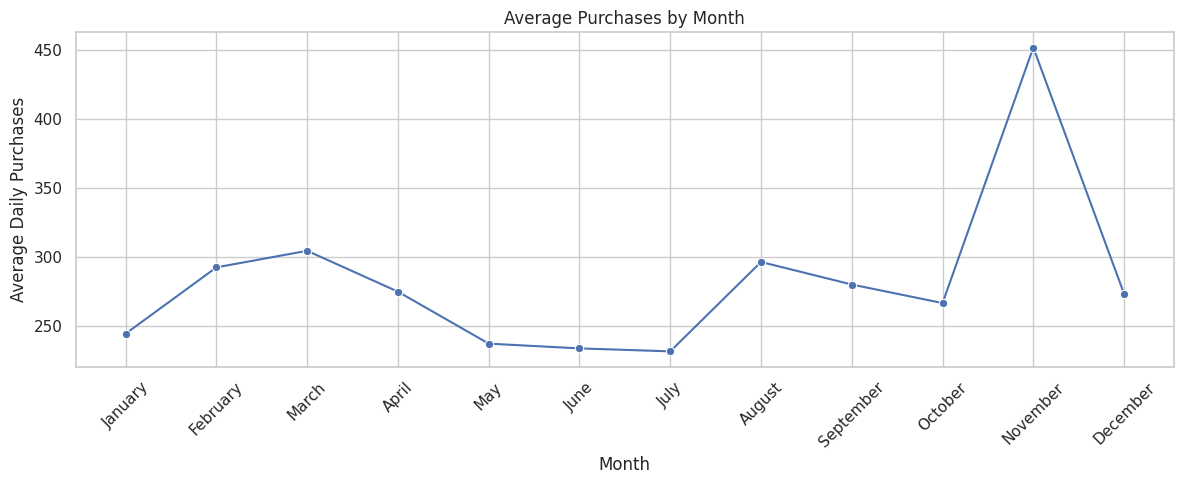

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=monthly_summary.reset_index(),
    x="MONTH_NAME",
    y="mean_purchases",
    marker="o",
    ax=ax
)

ax.set_title("Average Purchases by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Daily Purchases")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

fig.savefig(
    CHART_DIR / "monthly_purchase_seasonality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Seasonality Interpretation

Purchases vary systematically by day of week. Sunday records the highest average
daily purchases at approximately 315, while Wednesday records the lowest at
approximately 261. This pattern supports including day-of-week controls in the
model.

Monthly demand is especially strong in November, when average daily purchases
increase to approximately 452. The November peak is consistent with Black
Friday and holiday shopping activity.

Monthly averages may also be influenced by the company's long-term growth.
Therefore, the Marketing Mix Model will include both trend and seasonal controls
to avoid attributing recurring demand patterns entirely to advertising.

In [30]:
q1 = eda_df["ALL_PURCHASES"].quantile(0.25)
q3 = eda_df["ALL_PURCHASES"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

eda_df["PURCHASE_OUTLIER"] = (
    (eda_df["ALL_PURCHASES"] < lower_bound)
    | (eda_df["ALL_PURCHASES"] > upper_bound)
)

purchase_outliers = (
    eda_df.loc[
        eda_df["PURCHASE_OUTLIER"],
        [
            "DATE_DAY",
            "ALL_PURCHASES",
            "ALL_PURCHASES_ORIGINAL_PRICE",
        ]
    ]
    .sort_values("ALL_PURCHASES", ascending=False)
)

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of purchase outliers:", len(purchase_outliers))
print(
    "Outlier percentage:",
    round(len(purchase_outliers) / len(eda_df) * 100, 2),
    "%"
)

display(purchase_outliers.head(15))

Q1: 144.0
Q3: 373.0
IQR: 229.0
Lower bound: -199.5
Upper bound: 716.5
Number of purchase outliers: 15
Outlier percentage: 1.18 %


,DATE_DAY,ALL_PURCHASES,ALL_PURCHASES_ORIGINAL_PRICE
1098,2023-11-24,2051,172467.790699
1101,2023-11-27,1794,148023.887683
734,2022-11-25,1510,128583.291357
1099,2023-11-25,1194,101336.579676
737,2022-11-28,1180,99478.179360
1100,2023-11-26,1166,97679.464663
439,2022-02-03,1082,85017.248761
440,2022-02-04,1078,122454.467871
735,2022-11-26,910,73909.793738
1097,2023-11-23,901,73718.392208


In [31]:
purchase_outliers.to_csv(
    TABLE_DIR / "purchase_outliers.csv",
    index=False
)

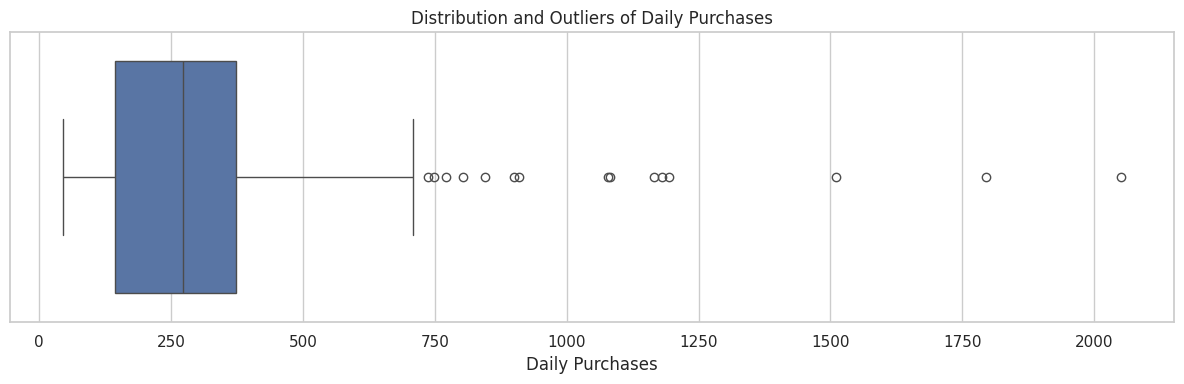

In [32]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(
    x=eda_df["ALL_PURCHASES"],
    ax=ax
)

ax.set_title("Distribution and Outliers of Daily Purchases")
ax.set_xlabel("Daily Purchases")

plt.tight_layout()

fig.savefig(
    CHART_DIR / "purchase_outlier_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

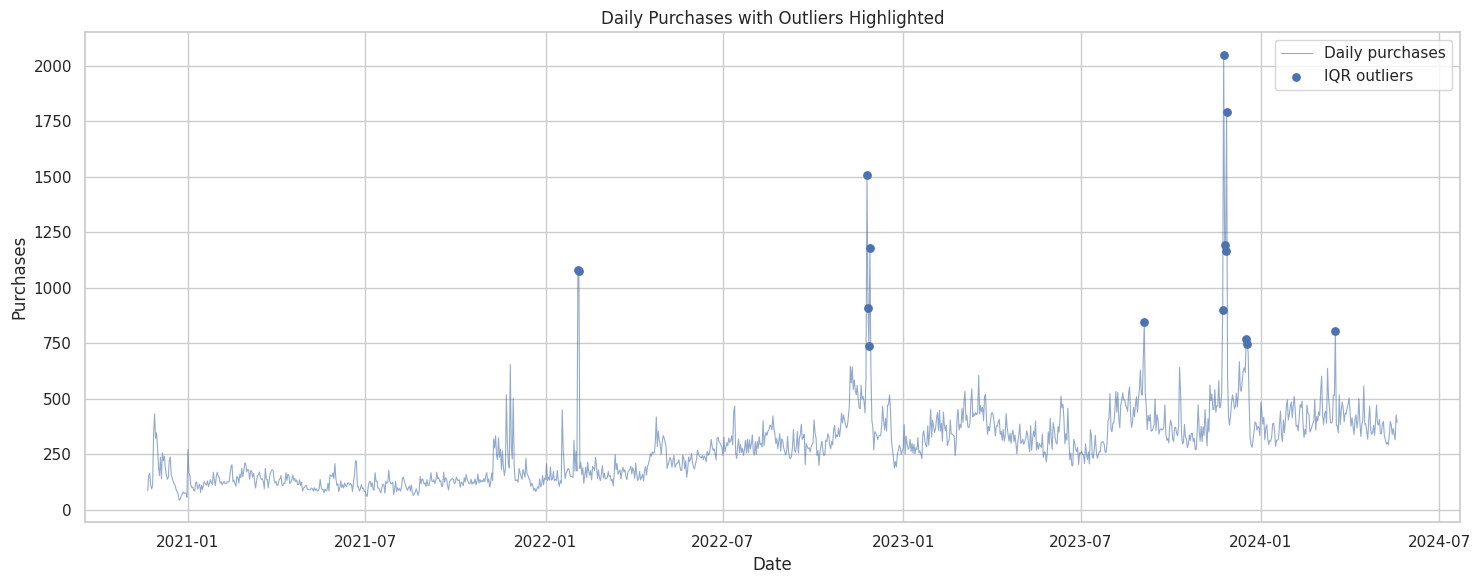

In [33]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    eda_df["DATE_DAY"],
    eda_df["ALL_PURCHASES"],
    linewidth=0.8,
    alpha=0.6,
    label="Daily purchases"
)

ax.scatter(
    eda_df.loc[eda_df["PURCHASE_OUTLIER"], "DATE_DAY"],
    eda_df.loc[eda_df["PURCHASE_OUTLIER"], "ALL_PURCHASES"],
    s=28,
    label="IQR outliers"
)

ax.set_title("Daily Purchases with Outliers Highlighted")
ax.set_xlabel("Date")
ax.set_ylabel("Purchases")
ax.legend()

plt.tight_layout()

fig.savefig(
    CHART_DIR / "purchase_outliers_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Outlier Interpretation

The IQR method identified 15 high-purchase outliers, representing approximately
1.18% of the selected dataset.

Most of the largest observations occur during Black Friday and Cyber Monday
periods in November 2022 and November 2023. The highest value is 2,051 purchases
on November 24, 2023.

These observations are commercially plausible demand events rather than obvious
data errors. Therefore, they are retained in the modeling dataset. Removing or
capping them could erase real seasonal and promotional behavior.

Seasonality and time controls will instead be used to prevent the Marketing Mix
Model from incorrectly assigning all holiday demand to paid media.

### Task 1 Summary

The exploratory analysis was conducted on one selected Beauty & Fitness
organization containing 1,276 continuous daily observations in USD.

Key findings include:

- The target and revenue variables contain no missing values.
- Missing media values represent inactive channel days and were replaced with
  zero after selecting the organization.
- Six meaningful paid-media channels were retained: Google Paid Search,
  Google Shopping, Google PMAX, Google Video, Meta Facebook, and Meta Instagram.
- Purchases show a clear upward business trend and strong seasonal variation.
- Sunday records the highest average purchases, while Wednesday records the
  lowest.
- November is the strongest month because of Black Friday and holiday demand.
- Fifteen high-purchase outliers were identified, representing approximately
  1.18% of observations. These were retained because they reflect plausible
  commercial events rather than data errors.
- Media investment is highly concentrated: Meta Facebook and Meta Instagram
  together account for approximately 88.94% of total paid-media spend.
- Instagram, Paid Search, and PMAX have the strongest positive raw correlations
  with purchases, although correlation should not be interpreted as causal
  contribution.

These findings support the inclusion of trend, weekday, and annual-seasonality
controls in the Marketing Mix Model.

## Task 2: Data Preparation

The selected organization already contains one continuous observation per day,
so no additional daily aggregation is required.

`ALL_PURCHASES` is used as the target because the business objective is to
estimate incremental purchases. Original-price revenue is retained for ROI,
marginal ROI, and scenario analysis.

In [34]:
model_df = (
    brand_df.copy()
    .sort_values("DATE_DAY")
    .reset_index(drop=True)
)

TARGET_COLUMN = "ALL_PURCHASES"
REVENUE_COLUMN = "ALL_PURCHASES_ORIGINAL_PRICE"

# Fill structural media missing values with zero.
media_columns_to_fill = (
    selected_spend_columns
    + selected_exposure_columns
    + selected_click_columns
)

model_df[media_columns_to_fill] = (
    model_df[media_columns_to_fill]
    .fillna(0)
)

# Revenue generated per purchase.
model_df["REVENUE_PER_PURCHASE"] = np.where(
    model_df[TARGET_COLUMN] > 0,
    model_df[REVENUE_COLUMN] / model_df[TARGET_COLUMN],
    np.nan
)

model_df["REVENUE_PER_PURCHASE"] = (
    model_df["REVENUE_PER_PURCHASE"]
    .fillna(model_df["REVENUE_PER_PURCHASE"].median())
)

print("Rows:", len(model_df))
print("Target:", TARGET_COLUMN)
print(
    "Average revenue per purchase:",
    round(model_df["REVENUE_PER_PURCHASE"].mean(), 2)
)

display(
    model_df[
        [
            "DATE_DAY",
            TARGET_COLUMN,
            REVENUE_COLUMN,
            "REVENUE_PER_PURCHASE",
        ]
    ].head()
)

Rows: 1276
Target: ALL_PURCHASES
Average revenue per purchase: 85.47


,DATE_DAY,ALL_PURCHASES,ALL_PURCHASES_ORIGINAL_PRICE,REVENUE_PER_PURCHASE
0,2020-11-21,87,11339.006630,130.333410
1,2020-11-22,155,23078.991668,148.896720
2,2020-11-23,165,22954.006947,139.115194
3,2020-11-24,113,17747.000080,157.053098
4,2020-11-25,95,15592.004580,164.126364


In [35]:
model_df["TIME_INDEX"] = np.arange(len(model_df))

# Scale trend between 0 and 1.
model_df["TREND"] = (
    model_df["TIME_INDEX"]
    / model_df["TIME_INDEX"].max()
)

# Weekday indicators. Monday is the reference day.
weekday_dummies = pd.get_dummies(
    model_df["DATE_DAY"].dt.day_name(),
    prefix="DOW",
    dtype=int
)

weekday_dummies = weekday_dummies.drop(
    columns=["DOW_Monday"]
)

model_df = pd.concat(
    [model_df, weekday_dummies],
    axis=1
)

weekday_control_columns = weekday_dummies.columns.tolist()

# Smooth annual seasonality using Fourier terms.
days = np.arange(len(model_df))
annual_period = 365.25

for harmonic in [1, 2]:
    model_df[f"YEAR_SIN_{harmonic}"] = np.sin(
        2 * np.pi * harmonic * days / annual_period
    )

    model_df[f"YEAR_COS_{harmonic}"] = np.cos(
        2 * np.pi * harmonic * days / annual_period
    )

seasonality_columns = [
    "YEAR_SIN_1",
    "YEAR_COS_1",
    "YEAR_SIN_2",
    "YEAR_COS_2",
]

print("Weekday controls:", weekday_control_columns)
print("Annual seasonality controls:", seasonality_columns)

Weekday controls: ['DOW_Friday', 'DOW_Saturday', 'DOW_Sunday', 'DOW_Thursday', 'DOW_Tuesday', 'DOW_Wednesday']
Annual seasonality controls: ['YEAR_SIN_1', 'YEAR_COS_1', 'YEAR_SIN_2', 'YEAR_COS_2']


In [36]:
def fourth_thursday_of_november(year):
    november_dates = pd.date_range(
        start=f"{year}-11-01",
        end=f"{year}-11-30",
        freq="D"
    )

    thursdays = november_dates[
        november_dates.dayofweek == 3
    ]

    return thursdays[3]


model_df["BLACK_FRIDAY_PERIOD"] = 0

for year in model_df["DATE_DAY"].dt.year.unique():
    thanksgiving = fourth_thursday_of_november(year)
    black_friday = thanksgiving + pd.Timedelta(days=1)
    cyber_monday = thanksgiving + pd.Timedelta(days=4)

    event_mask = model_df["DATE_DAY"].between(
        thanksgiving,
        cyber_monday
    )

    model_df.loc[event_mask, "BLACK_FRIDAY_PERIOD"] = 1

display(
    model_df.loc[
        model_df["BLACK_FRIDAY_PERIOD"] == 1,
        ["DATE_DAY", "ALL_PURCHASES", "BLACK_FRIDAY_PERIOD"]
    ].head(15)
)

,DATE_DAY,ALL_PURCHASES,BLACK_FRIDAY_PERIOD
5,2020-11-26,110,1
6,2020-11-27,337,1
7,2020-11-28,433,1
8,2020-11-29,323,1
9,2020-11-30,347,1
369,2021-11-25,190,1
370,2021-11-26,655,1
371,2021-11-27,290,1
372,2021-11-28,229,1
373,2021-11-29,503,1


In [37]:
traffic_columns = [
    "ORGANIC_SEARCH_CLICKS",
    "EMAIL_CLICKS",
    "REFERRAL_CLICKS",
    "ALL_OTHER_CLICKS",
]

model_df[traffic_columns] = (
    model_df[traffic_columns]
    .fillna(0)
)

for column in traffic_columns:
    model_df[f"LOG_{column}"] = np.log1p(
        model_df[column]
    )

traffic_control_columns = [
    f"LOG_{column}"
    for column in traffic_columns
]

print("Traffic controls:")
print(traffic_control_columns)

Traffic controls:
['LOG_ORGANIC_SEARCH_CLICKS', 'LOG_EMAIL_CLICKS', 'LOG_REFERRAL_CLICKS', 'LOG_ALL_OTHER_CLICKS']


In [38]:
control_columns = [
    "TREND",
    *weekday_control_columns,
    *seasonality_columns,
    "BLACK_FRIDAY_PERIOD",
    *traffic_control_columns,
]

print("Control variables:")

for column in control_columns:
    print("-", column)

print("\nNumber of controls:", len(control_columns))

Control variables:
- TREND
- DOW_Friday
- DOW_Saturday
- DOW_Sunday
- DOW_Thursday
- DOW_Tuesday
- DOW_Wednesday
- YEAR_SIN_1
- YEAR_COS_1
- YEAR_SIN_2
- YEAR_COS_2
- BLACK_FRIDAY_PERIOD
- LOG_ORGANIC_SEARCH_CLICKS
- LOG_EMAIL_CLICKS
- LOG_REFERRAL_CLICKS
- LOG_ALL_OTHER_CLICKS

Number of controls: 16


In [39]:
modeling_columns = [
    "DATE_DAY",
    TARGET_COLUMN,
    REVENUE_COLUMN,
    "REVENUE_PER_PURCHASE",
    *selected_exposure_columns,
    *selected_spend_columns,
    *control_columns,
]

modeling_df = model_df[modeling_columns].copy()

# Replace accidental infinite values, if any.
modeling_df = modeling_df.replace(
    [np.inf, -np.inf],
    np.nan
)

print("Modeling dataset shape:", modeling_df.shape)
print(
    "Total missing values:",
    modeling_df.isna().sum().sum()
)
print(
    "Duplicate dates:",
    modeling_df["DATE_DAY"].duplicated().sum()
)

display(modeling_df.head())

Modeling dataset shape: (1276, 32)
Total missing values: 0
Duplicate dates: 0


,DATE_DAY,ALL_PURCHASES,ALL_PURCHASES_ORIGINAL_PRICE,REVENUE_PER_PURCHASE,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,GOOGLE_PAID_SEARCH_SPEND,GOOGLE_SHOPPING_SPEND,GOOGLE_PMAX_SPEND,GOOGLE_VIDEO_SPEND,META_FACEBOOK_SPEND,META_INSTAGRAM_SPEND,TREND,DOW_Friday,DOW_Saturday,DOW_Sunday,DOW_Thursday,DOW_Tuesday,DOW_Wednesday,YEAR_SIN_1,YEAR_COS_1,YEAR_SIN_2,YEAR_COS_2,BLACK_FRIDAY_PERIOD,LOG_ORGANIC_SEARCH_CLICKS,LOG_EMAIL_CLICKS,LOG_REFERRAL_CLICKS,LOG_ALL_OTHER_CLICKS
0,2020-11-21,87,11339.006630,130.333410,773.0,59850.0,0.0,0.0,99163.0,0.0,95.38,773.82,0.0,0.0,1138.970648,0.0,0.000000,0,1,0,0,0,0,0.000000,1.000000,0.000000,1.000000,0,0.0,0.0,0.0,0.0
1,2020-11-22,155,23078.991668,148.896720,773.0,71318.0,0.0,0.0,394931.0,0.0,100.88,491.87,0.0,0.0,4486.452133,0.0,0.000784,0,0,1,0,0,0,0.017202,0.999852,0.034398,0.999408,0,0.0,0.0,0.0,0.0
2,2020-11-23,165,22954.006947,139.115194,897.0,62824.0,0.0,0.0,254403.0,0.0,123.95,384.94,0.0,0.0,3835.775893,0.0,0.001569,0,0,0,0,0,0,0.034398,0.999408,0.068755,0.997634,0,0.0,0.0,0.0,0.0
3,2020-11-24,113,17747.000080,157.053098,1105.0,57843.0,0.0,0.0,165212.0,0.0,83.74,337.96,0.0,0.0,2651.402842,0.0,0.002353,0,0,0,0,1,0,0.051584,0.998669,0.103031,0.994678,0,0.0,0.0,0.0,0.0
4,2020-11-25,95,15592.004580,164.126364,1266.0,63830.0,0.0,0.0,111504.0,0.0,140.29,485.03,0.0,0.0,2324.369601,0.0,0.003137,0,0,0,0,0,1,0.068755,0.997634,0.137185,0.990545,0,0.0,0.0,0.0,0.0


In [40]:
split_index = int(len(modeling_df) * 0.80)

train_df = modeling_df.iloc[:split_index].copy()
validation_df = modeling_df.iloc[split_index:].copy()

modeling_df["DATA_SPLIT"] = "Train"

modeling_df.loc[
    modeling_df.index >= split_index,
    "DATA_SPLIT"
] = "Validation"

print("Training observations:", len(train_df))
print("Validation observations:", len(validation_df))

print(
    "\nTraining period:",
    train_df["DATE_DAY"].min(),
    "to",
    train_df["DATE_DAY"].max()
)

print(
    "Validation period:",
    validation_df["DATE_DAY"].min(),
    "to",
    validation_df["DATE_DAY"].max()
)

Training observations: 1020
Validation observations: 256

Training period: 2020-11-21 00:00:00 to 2023-09-06 00:00:00
Validation period: 2023-09-07 00:00:00 to 2024-05-19 00:00:00


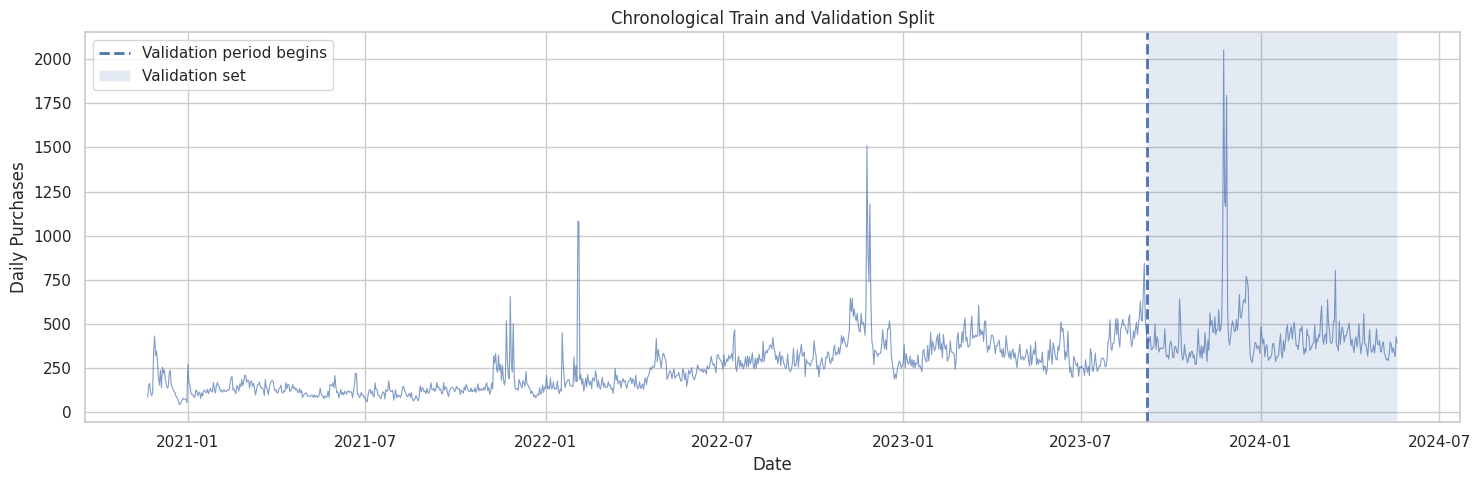

In [41]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    modeling_df["DATE_DAY"],
    modeling_df[TARGET_COLUMN],
    linewidth=0.8,
    alpha=0.7
)

split_date = validation_df["DATE_DAY"].min()

ax.axvline(
    split_date,
    linestyle="--",
    linewidth=2,
    label="Validation period begins"
)

ax.axvspan(
    split_date,
    modeling_df["DATE_DAY"].max(),
    alpha=0.15,
    label="Validation set"
)

ax.set_title("Chronological Train and Validation Split")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Purchases")
ax.legend()

plt.tight_layout()

fig.savefig(
    CHART_DIR / "train_validation_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
modeling_df.to_csv(
    TABLE_DIR / "clean_modeling_dataset.csv",
    index=False
)

train_df.to_csv(
    TABLE_DIR / "train_dataset.csv",
    index=False
)

validation_df.to_csv(
    TABLE_DIR / "validation_dataset.csv",
    index=False
)

print("Prepared datasets saved successfully.")

Prepared datasets saved successfully.


### Task 2 Summary

The final modeling dataset contains 1,276 daily observations, 32 modeling
variables, no missing values, and no duplicate dates.

`ALL_PURCHASES` was selected as the target variable. The average original-price
revenue per purchase is approximately $85.47.

Six media exposure variables and their corresponding spend variables were
retained. Sixteen control variables were created to represent trend, weekday
effects, annual seasonality, Black Friday and Cyber Monday, and non-paid traffic.

A chronological 80/20 split produced 1,020 training observations and 256
validation observations. The validation period begins on September 7, 2023 and
includes the 2023 Black Friday period, providing a meaningful test of model
performance during high-demand conditions.

## Task 3: Meridian Marketing Mix Model Development

A national-level Bayesian Marketing Mix Model is developed using Google
Meridian.

The model uses daily purchases as the KPI, media impressions as channel
exposure, and corresponding channel spend for ROI estimation.

Meridian estimates:

- Lagged media effects through adstock
- Diminishing returns through Hill saturation functions
- Incremental channel contribution
- ROI and marginal ROI
- Uncertainty through Bayesian posterior distributions

In [46]:
import meridian

from meridian.data import data_frame_input_data_builder as data_builder
from meridian.model import model
from meridian.model import spec
from meridian.model import prior_distribution

print("Meridian version:", meridian.__version__)

Meridian version: 1.7.0


In [47]:
meridian_df = (
    modeling_df
    .drop(columns=["DATA_SPLIT"], errors="ignore")
    .copy()
)

# Meridian works cleanly with ISO date strings as time coordinates.
meridian_df["DATE_DAY"] = pd.to_datetime(
    meridian_df["DATE_DAY"]
).dt.strftime("%Y-%m-%d")

print("Meridian input rows:", len(meridian_df))
print("Date range:", meridian_df["DATE_DAY"].min(), "to", meridian_df["DATE_DAY"].max())
print("Missing values:", meridian_df.isna().sum().sum())

Meridian input rows: 1276
Date range: 2020-11-21 to 2024-05-19
Missing values: 0


In [48]:
meridian_channel_names = [
    "Google Paid Search",
    "Google Shopping",
    "Google PMAX",
    "Google Video",
    "Meta Facebook",
    "Meta Instagram",
]

print("Media exposure columns:")
for channel, exposure, spend in zip(
    meridian_channel_names,
    selected_exposure_columns,
    selected_spend_columns,
):
    print(f"{channel}")
    print(f"  Exposure: {exposure}")
    print(f"  Spend:    {spend}")

Media exposure columns:
Google Paid Search
  Exposure: GOOGLE_PAID_SEARCH_IMPRESSIONS
  Spend:    GOOGLE_PAID_SEARCH_SPEND
Google Shopping
  Exposure: GOOGLE_SHOPPING_IMPRESSIONS
  Spend:    GOOGLE_SHOPPING_SPEND
Google PMAX
  Exposure: GOOGLE_PMAX_IMPRESSIONS
  Spend:    GOOGLE_PMAX_SPEND
Google Video
  Exposure: GOOGLE_VIDEO_IMPRESSIONS
  Spend:    GOOGLE_VIDEO_SPEND
Meta Facebook
  Exposure: META_FACEBOOK_IMPRESSIONS
  Spend:    META_FACEBOOK_SPEND
Meta Instagram
  Exposure: META_INSTAGRAM_IMPRESSIONS
  Spend:    META_INSTAGRAM_SPEND


In [49]:
builder = data_builder.DataFrameInputDataBuilder(
    kpi_type="non_revenue",
    default_time_column="DATE_DAY",
    default_kpi_column=TARGET_COLUMN,
    default_revenue_per_kpi_column="REVENUE_PER_PURCHASE",
)

builder = (
    builder
    .with_kpi(meridian_df)
    .with_revenue_per_kpi(meridian_df)
    .with_controls(
        meridian_df,
        control_cols=control_columns,
    )
    .with_media(
        meridian_df,
        media_cols=selected_exposure_columns,
        media_spend_cols=selected_spend_columns,
        media_channels=meridian_channel_names,
    )
)

meridian_data = builder.build()

print("Meridian InputData created successfully.")

Meridian InputData created successfully.


In [50]:
print("KPI shape:", meridian_data.kpi.shape)
print("Revenue-per-KPI shape:", meridian_data.revenue_per_kpi.shape)
print("Controls shape:", meridian_data.controls.shape)
print("Media shape:", meridian_data.media.shape)
print("Media spend shape:", meridian_data.media_spend.shape)

print("\nTime periods:", len(meridian_data.time))

print("\nMedia channels:")
print(meridian_data.media_channel.values.tolist())

print("\nControl variables:")
print(meridian_data.control_variable.values.tolist())

KPI shape: (1, 1276)
Revenue-per-KPI shape: (1, 1276)
Controls shape: (1, 1276, 16)
Media shape: (1, 1276, 6)
Media spend shape: (1, 1276, 6)

Time periods: 1276

Media channels:
['Google Paid Search', 'Google Shopping', 'Google PMAX', 'Google Video', 'Meta Facebook', 'Meta Instagram']

Control variables:
['TREND', 'DOW_Friday', 'DOW_Saturday', 'DOW_Sunday', 'DOW_Thursday', 'DOW_Tuesday', 'DOW_Wednesday', 'YEAR_SIN_1', 'YEAR_COS_1', 'YEAR_SIN_2', 'YEAR_COS_2', 'BLACK_FRIDAY_PERIOD', 'LOG_ORGANIC_SEARCH_CLICKS', 'LOG_EMAIL_CLICKS', 'LOG_REFERRAL_CLICKS', 'LOG_ALL_OTHER_CLICKS']


In [51]:
RANDOM_SEED = 42
HOLDOUT_PERCENTAGE = 0.20

rng = np.random.default_rng(RANDOM_SEED)

n_times = len(meridian_data.time)
n_holdout = int(round(n_times * HOLDOUT_PERCENTAGE))

holdout_id = np.zeros(n_times, dtype=bool)

holdout_indices = rng.choice(
    n_times,
    size=n_holdout,
    replace=False,
)

holdout_id[holdout_indices] = True

print("Total time periods:", n_times)
print("Training observations:", (~holdout_id).sum())
print("Meridian holdout observations:", holdout_id.sum())
print(
    "Holdout percentage:",
    round(holdout_id.mean() * 100, 2),
    "%"
)

Total time periods: 1276
Training observations: 1021
Meridian holdout observations: 255
Holdout percentage: 19.98 %


### Meridian Holdout Strategy

The assignment's chronological 80/20 train-validation datasets were retained as
formal data-preparation deliverables.

For Meridian model diagnostics, a separate reproducible 20% holdout mask was
distributed across the complete timeline.

This approach follows Meridian's recommendation to avoid holding out a large
contiguous period at the end of the dataset. Meridian is designed primarily for
causal media measurement rather than conventional future forecasting.

Only the KPI values in the holdout observations are excluded from posterior
training. Media observations remain available because earlier exposure can
affect later outcomes through adstock.

### Model Configuration

The Meridian model uses the default ROI prior parameterization for paid-media
channels.

An eight-day maximum lag is used for the adstock transformation because the
dataset is daily. This allows advertising exposure to influence purchases on
the same day and during the following days.

The default transformation order is retained:

1. Geometric adstock to estimate delayed and carryover effects
2. Hill saturation to estimate diminishing returns

A reproducible 20% holdout sample is excluded from posterior training for model
evaluation.

In [52]:
model_spec = spec.ModelSpec(
    prior=prior_distribution.PriorDistribution(),

    # Estimate historical media efficiency using ROI priors.
    media_prior_type="roi",

    # Daily data: allow media effects to carry over for up to eight days.
    max_lag=8,

    # Default order: adstock first, then Hill saturation.
    hill_before_adstock=False,

    # Standard geometric carryover function.
    adstock_decay_spec="geometric",

    # Balanced holdout created earlier.
    holdout_id=holdout_id,

    # For a national model, our engineered trend and seasonality controls
    # represent the time effects.
    knots=None,
)

print("Model specification created.")
print("Media prior type:", model_spec.media_prior_type)
print("Maximum lag:", model_spec.max_lag)
print("Hill before adstock:", model_spec.hill_before_adstock)
print("Adstock decay:", model_spec.adstock_decay_spec)
print("Holdout observations:", np.asarray(model_spec.holdout_id).sum())

Model specification created.
Media prior type: roi
Maximum lag: 8
Hill before adstock: False
Adstock decay: geometric
Holdout observations: 255


2026-07-16 03:44:27.388483: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [53]:
mmm = model.Meridian(
    input_data=meridian_data,
    model_spec=model_spec,
)

print("Meridian model created successfully.")
print("National model:", mmm.is_national)
print("Time periods:", mmm.n_times)
print("Media channels:", mmm.n_media_channels)
print("Control variables:", mmm.n_controls)

2026-07-16 03:52:22.298754: I external/local_xla/xla/service/service.cc:163] XLA service 0x16178f70 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-07-16 03:52:22.298780: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1784155942.797572  224636 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(


Meridian model created successfully.
National model: True
Time periods: 1276
Media channels: 6
Control variables: 16


In [54]:
mmm.sample_prior(100)

print("Prior sampling completed.")
print("Inference data groups:", mmm.inference_data.groups())

/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarnin

Prior sampling completed.
Inference data groups: ['prior']


### Posterior Sampling Smoke Test

A small posterior sampling run is first performed to verify that the full
Bayesian model can execute successfully on the local CPU.

This run is only a technical test and is not used for final interpretation.
A larger posterior sample will be generated after confirming that the model
runs without errors.

In [55]:
import time

smoke_test_start = time.time()

mmm.sample_posterior(
    n_chains=2,
    n_adapt=50,
    n_burnin=0,
    n_keep=50,
)

smoke_test_minutes = (
    time.time() - smoke_test_start
) / 60

print("Posterior smoke test completed.")
print(
    "Runtime:",
    round(smoke_test_minutes, 2),
    "minutes"
)
print(
    "Inference data groups:",
    mmm.inference_data.groups()
)

2026-07-16 04:18:15.778174: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-16 04:18:17.100054: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:108] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. sanitize_seed/seed
2026-07-16 04:18:18.128891: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Posterior smoke test completed.
Runtime: 2.36 minutes
Inference data groups: ['posterior', 'sample_stats', 'prior', 'trace']


/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [56]:
mmm_final = model.Meridian(
    input_data=meridian_data,
    model_spec=model_spec,
)

mmm_final.sample_prior(500)

print("Fresh final model created.")
print("Prior samples completed.")

/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/model/prior_distribution.py:1329: UserWarning: Hierarchical distribution parameters must be deterministically zero f

Fresh final model created.
Prior samples completed.


### Final Posterior Sampling

After successfully completing the smoke test, the model is fitted using four
independent MCMC chains.

Each chain uses 500 adaptation draws and retains 500 posterior draws. No
additional burn-in is used because the adaptation period already allows the
sampler to tune its step size and kernel.

The resulting posterior contains 2,000 retained samples across four chains.

In [57]:
final_sampling_start = time.time()

mmm_final.sample_posterior(
    n_chains=4,
    n_adapt=500,
    n_burnin=0,
    n_keep=500,
)

final_sampling_minutes = (
    time.time() - final_sampling_start
) / 60

print("Final posterior sampling completed.")
print(
    "Runtime:",
    round(final_sampling_minutes, 2),
    "minutes"
)
print(
    "Inference data groups:",
    mmm_final.inference_data.groups()
)

2026-07-16 04:31:15.690665: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


Final posterior sampling completed.
Runtime: 2.87 minutes
Inference data groups: ['posterior', 'sample_stats', 'prior', 'trace']


/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


In [58]:
posterior = mmm_final.inference_data.posterior

print("Number of chains:", posterior.sizes["chain"])
print("Samples retained per chain:", posterior.sizes["draw"])

print(
    "Total retained posterior samples:",
    posterior.sizes["chain"] * posterior.sizes["draw"]
)

print("\nPosterior variables:")
print(list(posterior.data_vars))

Number of chains: 4
Samples retained per chain: 500
Total retained posterior samples: 2000

Posterior variables:
['alpha_m', 'beta_gm', 'beta_m', 'ec_m', 'eta_m', 'gamma_c', 'gamma_gc', 'knot_values', 'mu_t', 'roi_m', 'sigma', 'slope_m', 'tau_g', 'xi_c']


In [59]:
MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "meridian_final_model.pkl"

model.save_mmm(
    mmm_final,
    str(MODEL_PATH)
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/home/muzzamil/Documents/duuaproject/marketing_mmm_project/outputs/models/meridian_final_model.pkl


/tmp/ipykernel_224636/2206982815.py:6: DeprecationWarning: save_mmm is deprecated and will be removed in a future release. Please use `schema.serde.meridian_serde.save_meridian` instead. See https://developers.google.com/meridian/docs/user-guide/saving-model-object for details.
  model.save_mmm(


In [60]:
POSTERIOR_PATH = MODEL_DIR / "meridian_inference_data.nc"

mmm_final.inference_data.to_netcdf(
    POSTERIOR_PATH
)

print("Posterior saved to:")
print(POSTERIOR_PATH)

Posterior saved to:
/home/muzzamil/Documents/duuaproject/marketing_mmm_project/outputs/models/meridian_inference_data.nc


### Convergence Diagnostics

Model convergence is assessed before interpreting channel contributions and ROI.

R-hat compares variation between MCMC chains with variation within each chain.
Values close to 1.0 indicate that the chains have converged to similar posterior
distributions.

Divergent transitions are also inspected because they can indicate that the
sampler had difficulty exploring parts of the posterior distribution.

In [61]:
import arviz as az

from meridian.analysis import visualizer

model_diagnostics = visualizer.ModelDiagnostics(
    mmm_final
)

print("Meridian diagnostics object created.")

Meridian diagnostics object created.


In [62]:
rhat_plot = model_diagnostics.plot_rhat_boxplot()

rhat_plot

alt.LayerChart(...)

In [63]:
diagnostic_variables = [
    "roi_m",
    "alpha_m",
    "beta_m",
    "ec_m",
    "gamma_c",
    "sigma",
]

convergence_summary = az.summary(
    mmm_final.inference_data,
    var_names=diagnostic_variables,
    round_to=4,
)

display(convergence_summary)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
roi_m[Google Paid Search],11.5269,3.4988,4.6352,17.9459,0.1003,0.0709,1193.5647,870.9177,1.0015
roi_m[Google Shopping],1.3893,1.1677,0.0996,3.4882,0.0267,0.0240,3449.6108,1311.1254,1.0030
roi_m[Google PMAX],1.1260,0.8254,0.1260,2.6676,0.0170,0.0136,2926.5079,1664.6455,1.0010
roi_m[Google Video],0.8944,0.6545,0.0704,2.0788,0.0126,0.0104,2846.8665,1459.4794,1.0021
roi_m[Meta Facebook],2.4046,0.3326,1.7889,3.0126,0.0079,0.0057,1745.3711,1235.6451,1.0007
roi_m[Meta Instagram],2.3318,0.2931,1.7808,2.8772,0.0078,0.0055,1418.5287,1493.4533,1.0019
alpha_m[Google Paid Search],0.6913,0.3096,0.0887,0.9999,0.0082,0.0058,2353.0017,1463.2075,1.0054
alpha_m[Google Shopping],0.4925,0.2894,0.0090,0.9406,0.0046,0.0036,3500.4438,1161.6254,1.0038
alpha_m[Google PMAX],0.5212,0.2873,0.0662,0.9987,0.0042,0.0034,4341.0050,1235.9655,1.0018
alpha_m[Google Video],0.4813,0.2896,0.0113,0.9447,0.0047,0.0038,3143.6468,1032.7137,1.0029


In [64]:
maximum_rhat = convergence_summary["r_hat"].max()

print("Maximum R-hat:", round(maximum_rhat, 4))

Maximum R-hat: 1.0066


In [65]:
divergence_count = int(
    mmm_final
    .inference_data
    .sample_stats["diverging"]
    .sum()
    .item()
)

print("Divergent transitions:", divergence_count)

Divergent transitions: 0


In [66]:
convergence_summary.to_csv(
    TABLE_DIR / "meridian_convergence_summary.csv"
)

print("Convergence summary saved.")

Convergence summary saved.


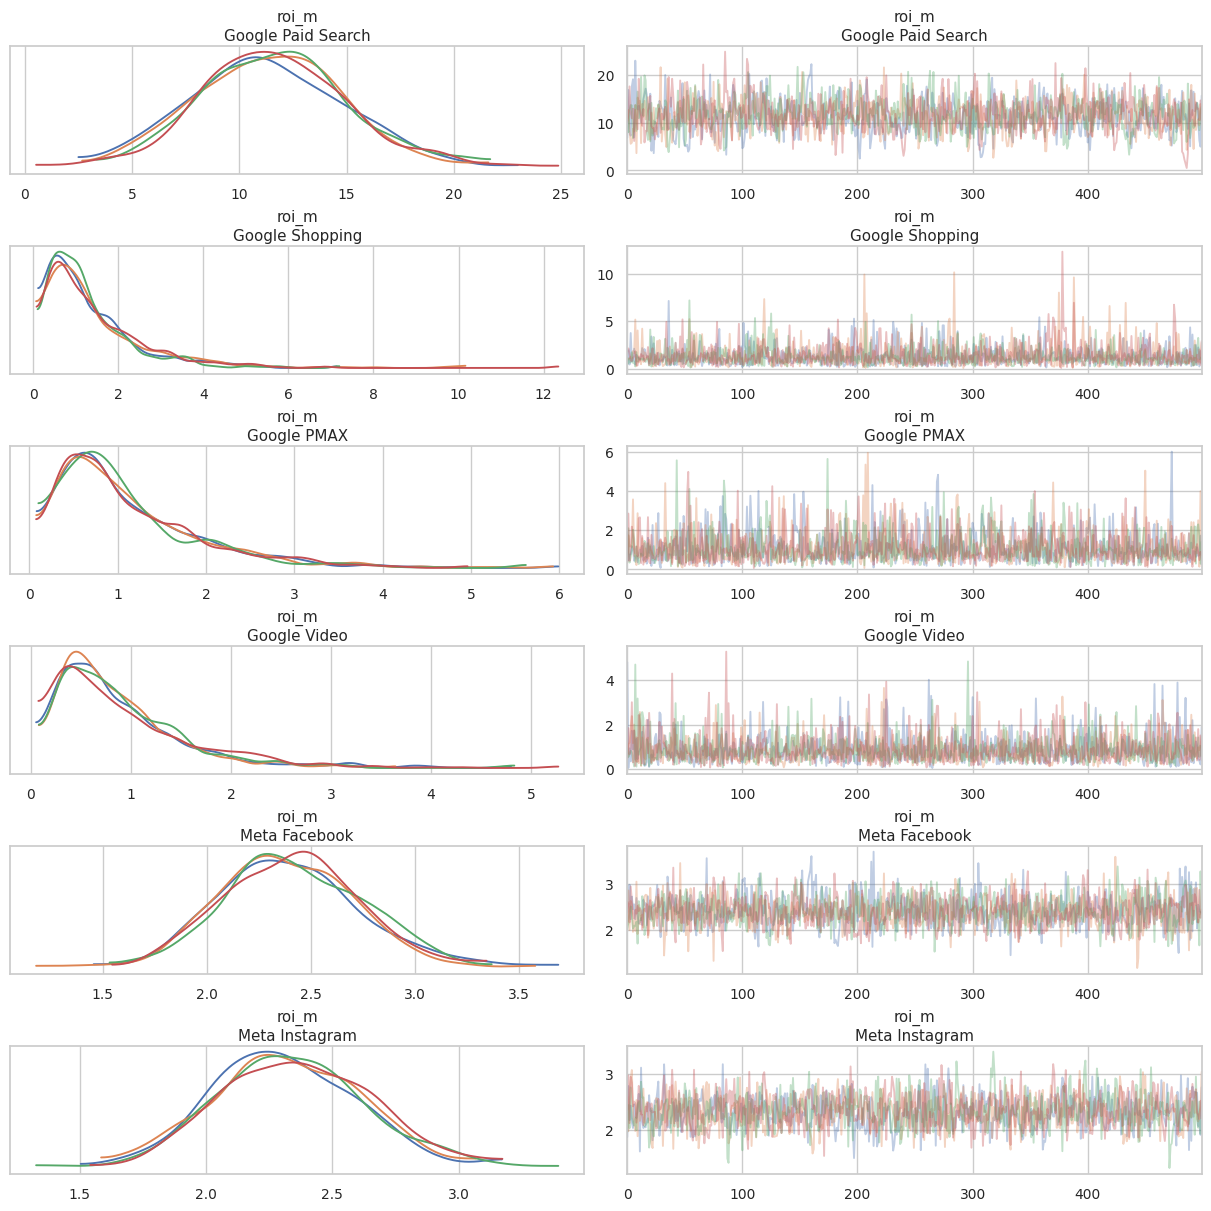

In [67]:
trace_axes = az.plot_trace(
    mmm_final.inference_data,
    var_names=["roi_m"],
    compact=False,
    backend_kwargs={
        "constrained_layout": True
    },
)

trace_figure = np.asarray(trace_axes).ravel()[0].figure

trace_figure.savefig(
    CHART_DIR / "roi_trace_plots.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Convergence Results

The final Meridian model retained 2,000 posterior samples across four MCMC
chains.

The maximum rank-normalized split R-hat was approximately 1.007, with all
examined parameters below 1.01. This indicates that the four chains converged
to highly similar posterior distributions.

The sampler recorded zero divergent transitions. ROI trace and density plots
also showed overlapping chains without persistent drift.

The convergence diagnostics therefore support using the posterior samples for
channel-contribution, ROI, marginal ROI, adstock, and saturation analysis.

### Model Quality Evaluation

Model performance is evaluated using:

- R² to measure explained variation
- MAPE to measure average percentage error
- wMAPE to measure error relative to total purchases
- RMSE to measure prediction error in purchase units

Metrics are reported separately for training observations, Meridian holdout
observations, and the complete dataset.

In [68]:
from meridian.analysis import visualizer

model_diagnostics = visualizer.ModelDiagnostics(
    mmm_final,
    use_kpi=True,
)

predictive_accuracy = (
    model_diagnostics
    .predictive_accuracy_table()
)

display(predictive_accuracy)

/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/analysis/analyzer.py:102: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


,metric,geo_granularity,evaluation_set,value
0,R_Squared,national,Train,0.746004
1,R_Squared,national,Test,0.710421
2,R_Squared,national,All Data,0.740187
3,MAPE,national,Train,0.182749
4,MAPE,national,Test,0.164909
5,MAPE,national,All Data,0.179184
6,wMAPE,national,Train,0.166514
7,wMAPE,national,Test,0.159233
8,wMAPE,national,All Data,0.165078


In [69]:
predictive_accuracy.to_csv(
    TABLE_DIR / "meridian_predictive_accuracy.csv",
    index=False,
)

print("Predictive accuracy table saved.")

Predictive accuracy table saved.


In [70]:
model_fit = visualizer.ModelFit(
    mmm_final,
    use_kpi=True,
    confidence_level=0.90,
)

model_fit_chart = model_fit.plot_model_fit(
    include_baseline=True,
    include_ci=True,
)

model_fit_chart

/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/analysis/analyzer.py:102: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


alt.LayerChart(...)

In [71]:
model_fit_chart.save(
    str(CHART_DIR / "meridian_model_fit.html")
)

print("Interactive model-fit chart saved.")

Interactive model-fit chart saved.


In [72]:
fit_data = model_fit.model_fit_data

print(fit_data)
print("\nMetrics:", fit_data["metric"].values.tolist())
print("Geographies:", fit_data["geo"].values.tolist())

<xarray.Dataset> Size: 46kB
Dimensions:   (geo: 1, time: 1276, metric: 3)
Coordinates:
  * geo       (geo) <U12 48B 'national_geo'
  * time      (time) object 10kB '2020-11-21' '2020-11-22' ... '2024-05-19'
  * metric    (metric) <U5 60B 'mean' 'ci_lo' 'ci_hi'
Data variables:
    expected  (geo, time, metric) float32 15kB 66.16 37.6 92.76 ... 423.2 465.2
    baseline  (geo, time, metric) float32 15kB 24.61 -4.765 ... 34.19 151.6
    actual    (geo, time) float32 5kB 87.0 155.0 165.0 ... 316.0 428.0 394.0
Attributes:
    confidence_level:  0.9

Metrics: ['mean', 'ci_lo', 'ci_hi']
Geographies: ['national_geo']


In [74]:
print("Actual dimensions:", fit_data["actual"].dims)
print("Expected dimensions:", fit_data["expected"].dims)

Actual dimensions: ('geo', 'time')
Expected dimensions: ('geo', 'time', 'metric')


In [75]:
# Actual purchases have only geo and time dimensions.
actual_purchases = (
    fit_data["actual"]
    .sum(dim="geo")
    .values
)

# Expected purchases contain mean and credible-interval metrics.
expected_purchases = (
    fit_data["expected"]
    .sel(metric="mean")
    .sum(dim="geo")
    .values
)

expected_ci_low = (
    fit_data["expected"]
    .sel(metric="ci_lo")
    .sum(dim="geo")
    .values
)

expected_ci_high = (
    fit_data["expected"]
    .sel(metric="ci_hi")
    .sum(dim="geo")
    .values
)

fit_dates = pd.to_datetime(
    fit_data["time"].values
)

fit_results_df = pd.DataFrame({
    "DATE_DAY": fit_dates,
    "ACTUAL_PURCHASES": actual_purchases,
    "EXPECTED_PURCHASES": expected_purchases,
    "EXPECTED_CI_LOW": expected_ci_low,
    "EXPECTED_CI_HIGH": expected_ci_high,
    "IS_HOLDOUT": holdout_id,
})

display(fit_results_df.head())

,DATE_DAY,ACTUAL_PURCHASES,EXPECTED_PURCHASES,EXPECTED_CI_LOW,EXPECTED_CI_HIGH,IS_HOLDOUT
0,2020-11-21,87.0,66.156799,37.595982,92.762291,False
1,2020-11-22,155.0,162.138596,131.174896,191.732544,False
2,2020-11-23,165.0,144.398727,119.760956,167.840363,False
3,2020-11-24,113.0,113.410912,91.399719,135.766144,False
4,2020-11-25,95.0,95.948242,73.807816,118.373833,False


In [76]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error,
)

def calculate_fit_metrics(data, label):
    actual = data["ACTUAL_PURCHASES"].astype(float)
    predicted = data["EXPECTED_PURCHASES"].astype(float)

    return {
        "evaluation_set": label,
        "observations": len(data),
        "R2": r2_score(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "MAPE_PERCENT": (
            mean_absolute_percentage_error(
                actual,
                predicted,
            ) * 100
        ),
        "WMAPE_PERCENT": (
            np.abs(actual - predicted).sum()
            / np.abs(actual).sum()
            * 100
        ),
    }


train_fit = fit_results_df.loc[
    ~fit_results_df["IS_HOLDOUT"]
].copy()

holdout_fit = fit_results_df.loc[
    fit_results_df["IS_HOLDOUT"]
].copy()

fit_metrics = pd.DataFrame([
    calculate_fit_metrics(
        train_fit,
        "Train",
    ),
    calculate_fit_metrics(
        holdout_fit,
        "Test / Holdout",
    ),
    calculate_fit_metrics(
        fit_results_df,
        "All Data",
    ),
]).round(4)

display(fit_metrics)

,evaluation_set,observations,R2,RMSE,MAPE_PERCENT,WMAPE_PERCENT
0,Train,1021,0.7460,85.6230,18.2749,16.6514
1,Test / Holdout,255,0.7104,81.1574,16.4909,15.9233
2,All Data,1276,0.7402,84.7494,17.9184,16.5078


In [77]:
fit_results_df["WITHIN_90_PERCENT_CI"] = (
    (
        fit_results_df["ACTUAL_PURCHASES"]
        >= fit_results_df["EXPECTED_CI_LOW"]
    )
    &
    (
        fit_results_df["ACTUAL_PURCHASES"]
        <= fit_results_df["EXPECTED_CI_HIGH"]
    )
)

interval_coverage = pd.DataFrame({
    "evaluation_set": [
        "Train",
        "Test / Holdout",
        "All Data",
    ],
    "coverage_percentage": [
        train_fit.assign(
            WITHIN_90_PERCENT_CI=(
                (
                    train_fit["ACTUAL_PURCHASES"]
                    >= train_fit["EXPECTED_CI_LOW"]
                )
                &
                (
                    train_fit["ACTUAL_PURCHASES"]
                    <= train_fit["EXPECTED_CI_HIGH"]
                )
            )
        )["WITHIN_90_PERCENT_CI"].mean() * 100,

        holdout_fit.assign(
            WITHIN_90_PERCENT_CI=(
                (
                    holdout_fit["ACTUAL_PURCHASES"]
                    >= holdout_fit["EXPECTED_CI_LOW"]
                )
                &
                (
                    holdout_fit["ACTUAL_PURCHASES"]
                    <= holdout_fit["EXPECTED_CI_HIGH"]
                )
            )
        )["WITHIN_90_PERCENT_CI"].mean() * 100,

        fit_results_df[
            "WITHIN_90_PERCENT_CI"
        ].mean() * 100,
    ],
}).round(2)

display(interval_coverage)

,evaluation_set,coverage_percentage
0,Train,34.77
1,Test / Holdout,36.08
2,All Data,35.03


In [78]:
fit_results_df.to_csv(
    TABLE_DIR / "meridian_expected_vs_actual.csv",
    index=False,
)

fit_metrics.to_csv(
    TABLE_DIR / "meridian_model_metrics.csv",
    index=False,
)

interval_coverage.to_csv(
    TABLE_DIR / "meridian_interval_coverage.csv",
    index=False,
)

print("Model-quality outputs saved successfully.")

Model-quality outputs saved successfully.


### Model Performance Results

The Meridian model demonstrates good predictive performance.

The model achieved an R² of 0.746 on the training observations and 0.710 on the
holdout observations. The relatively small difference indicates that the model
generalizes reasonably well and does not show strong evidence of overfitting.

Holdout RMSE was approximately 81 purchases per day. Holdout MAPE was 16.49%,
while holdout weighted MAPE was 15.92%.

Across the complete dataset, the model explained approximately 74% of purchase
variation, with an overall weighted MAPE of 16.51%.

The credible interval displayed by Meridian represents uncertainty around the
expected outcome rather than a full posterior predictive interval. Therefore,
the percentage of actual observations inside this band is treated as
supplementary information rather than a primary model-quality metric.

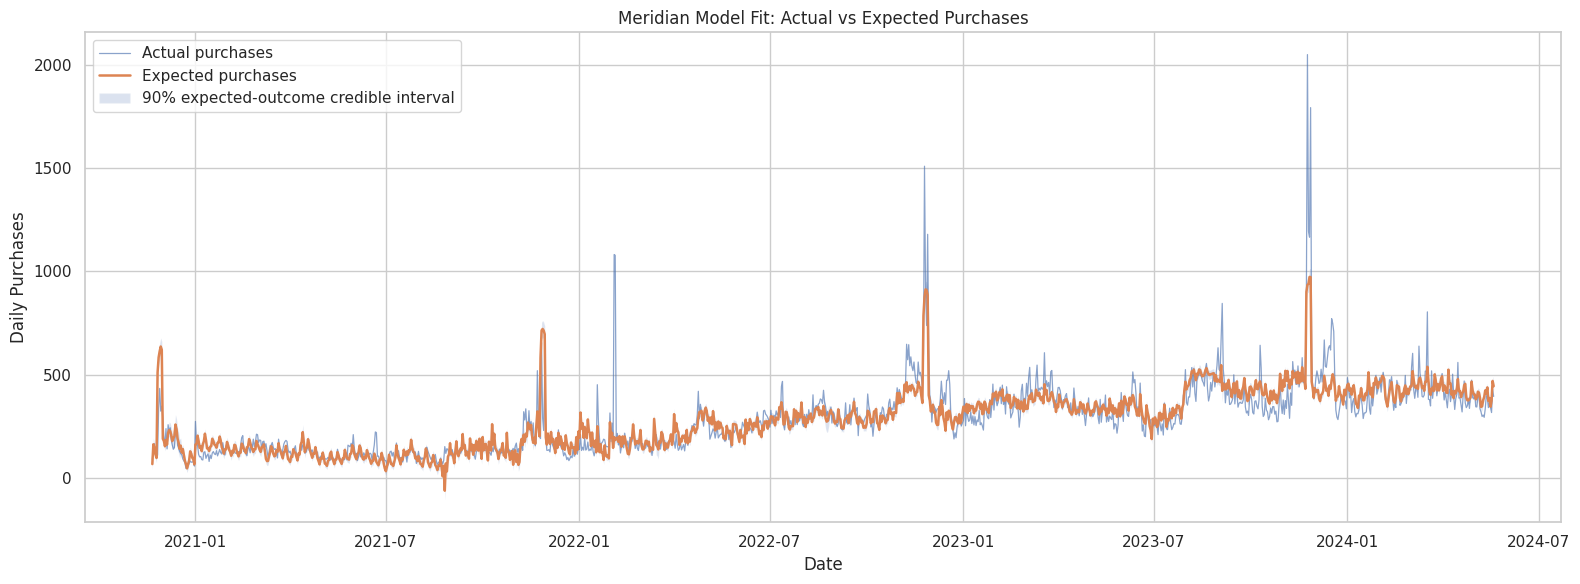

In [79]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    fit_results_df["DATE_DAY"],
    fit_results_df["ACTUAL_PURCHASES"],
    linewidth=0.9,
    alpha=0.65,
    label="Actual purchases",
)

ax.plot(
    fit_results_df["DATE_DAY"],
    fit_results_df["EXPECTED_PURCHASES"],
    linewidth=1.8,
    label="Expected purchases",
)

ax.fill_between(
    fit_results_df["DATE_DAY"],
    fit_results_df["EXPECTED_CI_LOW"],
    fit_results_df["EXPECTED_CI_HIGH"],
    alpha=0.2,
    label="90% expected-outcome credible interval",
)

ax.set_title("Meridian Model Fit: Actual vs Expected Purchases")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Purchases")
ax.legend()

plt.tight_layout()

fig.savefig(
    CHART_DIR / "meridian_actual_vs_expected.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

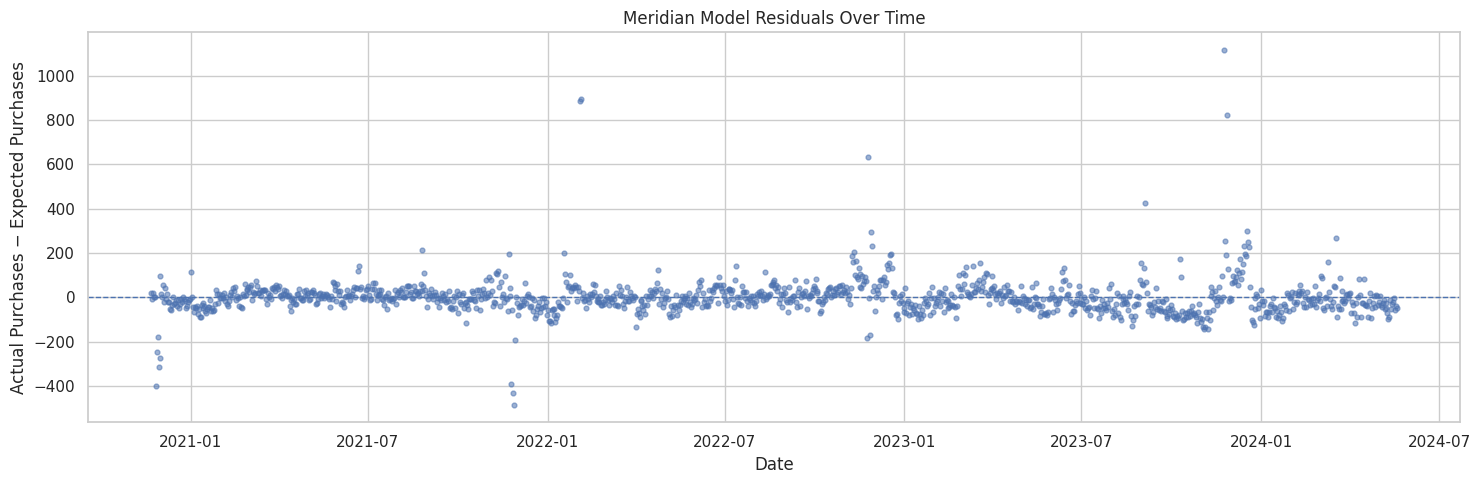

In [80]:
fit_results_df["RESIDUAL"] = (
    fit_results_df["ACTUAL_PURCHASES"]
    - fit_results_df["EXPECTED_PURCHASES"]
)

fig, ax = plt.subplots(figsize=(15, 5))

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.scatter(
    fit_results_df["DATE_DAY"],
    fit_results_df["RESIDUAL"],
    s=12,
    alpha=0.55,
)

ax.set_title("Meridian Model Residuals Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Actual Purchases − Expected Purchases")

plt.tight_layout()

fig.savefig(
    CHART_DIR / "meridian_residuals.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Channel Contribution Analysis

Channel contribution estimates the incremental purchases associated with each
paid-media channel after accounting for trend, seasonality, control variables,
adstock, and diminishing returns.

These results represent model-estimated incrementality rather than simple
last-click attribution or correlation.

In [81]:
from meridian.analysis import visualizer

media_summary_kpi = visualizer.MediaSummary(
    mmm_final,
    confidence_level=0.90,
    use_kpi=True,
)

print("Media summary created successfully.")

Media summary created successfully.


In [82]:
channel_contribution_df = (
    media_summary_kpi.contribution_metrics(
        include_non_paid=False,
        aggregate_times=True,
    )
)

display(channel_contribution_df)

,channel,incremental_outcome,pct_of_contribution
6,Meta Instagram,129093.296875,0.358978
5,Meta Facebook,99120.820312,0.275632
0,baseline,63514.160156,0.176618
1,Google Paid Search,60546.199219,0.168365
3,Google PMAX,4830.509277,0.013433
4,Google Video,1360.203369,0.003782
2,Google Shopping,1147.695679,0.003191


In [83]:
channel_contribution_clean = (
    channel_contribution_df
    .copy()
)

channel_contribution_clean[
    "contribution_percentage"
] = (
    channel_contribution_clean[
        "pct_of_contribution"
    ] * 100
)

channel_contribution_clean = (
    channel_contribution_clean[
        [
            "channel",
            "incremental_outcome",
            "contribution_percentage",
        ]
    ]
    .rename(
        columns={
            "incremental_outcome":
                "incremental_purchases",
        }
    )
    .sort_values(
        "incremental_purchases",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    channel_contribution_clean.round(2)
)

,channel,incremental_purchases,contribution_percentage
0,Meta Instagram,129093.30,35.90
1,Meta Facebook,99120.82,27.56
2,baseline,63514.16,17.66
3,Google Paid Search,60546.20,16.84
4,Google PMAX,4830.51,1.34
5,Google Video,1360.20,0.38
6,Google Shopping,1147.70,0.32


In [84]:
channel_contribution_clean.to_csv(
    TABLE_DIR / "meridian_channel_contribution.csv",
    index=False,
)

print("Channel contribution table saved.")

Channel contribution table saved.


In [85]:
contribution_waterfall_chart = (
    media_summary_kpi
    .plot_contribution_waterfall_chart()
)

contribution_waterfall_chart

alt.LayerChart(...)

In [86]:
contribution_waterfall_chart.save(
    str(
        CHART_DIR
        / "meridian_contribution_waterfall.html"
    )
)

print("Contribution waterfall chart saved.")

Contribution waterfall chart saved.


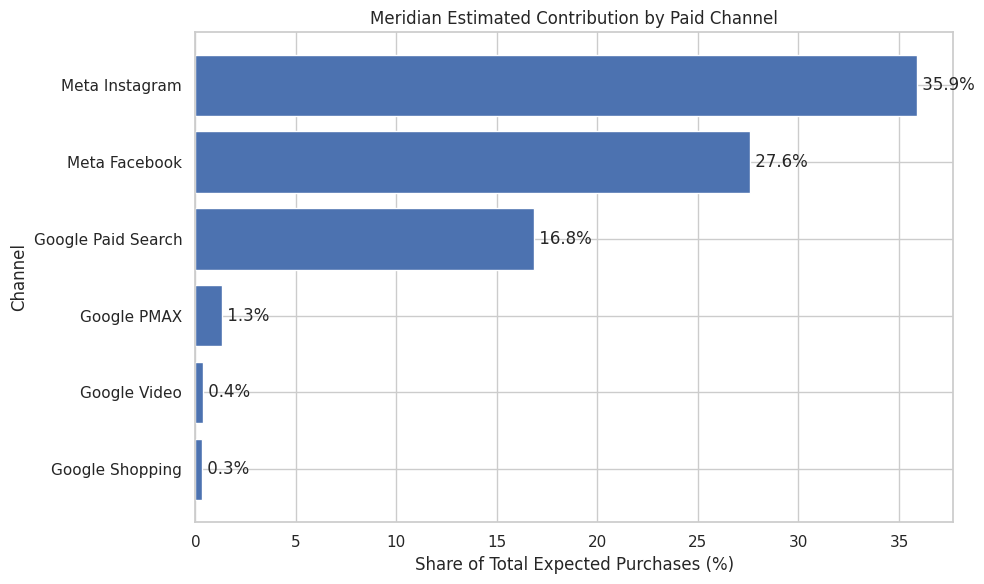

In [88]:
paid_contribution_plot_df = (
    channel_contribution_clean[
        channel_contribution_clean["channel"]
        != "baseline"
    ]
    .copy()
    .sort_values(
        "contribution_percentage",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    paid_contribution_plot_df["channel"],
    paid_contribution_plot_df[
        "contribution_percentage"
    ],
)

ax.set_title(
    "Meridian Estimated Contribution by Paid Channel"
)
ax.set_xlabel(
    "Share of Total Expected Purchases (%)"
)
ax.set_ylabel("Channel")

for index, value in enumerate(
    paid_contribution_plot_df[
        "contribution_percentage"
    ]
):
    ax.text(
        value,
        index,
        f" {value:.1f}%",
        va="center",
    )

plt.tight_layout()

fig.savefig(
    CHART_DIR
    / "meridian_paid_channel_contribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Channel Contribution Results

Meta Instagram generated the largest estimated contribution, accounting for
approximately 35.90% of total modeled purchases. Meta Facebook followed with
27.56%, while Google Paid Search contributed 16.84%.

Together, Facebook and Instagram accounted for approximately 63.54% of expected
purchases. This is consistent with their dominant share of historical media
investment.

The estimated baseline accounted for approximately 17.66% of purchases. This
represents purchases attributed to underlying demand, controls, trend, and
seasonality rather than paid-media execution.

Google PMAX, Google Video, and Google Shopping made relatively small historical
contributions. However, contribution alone does not measure efficiency. ROI and
marginal ROI will be used to determine whether each channel's contribution was
large relative to its spend.

### Adstock and Lagged Media Effects

Adstock represents the delayed and carryover effect of advertising.

A media exposure may influence purchases immediately and can continue to affect
customer behavior during subsequent days. Because the dataset is daily and the
model uses a maximum lag of eight days, the estimated carryover is examined
across the current day and the following eight days.

In [89]:
from meridian.analysis import visualizer

media_effects = visualizer.MediaEffects(
    meridian=mmm_final,
    use_kpi=True,
)

adstock_decay_df = (
    media_effects.adstock_decay_dataframe(
        confidence_level=0.90
    )
)

print("Adstock dataframe shape:", adstock_decay_df.shape)
print("Columns:", adstock_decay_df.columns.tolist())

display(adstock_decay_df.head(20))

Adstock dataframe shape: (480, 7)
Columns: ['channel', 'time_units', 'distribution', 'ci_hi', 'ci_lo', 'mean', 'is_int_time_unit']


metric,channel,time_units,distribution,ci_hi,ci_lo,mean,is_int_time_unit
0,Google PMAX,0.0,posterior,1.000000,1.000000,1.000000,True
1,Google PMAX,0.0,prior,1.000000,1.000000,1.000000,True
2,Google PMAX,0.2,posterior,0.992036,0.568618,0.843411,False
3,Google PMAX,0.2,prior,0.991526,0.540878,0.831445,False
4,Google PMAX,0.4,posterior,0.984135,0.323327,0.729804,False
5,Google PMAX,0.4,prior,0.983123,0.292551,0.711544,False
6,Google PMAX,0.6,posterior,0.976297,0.183850,0.643578,False
7,Google PMAX,0.6,prior,0.974792,0.158236,0.622280,False
8,Google PMAX,0.8,posterior,0.968521,0.104541,0.575832,False
9,Google PMAX,0.8,prior,0.966531,0.085588,0.553384,False


In [90]:
adstock_chart = media_effects.plot_adstock_decay(
    confidence_level=0.90,
    include_ci=True,
)

adstock_chart

alt.FacetChart(...)

In [91]:
adstock_chart.save(
    str(
        CHART_DIR
        / "meridian_adstock_decay.html"
    )
)

print("Interactive adstock chart saved.")

Interactive adstock chart saved.


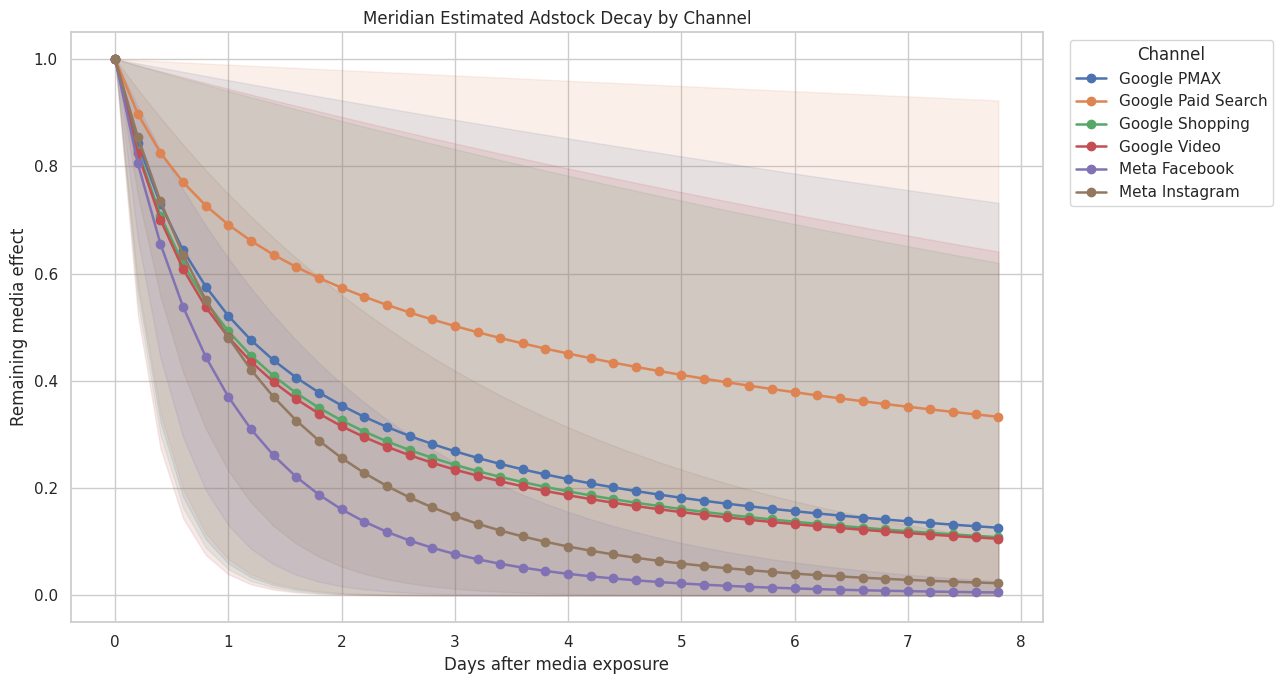

In [92]:
posterior_adstock_df = (
    adstock_decay_df.loc[
        adstock_decay_df["distribution"]
        == "posterior"
    ]
    .copy()
)

fig, ax = plt.subplots(figsize=(13, 7))

for channel, channel_data in posterior_adstock_df.groupby(
    "channel"
):
    channel_data = channel_data.sort_values(
        "time_units"
    )

    line = ax.plot(
        channel_data["time_units"],
        channel_data["mean"],
        marker="o",
        linewidth=1.8,
        label=channel,
    )[0]

    ax.fill_between(
        channel_data["time_units"],
        channel_data["ci_lo"],
        channel_data["ci_hi"],
        alpha=0.12,
        color=line.get_color(),
    )

ax.set_title(
    "Meridian Estimated Adstock Decay by Channel"
)
ax.set_xlabel("Days after media exposure")
ax.set_ylabel("Remaining media effect")
ax.legend(
    title="Channel",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    CHART_DIR / "meridian_adstock_decay.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [93]:
def estimate_half_life(channel_data, threshold=0.50):
    channel_data = (
        channel_data
        .sort_values("time_units")
        .reset_index(drop=True)
    )

    below_threshold = channel_data[
        channel_data["mean"] <= threshold
    ]

    if below_threshold.empty:
        return f">{channel_data['time_units'].max():.1f}"

    first_below_index = below_threshold.index[0]

    if first_below_index == 0:
        return 0.0

    previous_row = channel_data.iloc[first_below_index - 1]
    current_row = channel_data.iloc[first_below_index]

    x0 = previous_row["time_units"]
    y0 = previous_row["mean"]

    x1 = current_row["time_units"]
    y1 = current_row["mean"]

    # Linear interpolation around the 50% effect level.
    estimated_half_life = (
        x0
        + (threshold - y0)
        * (x1 - x0)
        / (y1 - y0)
    )

    return round(float(estimated_half_life), 2)


def nearest_effect(channel_data, day):
    nearest_index = (
        channel_data["time_units"] - day
    ).abs().idxmin()

    return float(
        channel_data.loc[nearest_index, "mean"]
    )


adstock_summary_rows = []

for channel, channel_data in posterior_adstock_df.groupby(
    "channel"
):
    adstock_summary_rows.append({
        "channel": channel,
        "estimated_half_life_days": estimate_half_life(
            channel_data
        ),
        "effect_after_1_day": nearest_effect(
            channel_data, 1
        ),
        "effect_after_3_days": nearest_effect(
            channel_data, 3
        ),
        "effect_after_7_days": nearest_effect(
            channel_data, 7
        ),
    })


adstock_summary = (
    pd.DataFrame(adstock_summary_rows)
    .sort_values(
        "effect_after_7_days",
        ascending=False
    )
    .reset_index(drop=True)
)

numeric_columns = [
    "effect_after_1_day",
    "effect_after_3_days",
    "effect_after_7_days",
]

adstock_summary[numeric_columns] = (
    adstock_summary[numeric_columns]
    .round(3)
)

display(adstock_summary)

,channel,estimated_half_life_days,effect_after_1_day,effect_after_3_days,effect_after_7_days
0,Google Paid Search,3.04,0.691,0.502,0.352
1,Google PMAX,1.09,0.521,0.269,0.138
2,Google Shopping,0.97,0.492,0.244,0.120
3,Google Video,0.93,0.481,0.235,0.116
4,Meta Instagram,0.95,0.481,0.148,0.029
5,Meta Facebook,0.68,0.370,0.077,0.008


In [94]:
adstock_summary.to_csv(
    TABLE_DIR / "meridian_adstock_summary.csv",
    index=False,
)

print("Adstock summary saved.")

Adstock summary saved.


### Adstock Results

Google Paid Search demonstrates the strongest and longest-lasting carryover
effect. Its estimated media-effect half-life is approximately 3.04 days, and
about 35.2% of its initial effect remains after seven days.

Google PMAX, Google Shopping, Google Video, and Meta Instagram have estimated
half-lives close to one day, indicating that most of their impact occurs shortly
after exposure.

Meta Facebook has the shortest estimated carryover, with a half-life of
approximately 0.68 days. Only about 0.8% of its initial effect remains after
seven days.

These findings suggest that Paid Search campaigns may continue influencing
purchases for several days, while Meta activity is more dependent on immediate
and continuous exposure. Exact decay estimates should be interpreted cautiously
because some channel credible intervals remain wide.

### Hill Saturation Effects

Hill curves represent diminishing returns from media exposure.

At lower exposure levels, additional impressions may produce meaningful gains.
As exposure increases, the response curve begins to flatten, indicating that
the channel is approaching saturation and that additional impressions generate
smaller incremental effects.

In [95]:
hill_curves_df = media_effects.hill_curves_dataframe(
    confidence_level=0.90
)

print("Hill curve dataframe shape:", hill_curves_df.shape)
print("Columns:")
print(hill_curves_df.columns.tolist())

display(hill_curves_df.head(20))

Hill curve dataframe shape: (6150, 11)
Columns:
['channel', 'media_units', 'distribution', 'ci_hi', 'ci_lo', 'mean', 'channel_type', 'scaled_count_histogram', 'count_histogram', 'start_interval_histogram', 'end_interval_histogram']


,channel,media_units,distribution,ci_hi,ci_lo,mean,channel_type,scaled_count_histogram,count_histogram,start_interval_histogram,end_interval_histogram
0,Google Paid Search,0.000000,posterior,0.000000,0.000000,0.000000,media,NaN,NaN,NaN,NaN
1,Google Paid Search,0.000000,prior,0.000000,0.000000,0.000000,media,NaN,NaN,NaN,NaN
2,Google Paid Search,120.647293,posterior,0.065883,0.022617,0.039767,media,NaN,NaN,NaN,NaN
3,Google Paid Search,120.647293,prior,0.170042,0.024302,0.065466,media,NaN,NaN,NaN,NaN
4,Google Paid Search,241.294586,posterior,0.123622,0.044234,0.076134,media,NaN,NaN,NaN,NaN
5,Google Paid Search,241.294586,prior,0.290660,0.047451,0.119329,media,NaN,NaN,NaN,NaN
6,Google Paid Search,361.941864,posterior,0.174638,0.064915,0.109569,media,NaN,NaN,NaN,NaN
7,Google Paid Search,361.941864,prior,0.380668,0.069528,0.165308,media,NaN,NaN,NaN,NaN
8,Google Paid Search,482.589172,posterior,0.220042,0.084720,0.140449,media,NaN,NaN,NaN,NaN
9,Google Paid Search,482.589172,prior,0.450405,0.090604,0.205441,media,NaN,NaN,NaN,NaN


In [96]:
hill_curve_plots = media_effects.plot_hill_curves(
    confidence_level=0.90,
    include_prior=False,
    include_ci=True,
)

print("Available chart types:")
print(hill_curve_plots.keys())

Available chart types:
dict_keys(['media'])


In [97]:
hill_media_chart = hill_curve_plots["media"]

hill_media_chart

alt.FacetChart(...)

In [98]:
hill_media_chart.save(
    str(CHART_DIR / "meridian_hill_saturation_curves.html")
)

print("Hill saturation chart saved.")

Hill saturation chart saved.


In [99]:
hill_curves_df.to_csv(
    TABLE_DIR / "meridian_hill_curves.csv",
    index=False
)

print("Hill curve data saved.")

Hill curve data saved.


In [100]:
posterior_hill_df = (
    hill_curves_df.loc[
        (hill_curves_df["distribution"] == "posterior")
        & (hill_curves_df["channel_type"] == "media")
    ]
    .dropna(subset=["media_units", "mean"])
    .copy()
)


def estimate_half_saturation_units(curve_df):
    curve_df = curve_df.sort_values("media_units")

    if curve_df["mean"].max() < 0.50:
        return np.nan

    return float(
        np.interp(
            0.50,
            curve_df["mean"],
            curve_df["media_units"],
        )
    )


saturation_rows = []

for channel, details in MEDIA_CHANNELS.items():
    exposure_column = details["impressions"]

    observed_exposure = (
        model_df[exposure_column]
        .fillna(0)
    )

    active_exposure = observed_exposure[
        observed_exposure > 0
    ]

    channel_curve = (
        posterior_hill_df.loc[
            posterior_hill_df["channel"] == channel
        ]
        .sort_values("media_units")
    )

    curve_x = channel_curve["media_units"].to_numpy()
    curve_y = channel_curve["mean"].to_numpy()

    median_exposure = active_exposure.median()
    p75_exposure = active_exposure.quantile(0.75)

    hill_level_at_median = float(
        np.interp(
            median_exposure,
            curve_x,
            curve_y,
        )
    )

    hill_level_plus_10 = float(
        np.interp(
            median_exposure * 1.10,
            curve_x,
            curve_y,
        )
    )

    half_saturation_units = (
        estimate_half_saturation_units(
            channel_curve
        )
    )

    saturation_rows.append({
        "channel": channel,
        "median_active_impressions": median_exposure,
        "p75_active_impressions": p75_exposure,
        "half_saturation_media_units": half_saturation_units,
        "median_to_half_saturation_ratio": (
            median_exposure / half_saturation_units
            if pd.notna(half_saturation_units)
            and half_saturation_units > 0
            else np.nan
        ),
        "hill_level_at_median": hill_level_at_median,
        "hill_level_after_10pct_more_exposure": hill_level_plus_10,
        "absolute_gain_from_10pct_more_exposure": (
            hill_level_plus_10
            - hill_level_at_median
        ),
        "relative_gain_from_10pct_more_exposure_pct": (
            (
                hill_level_plus_10
                - hill_level_at_median
            )
            / hill_level_at_median
            * 100
            if hill_level_at_median > 0
            else np.nan
        ),
    })


saturation_summary = (
    pd.DataFrame(saturation_rows)
    .sort_values(
        "relative_gain_from_10pct_more_exposure_pct"
    )
    .reset_index(drop=True)
)

display(
    saturation_summary.round(3)
)

,channel,median_active_impressions,p75_active_impressions,half_saturation_media_units,median_to_half_saturation_ratio,hill_level_at_median,hill_level_after_10pct_more_exposure,absolute_gain_from_10pct_more_exposure,relative_gain_from_10pct_more_exposure_pct
0,Google PMAX,42344.5,48559.00,28532.207,1.484,0.586,0.607,0.020,3.474
1,Google Shopping,5585.0,13504.25,5213.308,1.071,0.514,0.536,0.022,4.211
2,Google Video,25590.0,51034.50,26920.157,0.951,0.488,0.510,0.022,4.516
3,Google Paid Search,2262.0,4582.00,3086.058,0.733,0.425,0.448,0.023,5.359
4,Meta Instagram,349181.0,518504.00,589007.837,0.593,0.374,0.396,0.022,5.936
5,Meta Facebook,186328.0,344457.50,394476.623,0.472,0.323,0.344,0.021,6.461


In [101]:
saturation_summary.to_csv(
    TABLE_DIR / "meridian_saturation_summary.csv",
    index=False,
)

print("Saturation summary saved.")

Saturation summary saved.


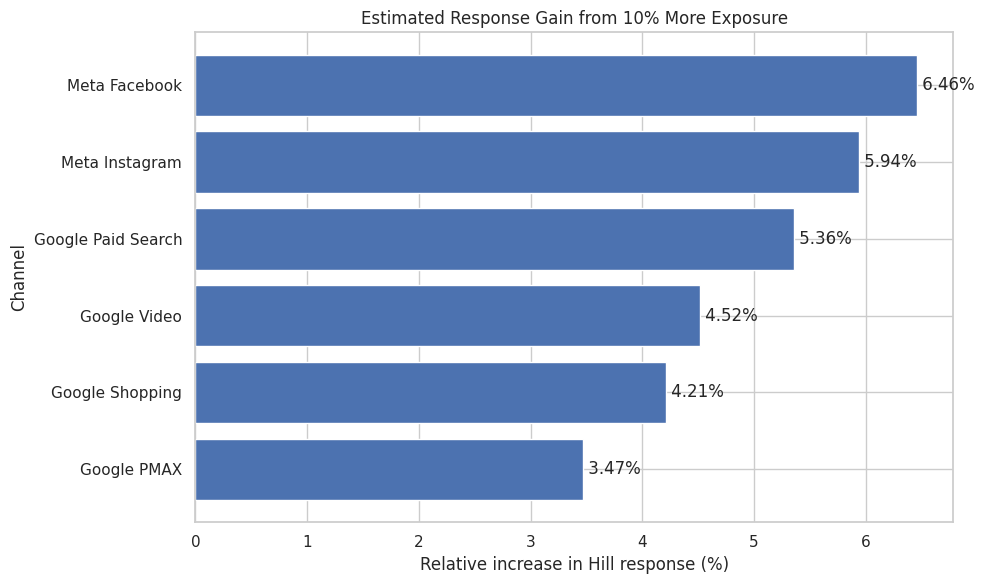

In [102]:
saturation_plot_df = (
    saturation_summary
    .sort_values(
        "relative_gain_from_10pct_more_exposure_pct",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    saturation_plot_df["channel"],
    saturation_plot_df[
        "relative_gain_from_10pct_more_exposure_pct"
    ],
)

ax.set_title(
    "Estimated Response Gain from 10% More Exposure"
)
ax.set_xlabel(
    "Relative increase in Hill response (%)"
)
ax.set_ylabel("Channel")

for index, value in enumerate(
    saturation_plot_df[
        "relative_gain_from_10pct_more_exposure_pct"
    ]
):
    ax.text(
        value,
        index,
        f" {value:.2f}%",
        va="center",
    )

plt.tight_layout()

fig.savefig(
    CHART_DIR / "meridian_saturation_headroom.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Saturation Results

Google PMAX appears to be the most saturated channel. Its median active
exposure is approximately 1.48 times its estimated half-saturation level, and a
10% increase in exposure produces only a 3.47% increase in Hill response.

Google Shopping is also operating slightly above its half-saturation point,
while Google Video is close to that threshold.

Google Paid Search remains below its estimated half-saturation exposure and
shows moderate room for additional scaling.

Meta Instagram and Meta Facebook operate below their estimated half-saturation
levels and show the greatest relative response gains from a 10% increase in
exposure. However, these channels already account for most historical spend, so
their financial efficiency must be evaluated using ROI and marginal ROI before
recommending additional investment.

Hill saturation describes exposure response rather than profitability.
Therefore, the final over-investment and under-investment conclusions will be
based on saturation, ROI, and marginal ROI together.

### Task 3 Summary

A national-level Bayesian Marketing Mix Model was trained using Google Meridian.

The model included six paid-media channels, sixteen control variables,
geometric adstock with an eight-day maximum lag, and Hill saturation
transformations.

The final posterior contained 2,000 retained samples across four MCMC chains.
All examined R-hat values were below 1.01, and no divergent transitions were
observed.

The model achieved an R² of 0.746 on training observations and 0.710 on
Meridian holdout observations. Holdout weighted MAPE was approximately 15.92%.

Meta Instagram generated the largest estimated purchase contribution, followed
by Meta Facebook and Google Paid Search.

Google Paid Search demonstrated the longest carryover effect, with an estimated
half-life of 3.04 days. Meta Facebook had the shortest carryover.

Hill-curve analysis indicated that Google PMAX and Google Shopping were the
most saturated channels at their typical exposure levels. Meta Facebook and
Meta Instagram showed greater exposure headroom, although profitability must
still be assessed through ROI and marginal ROI.

In [103]:
import inspect

media_summary_revenue = visualizer.MediaSummary(
    mmm_final,
    confidence_level=0.90,
    use_kpi=False,
)

relevant_methods = [
    method_name
    for method_name in dir(media_summary_revenue)
    if (
        "roi" in method_name.lower()
        or "response" in method_name.lower()
        or "summary" in method_name.lower()
    )
    and not method_name.startswith("_")
]

print("Relevant MediaSummary methods:")
for method_name in relevant_methods:
    attribute = getattr(
        media_summary_revenue,
        method_name
    )

    if callable(attribute):
        try:
            signature = inspect.signature(attribute)
        except (TypeError, ValueError):
            signature = "Signature unavailable"

        print(f"- {method_name}{signature}")
    else:
        print(f"- {method_name}")

Relevant MediaSummary methods:


/tmp/ipykernel_224636/2643738761.py:22: DeprecationWarning: The `all_summary_metrics` property is deprecated. Use the `get_all_summary_metrics()` method instead.
  attribute = getattr(


- all_summary_metrics
- get_all_summary_metrics(aggregate_times: bool = True) -> xarray.core.dataset.Dataset
- get_paid_summary_metrics(aggregate_times: bool = True) -> xarray.core.dataset.Dataset


/tmp/ipykernel_224636/2643738761.py:22: DeprecationWarning: The `paid_summary_metrics` property is deprecated. Use the `get_paid_summary_metrics()` method instead.
  attribute = getattr(


- paid_summary_metrics
- plot_roi_bar_chart(include_ci: bool = True) -> altair.vegalite.v6.api.Chart
- plot_roi_vs_effectiveness(selected_channels: collections.abc.Sequence[str] | None = None, disable_size: bool = False) -> altair.vegalite.v6.api.Chart
- plot_roi_vs_mroi(selected_channels: collections.abc.Sequence[str] | None = None, disable_size: bool = False, equal_axes: bool = False) -> altair.vegalite.v6.api.Chart
- summary_table(include_prior: bool = True, include_posterior: bool = True, include_non_paid_channels: bool = False, currency: str = '$') -> pandas.core.frame.DataFrame
- update_summary_metrics(confidence_level: float | None = None, selected_times: collections.abc.Sequence[str] | None = None, marginal_roi_by_reach: bool = True, non_media_baseline_values: collections.abc.Sequence[float] | None = None)


## Task 4: ROI and Marginal ROI Analysis

Historical ROI measures the incremental revenue generated for each dollar of
historical media spend.

Marginal ROI estimates the expected revenue generated by the next incremental
dollar of spend. A channel may have strong historical ROI but weaker marginal
ROI when it is approaching saturation.

In [104]:
paid_summary_metrics = (
    media_summary_revenue
    .get_paid_summary_metrics(
        aggregate_times=True
    )
)

print(paid_summary_metrics)

print("\nAvailable variables:")
print(list(paid_summary_metrics.data_vars))

print("\nDimensions:")
print(paid_summary_metrics.sizes)

<xarray.Dataset> Size: 2kB
Dimensions:              (channel: 7, metric: 4, distribution: 2)
Coordinates:
  * channel              (channel) <U18 504B 'Google Paid Search' ... 'All Ch...
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
  * distribution         (distribution) <U9 72B 'prior' 'posterior'
Data variables:
    impressions          (channel) float32 28B 4.144e+06 2.054e+07 ... 7.909e+08
    pct_of_impressions   (channel) float32 28B 0.524 2.598 3.246 ... 53.94 100.0
    spend                (channel) float32 28B 4.397e+05 7.455e+04 ... 9.052e+06
    pct_of_spend         (channel) float32 28B 4.858 0.8236 ... 50.01 100.0
    cpm                  (channel) float32 28B 106.1 3.629 13.47 ... 10.61 11.45
    incremental_outcome  (channel, metric, distribution) float32 224B 8.254e+...
    pct_of_contribution  (channel, metric, distribution) float32 224B 1.692 ....
    roi                  (channel, metric, distribution) float32 224B 1.877 ....
    effectiv

In [105]:
roi_summary_table = (
    media_summary_revenue
    .summary_table(
        include_prior=False,
        include_posterior=True,
        include_non_paid_channels=False,
        currency="$",
    )
)

display(roi_summary_table)

/home/muzzamil/.virtualenvs/marketing-mmm/lib/python3.11/site-packages/meridian/analysis/visualizer.py:1728: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .aggregate(lambda g: f'{g[0]} ({g[1]}, {g[2]})')


,channel,distribution,impressions,% impressions,spend,% spend,cpm,incremental outcome,% contribution,roi,effectiveness,mroi,cpik
0,Google Paid Search,posterior,"4,143,918",0.5%,"$439,709",4.9%,$106,"$5,068,475 ($2,644,638, $7,743,074)","16.9% (8.8%, 25.8%)","11.5 (6.0, 17.6)","1.22 (0.64, 1.87)","5.4 (2.9, 7.9)","$7 ($5, $14)"
1,Google Shopping,posterior,"20,544,892",2.6%,"$74,550",0.8%,$4,"$103,577 ($20,188, $274,056)","0.3% (0.1%, 0.9%)","1.4 (0.3, 3.7)","0.01 (0.00, 0.01)","0.5 (0.1, 1.2)","$86 ($25, $328)"
2,Google PMAX,posterior,"25,673,552",3.2%,"$345,905",3.8%,$13,"$389,498 ($87,046, $952,338)","1.3% (0.3%, 3.2%)","1.1 (0.3, 2.8)","0.02 (0.00, 0.04)","0.4 (0.1, 1.1)","$91 ($29, $320)"
3,Google Video,posterior,"13,260,225",1.7%,"$124,155",1.4%,$9,"$111,047 ($25,921, $269,502)","0.4% (0.1%, 0.9%)","0.9 (0.2, 2.2)","0.01 (0.00, 0.02)","0.4 (0.1, 1.1)","$114 ($38, $391)"
4,Meta Facebook,posterior,"300,639,840",38.0%,"$3,540,414",39.1%,$12,"$8,513,365 ($6,691,482, $10,520,033)","28.3% (22.3%, 35.0%)","2.4 (1.9, 3.0)","0.03 (0.02, 0.03)","1.4 (1.1, 1.7)","$36 ($29, $45)"
5,Meta Instagram,posterior,"426,602,880",53.9%,"$4,527,420",50.0%,$11,"$10,557,022 ($8,470,535, $12,762,436)","35.1% (28.2%, 42.5%)","2.3 (1.9, 2.8)","0.02 (0.02, 0.03)","1.3 (1.0, 1.6)","$35 ($29, $44)"
6,All Channels,posterior,"790,865,280",100.0%,"$9,052,154",100.0%,$11,"$24,742,968 ($21,194,150, $28,559,672)","82.3% (70.5%, 95.0%)","2.7 (2.3, 3.2)","nan (nan, nan)","nan (nan, nan)","$31 ($27, $36)"


In [106]:
roi_summary_table.to_csv(
    TABLE_DIR / "meridian_roi_summary_table.csv"
)

print("ROI summary table saved.")

ROI summary table saved.


In [107]:
roi_bar_chart = (
    media_summary_revenue
    .plot_roi_bar_chart(
        include_ci=True
    )
)

roi_bar_chart

alt.LayerChart(...)

In [108]:
roi_bar_chart.save(
    str(CHART_DIR / "meridian_roi_bar_chart.html")
)

print("ROI chart saved.")

ROI chart saved.


In [109]:
roi_vs_mroi_chart = (
    media_summary_revenue
    .plot_roi_vs_mroi(
        equal_axes=True
    )
)

roi_vs_mroi_chart

alt.Chart(...)

In [110]:
roi_vs_mroi_chart.save(
    str(CHART_DIR / "meridian_roi_vs_mroi.html")
)

print("ROI versus mROI chart saved.")

ROI versus mROI chart saved.


In [111]:
posterior_paid_metrics = (
    paid_summary_metrics
    .sel(
        distribution="posterior",
        metric="mean",
    )
)

roi_mroi_clean = pd.DataFrame({
    "channel": posterior_paid_metrics[
        "channel"
    ].values,
    "spend": posterior_paid_metrics[
        "spend"
    ].values,
    "incremental_revenue": posterior_paid_metrics[
        "incremental_outcome"
    ].values,
    "roi": posterior_paid_metrics[
        "roi"
    ].values,
    "mroi": posterior_paid_metrics[
        "mroi"
    ].values,
    "pct_of_spend": posterior_paid_metrics[
        "pct_of_spend"
    ].values,
    "pct_of_contribution": posterior_paid_metrics[
        "pct_of_contribution"
    ].values,
})

roi_mroi_clean = roi_mroi_clean.loc[
    roi_mroi_clean["channel"] != "All Channels"
].copy()

roi_mroi_clean["roi_minus_mroi"] = (
    roi_mroi_clean["roi"]
    - roi_mroi_clean["mroi"]
)

roi_mroi_clean = (
    roi_mroi_clean
    .sort_values("mroi", ascending=False)
    .reset_index(drop=True)
)

display(roi_mroi_clean.round(3))

,channel,spend,incremental_revenue,roi,mroi,pct_of_spend,pct_of_contribution,roi_minus_mroi
0,Google Paid Search,4.397089e+05,5.068475e+06,11.527,5.405,4.858000,16.865999,6.121
1,Meta Facebook,3.540414e+06,8.513365e+06,2.405,1.424,39.111000,28.329000,0.981
2,Meta Instagram,4.527420e+06,1.055702e+07,2.332,1.328,50.014999,35.129002,1.004
3,Google Shopping,7.455049e+04,1.035767e+05,1.389,0.462,0.824000,0.345000,0.927
4,Google PMAX,3.459055e+05,3.894980e+05,1.126,0.440,3.821000,1.296000,0.686
5,Google Video,1.241547e+05,1.110471e+05,0.894,0.401,1.372000,0.370000,0.493


In [112]:
def classify_investment_status(row):
    if row["mroi"] >= 2:
        return "Strong scale opportunity"

    if row["mroi"] >= 1:
        return "Profitable incremental investment"

    if row["roi"] >= 1 and row["mroi"] < 1:
        return "Historically profitable, reduce or hold"

    return "Below break-even, reduce investment"


roi_mroi_clean["investment_status"] = (
    roi_mroi_clean.apply(
        classify_investment_status,
        axis=1,
    )
)

display(
    roi_mroi_clean[
        [
            "channel",
            "spend",
            "incremental_revenue",
            "roi",
            "mroi",
            "investment_status",
        ]
    ].round(2)
)

,channel,spend,incremental_revenue,roi,mroi,investment_status
0,Google Paid Search,4.397089e+05,5.068475e+06,11.53,5.41,Strong scale opportunity
1,Meta Facebook,3.540414e+06,8.513365e+06,2.40,1.42,Profitable incremental investment
2,Meta Instagram,4.527420e+06,1.055702e+07,2.33,1.33,Profitable incremental investment
3,Google Shopping,7.455050e+04,1.035767e+05,1.39,0.46,"Historically profitable, reduce or hold"
4,Google PMAX,3.459055e+05,3.894980e+05,1.13,0.44,"Historically profitable, reduce or hold"
5,Google Video,1.241547e+05,1.110471e+05,0.89,0.40,"Below break-even, reduce investment"


In [113]:
roi_mroi_clean.to_csv(
    TABLE_DIR / "meridian_roi_mroi_clean.csv",
    index=False,
)

print("Clean ROI and mROI table saved.")

Clean ROI and mROI table saved.


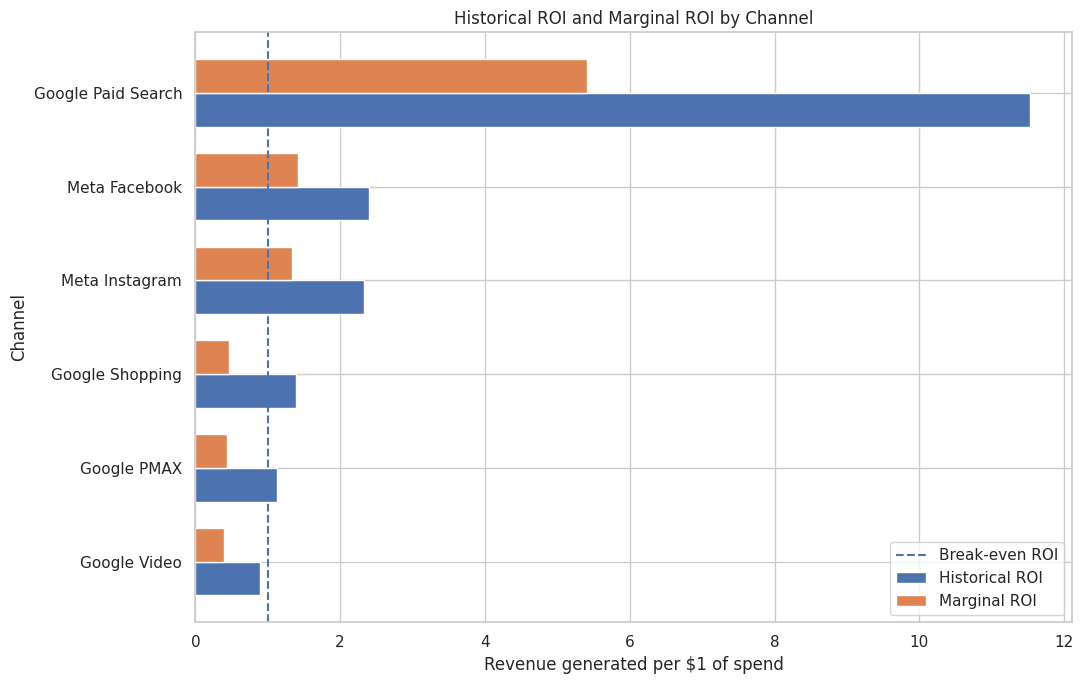

In [114]:
roi_plot_df = (
    roi_mroi_clean
    .sort_values("mroi", ascending=True)
)

y_positions = np.arange(len(roi_plot_df))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    y_positions - bar_height / 2,
    roi_plot_df["roi"],
    height=bar_height,
    label="Historical ROI",
)

ax.barh(
    y_positions + bar_height / 2,
    roi_plot_df["mroi"],
    height=bar_height,
    label="Marginal ROI",
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1.5,
    label="Break-even ROI",
)

ax.set_yticks(y_positions)
ax.set_yticklabels(roi_plot_df["channel"])

ax.set_title("Historical ROI and Marginal ROI by Channel")
ax.set_xlabel("Revenue generated per $1 of spend")
ax.set_ylabel("Channel")
ax.legend()

plt.tight_layout()

fig.savefig(
    CHART_DIR / "meridian_roi_mroi_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### ROI and Marginal ROI Results

Google Paid Search is the strongest-performing channel. It achieved a historical
ROI of approximately 11.53 and a marginal ROI of 5.41. This indicates that Paid
Search generated high historical efficiency and still has substantial room for
profitable additional investment.

Meta Facebook and Meta Instagram achieved historical ROIs of approximately 2.40
and 2.33. Their marginal ROIs remain above the break-even level at 1.42 and
1.33, respectively. Additional spend may therefore remain profitable, although
both channels already account for most historical media investment.

Google Shopping and Google PMAX achieved historical ROIs slightly above 1.0,
but their marginal ROIs fell below 0.5. This indicates that historical investment
was profitable overall, but further spending at current exposure levels is
unlikely to generate sufficient incremental revenue.

Google Video recorded a historical ROI below 1.0 and a marginal ROI of
approximately 0.40. It is therefore the clearest candidate for reduced
investment unless it serves an important brand-awareness objective not captured
by purchase revenue.

The recommended priority is to shift incremental budget toward Google Paid
Search, followed by controlled additions to Meta Facebook and Meta Instagram.
PMAX, Shopping, and Video should be reduced or held until their marginal returns
improve.

## Task 5: SHAP Explainability

SHAP is used to explain how media and control variables influence the model's
expected-purchase predictions.

Because Meridian is a Bayesian Marketing Mix Model rather than a conventional
scikit-learn estimator, a nonlinear surrogate model is trained to reproduce
Meridian's posterior mean expected purchases.

SHAP values are then calculated from the surrogate model. Therefore, the SHAP
analysis explains the predictive patterns learned by Meridian but does not
replace Meridian's causal contribution, ROI, or marginal ROI estimates.

In [115]:
import shap
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
)

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [116]:
# Meridian predictions will become the surrogate model's target.
shap_prediction_df = (
    fit_results_df[
        [
            "DATE_DAY",
            "EXPECTED_PURCHASES",
            "IS_HOLDOUT",
        ]
    ]
    .copy()
)

shap_prediction_df["DATE_DAY"] = pd.to_datetime(
    shap_prediction_df["DATE_DAY"]
)

# The Meridian prediction model uses media exposure and controls.
shap_feature_columns = (
    selected_exposure_columns
    + control_columns
)

shap_model_df = (
    modeling_df[
        ["DATE_DAY"] + shap_feature_columns
    ]
    .copy()
)

shap_model_df["DATE_DAY"] = pd.to_datetime(
    shap_model_df["DATE_DAY"]
)

shap_model_df = shap_model_df.merge(
    shap_prediction_df,
    on="DATE_DAY",
    how="inner",
    validate="one_to_one",
)

shap_model_df = (
    shap_model_df
    .sort_values("DATE_DAY")
    .reset_index(drop=True)
)

print("SHAP modeling rows:", len(shap_model_df))
print("Number of features:", len(shap_feature_columns))
print("Missing values:", shap_model_df.isna().sum().sum())

display(shap_model_df.head())

SHAP modeling rows: 1276
Number of features: 22
Missing values: 0


,DATE_DAY,GOOGLE_PAID_SEARCH_IMPRESSIONS,GOOGLE_SHOPPING_IMPRESSIONS,GOOGLE_PMAX_IMPRESSIONS,GOOGLE_VIDEO_IMPRESSIONS,META_FACEBOOK_IMPRESSIONS,META_INSTAGRAM_IMPRESSIONS,TREND,DOW_Friday,DOW_Saturday,DOW_Sunday,DOW_Thursday,DOW_Tuesday,DOW_Wednesday,YEAR_SIN_1,YEAR_COS_1,YEAR_SIN_2,YEAR_COS_2,BLACK_FRIDAY_PERIOD,LOG_ORGANIC_SEARCH_CLICKS,LOG_EMAIL_CLICKS,LOG_REFERRAL_CLICKS,LOG_ALL_OTHER_CLICKS,EXPECTED_PURCHASES,IS_HOLDOUT
0,2020-11-21,773.0,59850.0,0.0,0.0,99163.0,0.0,0.000000,0,1,0,0,0,0,0.000000,1.000000,0.000000,1.000000,0,0.0,0.0,0.0,0.0,66.156799,False
1,2020-11-22,773.0,71318.0,0.0,0.0,394931.0,0.0,0.000784,0,0,1,0,0,0,0.017202,0.999852,0.034398,0.999408,0,0.0,0.0,0.0,0.0,162.138596,False
2,2020-11-23,897.0,62824.0,0.0,0.0,254403.0,0.0,0.001569,0,0,0,0,0,0,0.034398,0.999408,0.068755,0.997634,0,0.0,0.0,0.0,0.0,144.398727,False
3,2020-11-24,1105.0,57843.0,0.0,0.0,165212.0,0.0,0.002353,0,0,0,0,1,0,0.051584,0.998669,0.103031,0.994678,0,0.0,0.0,0.0,0.0,113.410912,False
4,2020-11-25,1266.0,63830.0,0.0,0.0,111504.0,0.0,0.003137,0,0,0,0,0,1,0.068755,0.997634,0.137185,0.990545,0,0.0,0.0,0.0,0.0,95.948242,False


In [117]:
feature_name_map = {
    details["impressions"]: channel
    for channel, details in MEDIA_CHANNELS.items()
}

feature_name_map.update({
    column: (
        column
        .replace("_", " ")
        .title()
    )
    for column in control_columns
})

X_shap = (
    shap_model_df[shap_feature_columns]
    .rename(columns=feature_name_map)
    .astype(float)
)

y_shap = (
    shap_model_df["EXPECTED_PURCHASES"]
    .astype(float)
)

shap_holdout_mask = (
    shap_model_df["IS_HOLDOUT"]
    .astype(bool)
)

X_shap_train = X_shap.loc[
    ~shap_holdout_mask
].copy()

X_shap_holdout = X_shap.loc[
    shap_holdout_mask
].copy()

y_shap_train = y_shap.loc[
    ~shap_holdout_mask
].copy()

y_shap_holdout = y_shap.loc[
    shap_holdout_mask
].copy()

print("Training rows:", len(X_shap_train))
print("Holdout rows:", len(X_shap_holdout))
print("\nSHAP features:")

for feature in X_shap.columns:
    print("-", feature)

Training rows: 1021
Holdout rows: 255

SHAP features:
- Google Paid Search
- Google Shopping
- Google PMAX
- Google Video
- Meta Facebook
- Meta Instagram
- Trend
- Dow Friday
- Dow Saturday
- Dow Sunday
- Dow Thursday
- Dow Tuesday
- Dow Wednesday
- Year Sin 1
- Year Cos 1
- Year Sin 2
- Year Cos 2
- Black Friday Period
- Log Organic Search Clicks
- Log Email Clicks
- Log Referral Clicks
- Log All Other Clicks


In [118]:
shap_surrogate_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=10,
    min_samples_leaf=3,
    max_features=0.80,
    random_state=42,
    n_jobs=-1,
)

shap_surrogate_model.fit(
    X_shap_train,
    y_shap_train,
)

print("SHAP surrogate trained successfully.")

SHAP surrogate trained successfully.


In [119]:
def calculate_surrogate_metrics(
    actual,
    predicted,
    evaluation_set,
):
    return {
        "evaluation_set": evaluation_set,
        "observations": len(actual),
        "R2": r2_score(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "MAE": mean_absolute_error(actual, predicted),
        "MAPE_PERCENT": (
            mean_absolute_percentage_error(
                actual,
                predicted,
            )
            * 100
        ),
        "CORRELATION": np.corrcoef(
            actual,
            predicted,
        )[0, 1],
    }


surrogate_train_predictions = (
    shap_surrogate_model.predict(
        X_shap_train
    )
)

surrogate_holdout_predictions = (
    shap_surrogate_model.predict(
        X_shap_holdout
    )
)

surrogate_metrics = pd.DataFrame([
    calculate_surrogate_metrics(
        y_shap_train,
        surrogate_train_predictions,
        "Train",
    ),
    calculate_surrogate_metrics(
        y_shap_holdout,
        surrogate_holdout_predictions,
        "Test / Holdout",
    ),
]).round(4)

display(surrogate_metrics)

,evaluation_set,observations,R2,RMSE,MAE,MAPE_PERCENT,CORRELATION
0,Train,1021,0.9915,13.4865,9.5874,5.3966,0.9961
1,Test / Holdout,255,0.9738,21.0552,16.2590,7.5798,0.9877


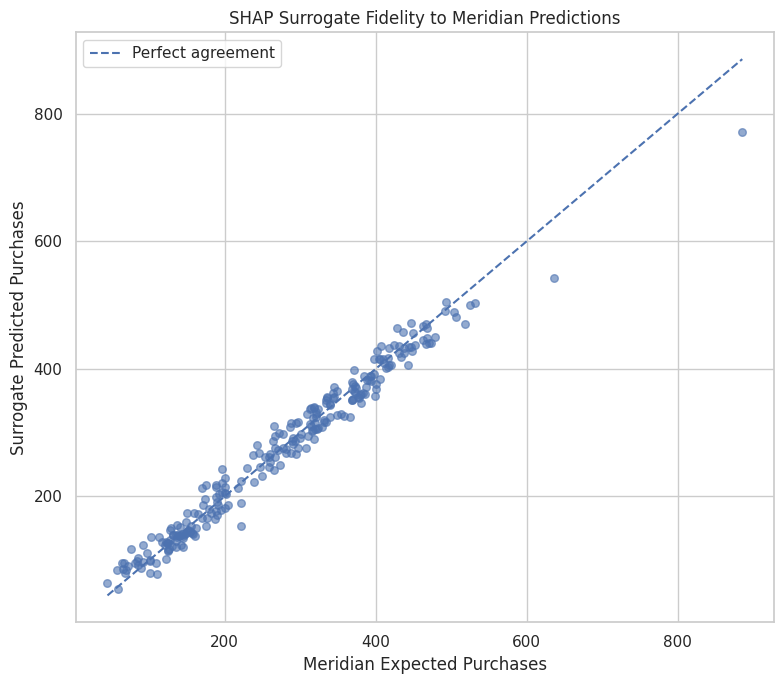

In [120]:
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    y_shap_holdout,
    surrogate_holdout_predictions,
    alpha=0.60,
    s=30,
)

minimum_value = min(
    y_shap_holdout.min(),
    surrogate_holdout_predictions.min(),
)

maximum_value = max(
    y_shap_holdout.max(),
    surrogate_holdout_predictions.max(),
)

ax.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5,
    label="Perfect agreement",
)

ax.set_title(
    "SHAP Surrogate Fidelity to Meridian Predictions"
)
ax.set_xlabel(
    "Meridian Expected Purchases"
)
ax.set_ylabel(
    "Surrogate Predicted Purchases"
)
ax.legend()

plt.tight_layout()

fig.savefig(
    CHART_DIR / "shap_surrogate_fidelity.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [121]:
surrogate_metrics.to_csv(
    TABLE_DIR / "shap_surrogate_metrics.csv",
    index=False,
)

joblib.dump(
    shap_surrogate_model,
    OUTPUT_DIR / "models" / "shap_surrogate_random_forest.joblib",
)

print("SHAP surrogate outputs saved.")

SHAP surrogate outputs saved.


### SHAP Surrogate Fidelity

The Random Forest surrogate reproduced Meridian's posterior expected-purchase
predictions with high fidelity.

On the holdout observations, the surrogate achieved an R² of 0.974, a
correlation of 0.988, and a MAPE of 7.58%. These results indicate that the
surrogate captures the main nonlinear patterns in Meridian's predictions and
is suitable for SHAP-based explainability.

SHAP results are interpreted as explanations of Meridian's predictive patterns.
Meridian remains the primary source for incremental contribution, ROI, mROI,
adstock, and saturation conclusions.

In [123]:
SHAP_SAMPLE_SIZE = min(
    800,
    len(X_shap),
)

X_shap_explain = (
    X_shap
    .sample(
        n=SHAP_SAMPLE_SIZE,
        random_state=42,
    )
    .sort_index()
)

shap_explainer = shap.TreeExplainer(
    shap_surrogate_model
)

shap_explanation = shap_explainer(
    X_shap_explain,
    check_additivity=False,
)

print("Explained observations:", len(X_shap_explain))
print("SHAP values shape:", shap_explanation.values.shape)
print("Feature count:", len(X_shap_explain.columns))


Explained observations: 800
SHAP values shape: (800, 22)
Feature count: 22


In [124]:
shap_values_df = pd.DataFrame(
    shap_explanation.values,
    columns=X_shap_explain.columns,
    index=X_shap_explain.index,
)

shap_values_df.insert(
    0,
    "DATE_DAY",
    shap_model_df.loc[
        X_shap_explain.index,
        "DATE_DAY",
    ].values,
)

shap_values_df.to_csv(
    TABLE_DIR / "shap_values.csv",
    index=False,
)

np.savez_compressed(
    OUTPUT_DIR / "models" / "shap_explanation_values.npz",
    values=shap_explanation.values,
    base_values=shap_explanation.base_values,
    data=X_shap_explain.to_numpy(),
    feature_names=np.array(
        X_shap_explain.columns,
        dtype=str,
    ),
    row_indices=X_shap_explain.index.to_numpy(),
)

print("SHAP values saved.")

SHAP values saved.


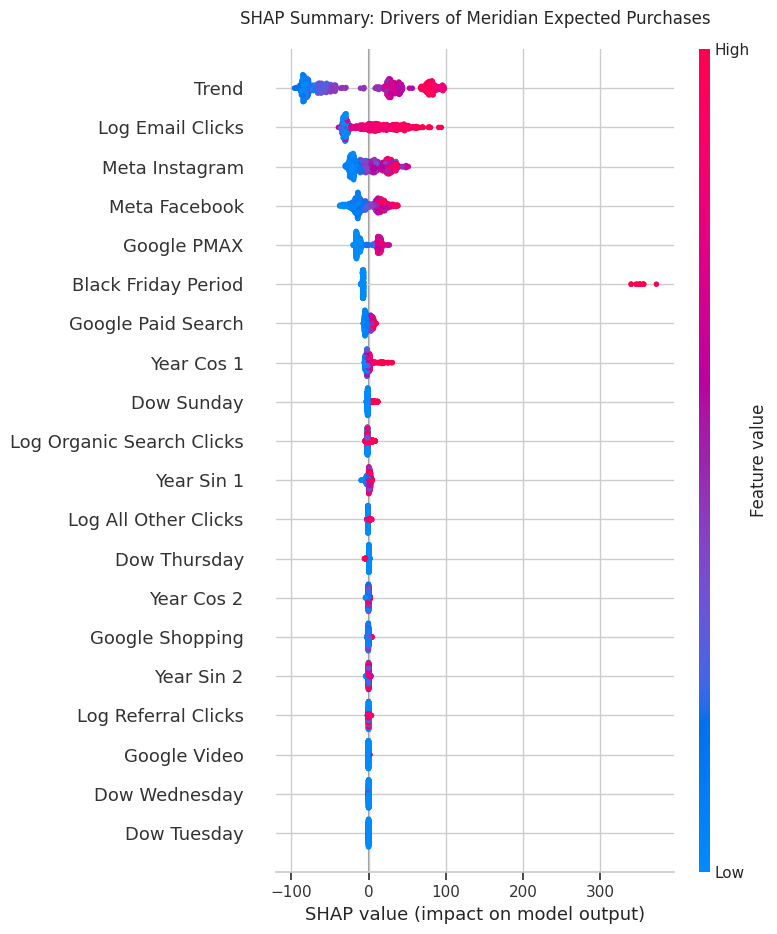

In [125]:
plt.figure(figsize=(12, 9))

shap.summary_plot(
    shap_explanation.values,
    X_shap_explain,
    max_display=20,
    show=False,
)

fig = plt.gcf()

plt.title(
    "SHAP Summary: Drivers of Meridian Expected Purchases",
    pad=18,
)

plt.tight_layout()

fig.savefig(
    CHART_DIR / "shap_summary_beeswarm.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [126]:
shap_importance = pd.DataFrame({
    "feature": X_shap_explain.columns,
    "mean_absolute_shap": np.abs(
        shap_explanation.values
    ).mean(axis=0),
    "mean_signed_shap": (
        shap_explanation.values
        .mean(axis=0)
    ),
    "positive_effect_share": (
        shap_explanation.values > 0
    ).mean(axis=0),
})

shap_importance["feature_group"] = np.where(
    shap_importance["feature"].isin(
        media_channel_names
    ),
    "Paid Media",
    "Control",
)

shap_importance["importance_percentage"] = (
    shap_importance["mean_absolute_shap"]
    / shap_importance["mean_absolute_shap"].sum()
    * 100
)

shap_importance = (
    shap_importance
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    shap_importance.head(20).round(4)
)

,feature,mean_absolute_shap,mean_signed_shap,positive_effect_share,feature_group,importance_percentage
0,Trend,60.6140,-6.6180,0.5175,Control,37.5360
1,Log Email Clicks,25.6096,3.4689,0.5425,Control,15.8591
2,Meta Instagram,17.7007,3.0013,0.5288,Paid Media,10.9614
3,Meta Facebook,14.6082,-0.7716,0.4388,Paid Media,9.0463
4,Google PMAX,13.7238,-1.0953,0.4575,Paid Media,8.4986
5,Black Friday Period,12.3473,-1.8094,0.0150,Control,7.6462
6,Google Paid Search,4.0153,-0.2221,0.4638,Paid Media,2.4865
7,Year Cos 1,2.8255,-0.0884,0.3800,Control,1.7498
8,Dow Sunday,2.1987,-0.2058,0.1462,Control,1.3616
9,Log Organic Search Clicks,2.0859,-0.0593,0.3588,Control,1.2917


In [127]:
shap_importance.to_csv(
    TABLE_DIR / "shap_feature_importance.csv",
    index=False,
)

print("SHAP importance ranking saved.")

SHAP importance ranking saved.


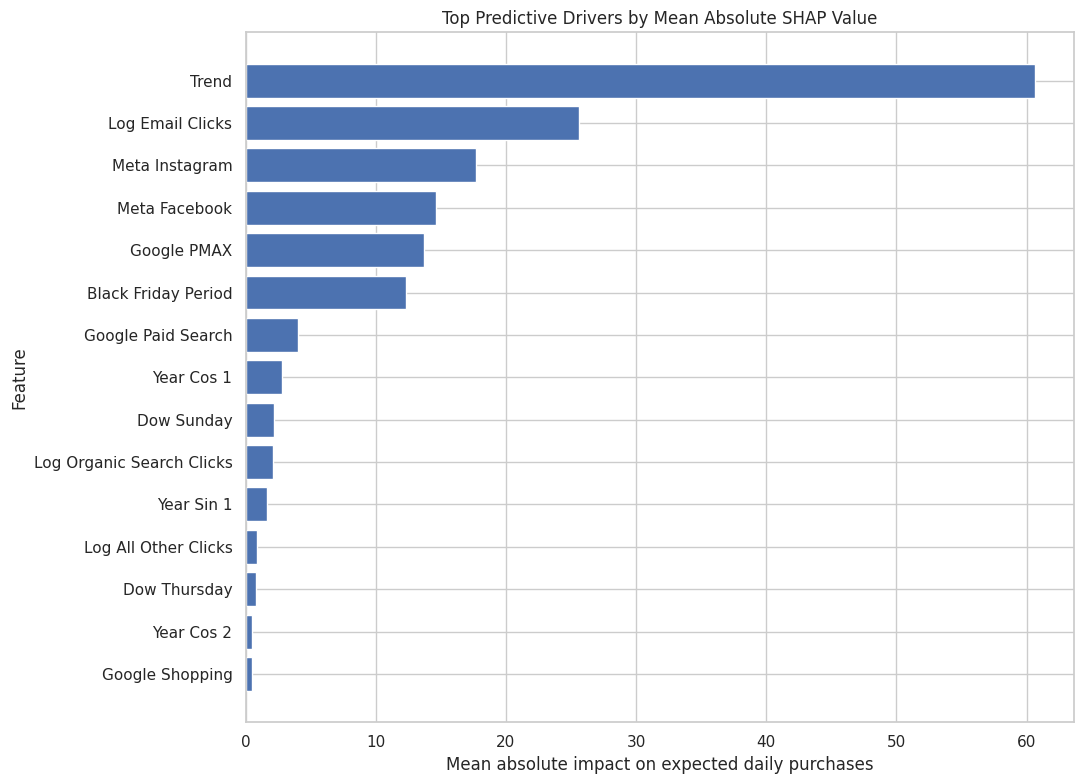

In [128]:
shap_importance_plot = (
    shap_importance
    .head(15)
    .sort_values(
        "mean_absolute_shap",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    shap_importance_plot["feature"],
    shap_importance_plot["mean_absolute_shap"],
)

ax.set_title(
    "Top Predictive Drivers by Mean Absolute SHAP Value"
)
ax.set_xlabel(
    "Mean absolute impact on expected daily purchases"
)
ax.set_ylabel("Feature")

plt.tight_layout()

fig.savefig(
    CHART_DIR / "shap_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### SHAP Global Explainability Results

Trend was the largest predictive driver of Meridian's expected purchases,
representing approximately 37.54% of total mean absolute SHAP importance. This
indicates that long-term changes in purchase demand played a major role during
the modeling period.

Email engagement was the second-largest predictive feature. Higher logged email
clicks generally increased expected purchases, suggesting that owned-channel
engagement closely tracks customer demand. Email was modeled as a control, so
this result should not be interpreted as paid-media incrementality.

Among paid-media variables, Meta Instagram had the highest SHAP importance,
followed by Meta Facebook and Google PMAX. Higher exposure on these channels
generally increased predicted purchases, although the dispersion of SHAP values
suggests nonlinear effects and diminishing sensitivity at higher exposure
levels.

The Black Friday indicator generated very large positive SHAP values on the
small number of event days. Its negative mean signed SHAP value is caused by
the many ordinary days where the indicator equals zero and does not imply that
Black Friday reduced purchases.

Google Shopping and Google Video had minimal predictive importance, consistent
with their relatively small Meridian contributions and weak ROI results.

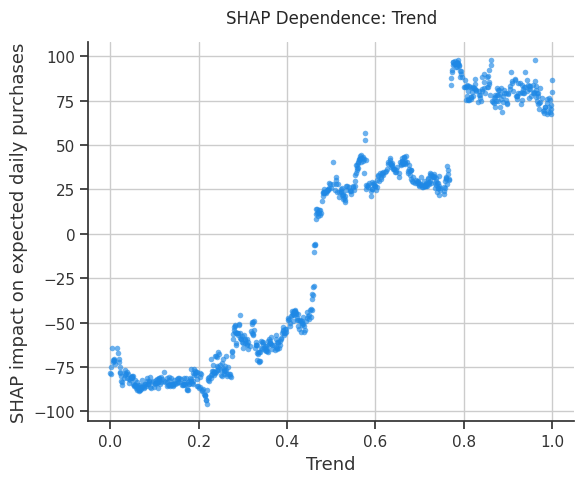

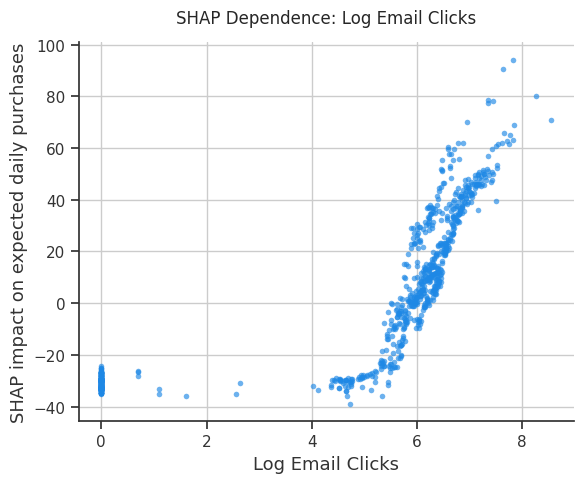

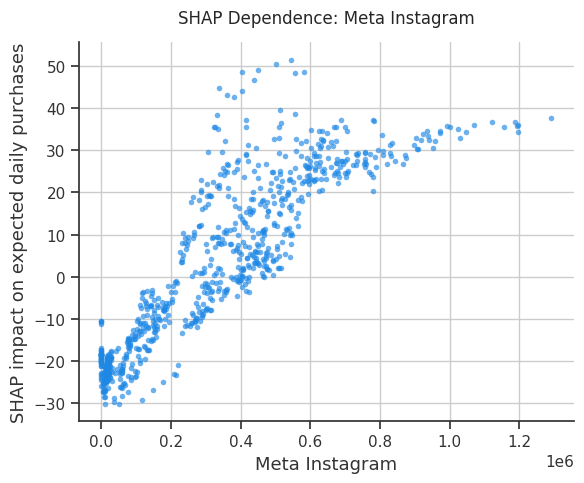

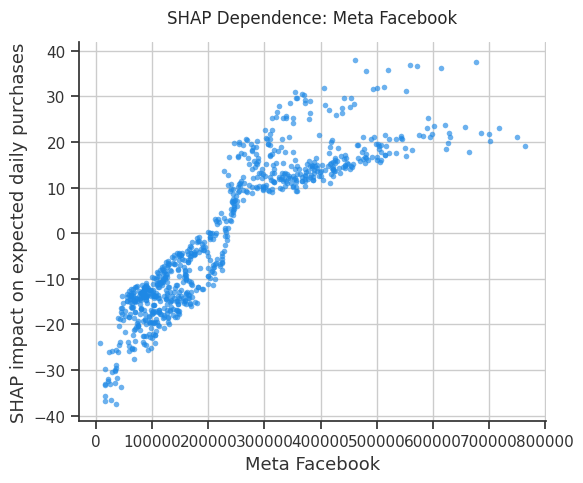

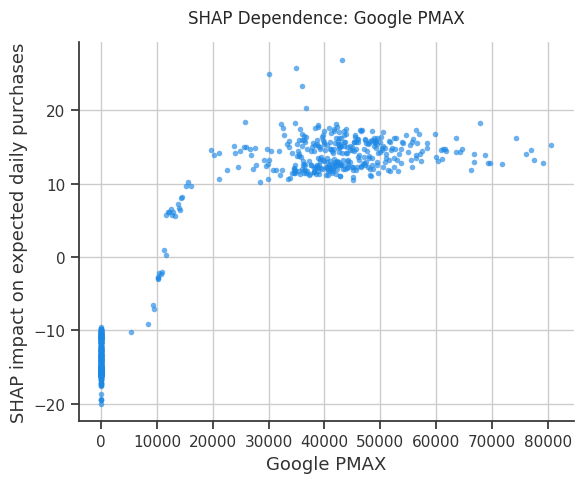

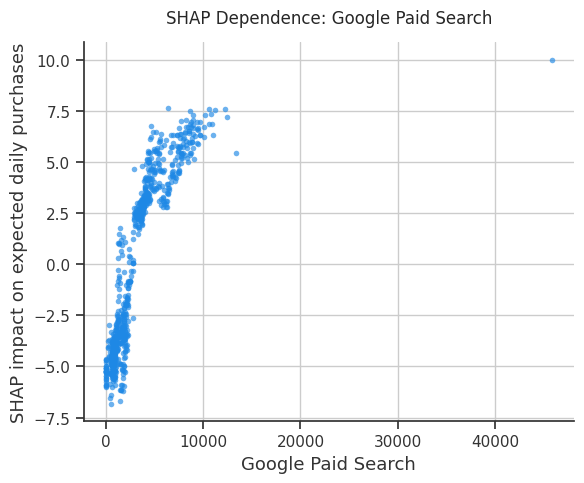

SHAP dependence plots saved.


In [129]:
dependence_features = [
    "Trend",
    "Log Email Clicks",
    "Meta Instagram",
    "Meta Facebook",
    "Google PMAX",
    "Google Paid Search",
]

for feature in dependence_features:
    shap.dependence_plot(
        feature,
        shap_explanation.values,
        X_shap_explain,
        interaction_index=None,
        show=False,
        alpha=0.65,
    )

    fig = plt.gcf()
    ax = plt.gca()

    ax.set_title(
        f"SHAP Dependence: {feature}",
        pad=14,
    )

    ax.set_ylabel(
        "SHAP impact on expected daily purchases"
    )

    plt.tight_layout()

    safe_filename = (
        feature.lower()
        .replace(" ", "_")
        .replace("/", "_")
    )

    fig.savefig(
        CHART_DIR
        / f"shap_dependence_{safe_filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

print("SHAP dependence plots saved.")

In [130]:
dependence_summary_rows = []

for feature in dependence_features:
    feature_position = list(
        X_shap_explain.columns
    ).index(feature)

    feature_analysis = pd.DataFrame({
        "feature_value": X_shap_explain[
            feature
        ].values,
        "shap_value": shap_explanation.values[
            :,
            feature_position,
        ],
    })

    unique_values = (
        feature_analysis["feature_value"]
        .nunique()
    )

    if unique_values >= 5:
        feature_analysis["value_bin"] = pd.qcut(
            feature_analysis["feature_value"],
            q=5,
            duplicates="drop",
        )
    else:
        feature_analysis["value_bin"] = (
            feature_analysis["feature_value"]
            .astype(str)
        )

    feature_summary = (
        feature_analysis
        .groupby(
            "value_bin",
            observed=True,
        )
        .agg(
            observations=("shap_value", "size"),
            minimum_feature_value=(
                "feature_value",
                "min",
            ),
            mean_feature_value=(
                "feature_value",
                "mean",
            ),
            maximum_feature_value=(
                "feature_value",
                "max",
            ),
            mean_shap_value=(
                "shap_value",
                "mean",
            ),
            mean_absolute_shap=(
                "shap_value",
                lambda values: np.abs(values).mean(),
            ),
        )
        .reset_index(drop=True)
    )

    feature_summary.insert(
        0,
        "feature",
        feature,
    )

    dependence_summary_rows.append(
        feature_summary
    )


shap_dependence_summary = pd.concat(
    dependence_summary_rows,
    ignore_index=True,
)

display(
    shap_dependence_summary.round(3)
)

,feature,observations,minimum_feature_value,mean_feature_value,maximum_feature_value,mean_shap_value,mean_absolute_shap
0,Trend,160,0.000,0.102,0.203,-82.051,82.051
1,Trend,160,0.204,0.296,0.387,-67.427,67.427
2,Trend,160,0.388,0.485,0.584,-2.515,34.689
3,Trend,160,0.585,0.692,0.787,38.750,38.750
4,Trend,160,0.787,0.893,1.000,80.153,80.153
5,Log Email Clicks,320,0.000,2.165,5.710,-26.824,26.848
6,Log Email Clicks,160,5.720,5.997,6.215,6.383,9.733
7,Log Email Clicks,160,6.217,6.383,6.596,19.755,19.765
8,Log Email Clicks,160,6.597,7.009,8.555,44.854,44.854
9,Meta Instagram,160,0.000,13428.075,54855.000,-21.614,21.614


In [131]:
shap_dependence_summary.to_csv(
    TABLE_DIR / "shap_dependence_summary.csv",
    index=False,
)

print("Dependence summary saved.")

Dependence summary saved.


In [132]:
media_shap_comparison = (
    shap_importance.loc[
        shap_importance["feature_group"]
        == "Paid Media",
        [
            "feature",
            "mean_absolute_shap",
        ],
    ]
    .rename(
        columns={
            "feature": "channel",
        }
    )
    .copy()
)

media_shap_comparison[
    "shap_share_within_paid_media_pct"
] = (
    media_shap_comparison[
        "mean_absolute_shap"
    ]
    / media_shap_comparison[
        "mean_absolute_shap"
    ].sum()
    * 100
)

mmm_paid_contribution = (
    channel_contribution_clean.loc[
        channel_contribution_clean["channel"]
        .str.lower()
        .ne("baseline"),
        [
            "channel",
            "contribution_percentage",
        ],
    ]
    .copy()
)

mmm_paid_contribution[
    "mmm_share_within_paid_media_pct"
] = (
    mmm_paid_contribution[
        "contribution_percentage"
    ]
    / mmm_paid_contribution[
        "contribution_percentage"
    ].sum()
    * 100
)

shap_vs_mmm = media_shap_comparison.merge(
    mmm_paid_contribution[
        [
            "channel",
            "mmm_share_within_paid_media_pct",
        ]
    ],
    on="channel",
    how="inner",
    validate="one_to_one",
)

shap_vs_mmm["shap_rank"] = (
    shap_vs_mmm[
        "shap_share_within_paid_media_pct"
    ]
    .rank(
        ascending=False,
        method="dense",
    )
    .astype(int)
)

shap_vs_mmm["mmm_contribution_rank"] = (
    shap_vs_mmm[
        "mmm_share_within_paid_media_pct"
    ]
    .rank(
        ascending=False,
        method="dense",
    )
    .astype(int)
)

shap_vs_mmm["share_difference_percentage_points"] = (
    shap_vs_mmm[
        "shap_share_within_paid_media_pct"
    ]
    - shap_vs_mmm[
        "mmm_share_within_paid_media_pct"
    ]
)

shap_vs_mmm = (
    shap_vs_mmm
    .sort_values("shap_rank")
    .reset_index(drop=True)
)

display(
    shap_vs_mmm.round(2)
)

,channel,mean_absolute_shap,shap_share_within_paid_media_pct,mmm_share_within_paid_media_pct,shap_rank,mmm_contribution_rank,share_difference_percentage_points
0,Meta Instagram,17.70,34.84,43.60,1,1,-8.75
1,Meta Facebook,14.61,28.76,33.48,2,2,-4.72
2,Google PMAX,13.72,27.02,1.63,3,4,25.38
3,Google Paid Search,4.02,7.90,20.45,4,3,-12.54
4,Google Shopping,0.48,0.94,0.39,5,6,0.55
5,Google Video,0.28,0.55,0.46,6,5,0.09


In [133]:
shap_vs_mmm.to_csv(
    TABLE_DIR / "shap_vs_meridian_contribution.csv",
    index=False,
)

print("SHAP versus MMM comparison saved.")

SHAP versus MMM comparison saved.


### Task 5 Summary

A Random Forest surrogate model was trained to reproduce Meridian's posterior
expected-purchase predictions. The surrogate achieved strong holdout fidelity,
with an R² of approximately 0.974 and a correlation of 0.988, making it suitable
for SHAP-based explanation.

Trend was the strongest global predictive driver, followed by email engagement.
Among paid-media features, Meta Instagram, Meta Facebook, and Google PMAX had
the greatest SHAP importance.

The SHAP and Meridian results serve different purposes. SHAP describes which
features are most influential for prediction, while Meridian estimates
incremental media contribution and financial return.

For example, Google PMAX had relatively high predictive SHAP importance but a
small incremental Meridian contribution and weak marginal ROI. Conversely,
Google Paid Search had lower SHAP importance but exceptionally strong
incremental ROI. This demonstrates why predictive association should not be
treated as causal marketing effectiveness.

The dependence plots also showed nonlinear relationships, indicating that
additional media exposure does not produce proportional increases in expected
purchases at every spending level.

## Task 6: Marketing Investment Scenario Simulation

Future budget scenarios are evaluated using Meridian's posterior response curves
and budget-optimization utilities.

The scenarios compare equal allocation, marginal-ROI-based allocation, and
saturation-aware reallocation. Results are evaluated using incremental
purchases, incremental revenue, and expected ROI.

In [134]:
from meridian.analysis import optimizer
import inspect

budget_optimizer = optimizer.BudgetOptimizer(
    mmm_final
)

print("BudgetOptimizer created successfully.")

print("\noptimize() signature:")
print(
    inspect.signature(
        budget_optimizer.optimize
    )
)

BudgetOptimizer created successfully.

optimize() signature:
(new_data: meridian.analysis.tensors.DataTensors | None = None, use_posterior: bool = True, selected_geos: collections.abc.Sequence[str] | None = None, selected_times: tuple[str | None, str | None] | None = None, start_date: str | datetime.datetime | datetime.date | numpy.datetime64 | None = None, end_date: str | datetime.datetime | datetime.date | numpy.datetime64 | None = None, fixed_budget: bool = True, budget: float | None = None, pct_of_spend: collections.abc.Sequence[float] | None = None, spend_constraint_lower: float | collections.abc.Sequence[float] | None = None, spend_constraint_upper: float | collections.abc.Sequence[float] | None = None, target_roi: float | None = None, target_mroi: float | None = None, gtol: float = 0.0001, use_optimal_frequency: bool = True, max_frequency: float | None = None, use_kpi: bool = False, confidence_level: float = 0.9, batch_size: int = 100, optimization_grid: meridian.analysis.optimi

In [135]:
optimizer_methods = [
    method_name
    for method_name in dir(budget_optimizer)
    if not method_name.startswith("_")
]

print("Public BudgetOptimizer methods:")

for method_name in optimizer_methods:
    attribute = getattr(
        budget_optimizer,
        method_name,
    )

    if callable(attribute):
        try:
            method_signature = inspect.signature(
                attribute
            )
        except (TypeError, ValueError):
            method_signature = "Signature unavailable"

        print(
            f"- {method_name}{method_signature}"
        )

Public BudgetOptimizer methods:
- create_optimization_grid(new_data: xarray.core.dataset.Dataset | None = None, use_posterior: bool = True, selected_geos: collections.abc.Sequence[str] | None = None, selected_times: tuple[str | None, str | None] | None = None, start_date: str | datetime.datetime | datetime.date | numpy.datetime64 | None = None, end_date: str | datetime.datetime | datetime.date | numpy.datetime64 | None = None, budget: float | None = None, pct_of_spend: collections.abc.Sequence[float] | None = None, spend_constraint_lower: float | collections.abc.Sequence[float] = 1.0, spend_constraint_upper: float | collections.abc.Sequence[float] = 1.0, gtol: float = 0.0001, use_optimal_frequency: bool = True, max_frequency: float | None = None, use_kpi: bool = False, batch_size: int = 100) -> meridian.analysis.optimizer.OptimizationGrid
- create_optimization_tensors(time: collections.abc.Sequence[str] | tensorflow.python.framework.tensor.Tensor, cpmu: tensorflow.python.framework.tens

In [136]:
print(
    "Input-data type:",
    type(mmm_final.input_data),
)

print(
    "Has paid-channel argument builder:",
    hasattr(
        mmm_final.input_data,
        "get_paid_channels_argument_builder",
    ),
)

if hasattr(
    mmm_final.input_data,
    "get_paid_channels_argument_builder",
):
    paid_channel_argument_builder = (
        mmm_final.input_data
        .get_paid_channels_argument_builder()
    )

    print(
        "Builder type:",
        type(paid_channel_argument_builder),
    )

    print(
        "Builder call signature:",
        inspect.signature(
            paid_channel_argument_builder
        ),
    )

Input-data type: <class 'meridian.data.input_data.InputData'>
Has paid-channel argument builder: True
Builder type: <class 'meridian.data.arg_builder.OrderedListArgumentBuilder'>
Builder call signature: (**kwargs) -> list[~T]


In [137]:
optimizer_channel_order = list(
    mmm_final.input_data.get_all_paid_channels()
)

print("Optimizer channel order:")

for index, channel in enumerate(
    optimizer_channel_order,
    start=1,
):
    print(
        f"{index}. {channel}"
    )

Optimizer channel order:
1. Google Paid Search
2. Google Shopping
3. Google PMAX
4. Google Video
5. Meta Facebook
6. Meta Instagram


In [138]:
# Historical spend mapped by channel.
historical_spend_map = (
    roi_mroi_clean
    .set_index("channel")["spend"]
    .to_dict()
)

# Reorder precisely according to Meridian's optimizer.
historical_spend_vector = np.array(
    [
        historical_spend_map[channel]
        for channel in optimizer_channel_order
    ],
    dtype=float,
)

historical_total_budget = (
    historical_spend_vector.sum()
)

historical_allocation = (
    historical_spend_vector
    / historical_total_budget
)

historical_budget_table = pd.DataFrame({
    "channel": optimizer_channel_order,
    "historical_spend": historical_spend_vector,
    "historical_allocation_pct": (
        historical_allocation * 100
    ),
})

display(
    historical_budget_table.round(2)
)

print(
    "Historical total budget:",
    f"${historical_total_budget:,.2f}",
)

,channel,historical_spend,historical_allocation_pct
0,Google Paid Search,439708.94,4.86
1,Google Shopping,74550.50,0.82
2,Google PMAX,345905.47,3.82
3,Google Video,124154.70,1.37
4,Meta Facebook,3540414.25,39.11
5,Meta Instagram,4527420.50,50.01


Historical total budget: $9,052,154.35


In [139]:
ADDITIONAL_BUDGET_PERCENTAGE = 0.20

equal_additional_budget = (
    historical_total_budget
    * ADDITIONAL_BUDGET_PERCENTAGE
)

equal_increment_per_channel = (
    equal_additional_budget
    / len(optimizer_channel_order)
)

equal_20_spend_vector = (
    historical_spend_vector
    + equal_increment_per_channel
)

equal_20_total_budget = (
    equal_20_spend_vector.sum()
)

equal_20_allocation = (
    equal_20_spend_vector
    / equal_20_total_budget
)

equal_20_plan = pd.DataFrame({
    "channel": optimizer_channel_order,
    "historical_spend": historical_spend_vector,
    "additional_spend": equal_increment_per_channel,
    "scenario_spend": equal_20_spend_vector,
    "scenario_allocation_pct": (
        equal_20_allocation * 100
    ),
})

display(
    equal_20_plan.round(2)
)

print(
    "Additional budget:",
    f"${equal_additional_budget:,.2f}",
)

print(
    "Additional amount per channel:",
    f"${equal_increment_per_channel:,.2f}",
)

print(
    "New total budget:",
    f"${equal_20_total_budget:,.2f}",
)

print(
    "Allocation sum:",
    equal_20_allocation.sum(),
)

,channel,historical_spend,additional_spend,scenario_spend,scenario_allocation_pct
0,Google Paid Search,439708.94,301738.48,741447.42,6.83
1,Google Shopping,74550.50,301738.48,376288.98,3.46
2,Google PMAX,345905.47,301738.48,647643.95,5.96
3,Google Video,124154.70,301738.48,425893.17,3.92
4,Meta Facebook,3540414.25,301738.48,3842152.73,35.37
5,Meta Instagram,4527420.50,301738.48,4829158.98,44.46


Additional budget: $1,810,430.87
Additional amount per channel: $301,738.48
New total budget: $10,862,585.22
Allocation sum: 0.9999999999999999


In [140]:
assert np.isclose(
    equal_20_allocation.sum(),
    1.0,
), "Scenario allocations must sum to 1."

assert np.all(
    equal_20_spend_vector
    >= historical_spend_vector
), "No channel should lose spend in this scenario."

assert np.isclose(
    equal_20_total_budget,
    historical_total_budget * 1.20,
), "Scenario budget should be exactly 20% above historical spend."

print("Scenario allocation validated successfully.")

Scenario allocation validated successfully.


In [141]:
equal_20_results = budget_optimizer.optimize(
    fixed_budget=True,
    budget=float(equal_20_total_budget),
    pct_of_spend=equal_20_allocation,
    spend_constraint_lower=0.0,
    spend_constraint_upper=0.0,
    use_posterior=True,
    use_kpi=False,
    confidence_level=0.90,
)

print(
    "Equal-allocation +20% scenario completed."
)

Equal-allocation +20% scenario completed.


In [142]:
print(
    "Result type:",
    type(equal_20_results),
)

print(
    "\nNon-optimized data type:",
    type(equal_20_results.nonoptimized_data),
)

print(
    "\nOptimized data type:",
    type(equal_20_results.optimized_data),
)

print("\nNon-optimized scenario data:")
display(
    equal_20_results.nonoptimized_data
)

print("\nOptimized scenario data:")
display(
    equal_20_results.optimized_data
)

Result type: <class 'meridian.analysis.optimizer.OptimizationResults'>

Non-optimized data type: <class 'xarray.core.dataset.Dataset'>

Optimized data type: <class 'xarray.core.dataset.Dataset'>

Non-optimized scenario data:


<xarray.Dataset> Size: 1kB
Dimensions:              (channel: 6, metric: 4)
Coordinates:
  * channel              (channel) object 48B 'Google Paid Search' ... 'Meta ...
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 48B 7.4e+05 3.8e+05 ... 4.83e+06
    pct_of_spend         (channel) float64 48B 0.06808 0.03496 ... 0.3533 0.4443
    incremental_outcome  (channel, metric) float64 192B 6.327e+06 ... 1.323e+07
    effectiveness        (channel, metric) float64 192B 0.9072 ... 0.02906
    roi                  (channel, metric) float64 192B 8.55 8.507 ... 2.739
    mroi                 (channel, metric) float64 192B 3.25 3.257 ... 1.535
    cpik                 (channel, metric) float64 192B 0.1317 0.1176 ... 0.5488
Attributes:
    start_date:                 2020-11-21
    end_date:                   2024-05-19
    budget:                     1.087e+07
    profit:                     1.614411e+07
    total_incremental_outcome:  2.701411e+07
    total_roi:                  2.4851987
    total_cpik:                 0.4057929217815399
    is_revenue_kpi:             True
    confidence_level:           0.9
    use_historical_budget:      False


Optimized scenario data:


<xarray.Dataset> Size: 1kB
Dimensions:              (channel: 6, metric: 4)
Coordinates:
  * channel              (channel) object 48B 'Google Paid Search' ... 'Meta ...
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
Data variables:
    spend                (channel) float64 48B 7.4e+05 3.8e+05 ... 4.83e+06
    pct_of_spend         (channel) float64 48B 0.06808 0.03496 ... 0.3533 0.4443
    incremental_outcome  (channel, metric) float64 192B 6.327e+06 ... 1.323e+07
    effectiveness        (channel, metric) float64 192B 0.9072 ... 0.02906
    roi                  (channel, metric) float64 192B 8.55 8.507 ... 2.739
    mroi                 (channel, metric) float64 192B 3.25 3.257 ... 1.535
    cpik                 (channel, metric) float64 192B 0.1317 0.1176 ... 0.5488
Attributes:
    start_date:                 2020-11-21
    end_date:                   2024-05-19
    budget:                     1.087e+07
    profit:                     1.614411e+07
    total_incremental_outcome:  2.701411e+07
    total_roi:                  2.4851987
    total_cpik:                 0.4057929217815399
    is_revenue_kpi:             True
    confidence_level:           0.9
    use_historical_budget:      False
    fixed_budget:               True

In [143]:
print("Optimization result fields and methods:")

for name in dir(equal_20_results):
    if not name.startswith("_"):
        print("-", name)

Optimization result fields and methods:
- analyzer
- get_response_curves
- meridian
- new_data
- nonoptimized_data
- nonoptimized_data_with_optimal_freq
- optimization_grid
- optimized_data
- output_optimization_summary
- plot_budget_allocation
- plot_incremental_outcome_delta
- plot_response_curves
- plot_spend_delta
- spend_bounds
- spend_ratio
- template_env


In [144]:
same_spend = np.allclose(
    equal_20_results.nonoptimized_data["spend"].values,
    equal_20_results.optimized_data["spend"].values,
)

same_revenue = np.allclose(
    equal_20_results.nonoptimized_data[
        "incremental_outcome"
    ].values,
    equal_20_results.optimized_data[
        "incremental_outcome"
    ].values,
)

print("Same spend allocation:", same_spend)
print("Same incremental revenue:", same_revenue)

print("\nScenario attributes:")
for key, value in equal_20_results.optimized_data.attrs.items():
    print(f"{key}: {value}")

Same spend allocation: True
Same incremental revenue: True

Scenario attributes:
start_date: 2020-11-21
end_date: 2024-05-19
budget: 10870000.0
profit: 16144110.0
total_incremental_outcome: 27014110.0
total_roi: 2.485198736190796
total_cpik: 0.4057929217815399
is_revenue_kpi: True
confidence_level: 0.9
use_historical_budget: False
fixed_budget: True


In [145]:
equal_20_kpi_results = budget_optimizer.optimize(
    fixed_budget=True,
    budget=float(
        equal_20_results.optimized_data.attrs["budget"]
    ),
    pct_of_spend=(
        equal_20_results
        .optimized_data["pct_of_spend"]
        .values
    ),
    spend_constraint_lower=0.0,
    spend_constraint_upper=0.0,
    use_posterior=True,
    use_kpi=True,
    confidence_level=0.90,
)

print("Purchase scenario completed.\n")

for key, value in (
    equal_20_kpi_results
    .optimized_data
    .attrs
    .items()
):
    print(f"{key}: {value}")

Purchase scenario completed.

start_date: 2020-11-21
end_date: 2024-05-19
budget: 10870000.0
profit: -10546883.0
total_incremental_outcome: 323116.875
total_roi: 0.029725562781095505
total_cpik: 33.92506408691406
is_revenue_kpi: False
confidence_level: 0.9
use_historical_budget: False
fixed_budget: True


In [146]:
# Historical revenue results
historical_budget = float(
    paid_summary_metrics["spend"]
    .sel(channel="All Channels")
    .item()
)

historical_incremental_revenue = float(
    paid_summary_metrics["incremental_outcome"]
    .sel(
        channel="All Channels",
        metric="mean",
        distribution="posterior",
    )
    .item()
)

# Historical purchase results
historical_kpi_metrics = (
    media_summary_kpi
    .get_paid_summary_metrics(
        aggregate_times=True
    )
)

historical_incremental_purchases = float(
    historical_kpi_metrics["incremental_outcome"]
    .sel(
        channel="All Channels",
        metric="mean",
        distribution="posterior",
    )
    .item()
)

# Scenario results
scenario_budget = float(
    equal_20_results
    .optimized_data
    .attrs["budget"]
)

scenario_incremental_revenue = float(
    equal_20_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_incremental_purchases = float(
    equal_20_kpi_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

additional_spend = (
    scenario_budget
    - historical_budget
)

revenue_uplift = (
    scenario_incremental_revenue
    - historical_incremental_revenue
)

purchase_uplift = (
    scenario_incremental_purchases
    - historical_incremental_purchases
)

incremental_roi = (
    revenue_uplift
    / additional_spend
)

scenario_1_summary = pd.DataFrame([{
    "Scenario": "+20% Budget, Equal Increment Allocation",
    "Historical Budget": historical_budget,
    "Scenario Budget": scenario_budget,
    "Additional Spend": additional_spend,
    "Historical Incremental Revenue":
        historical_incremental_revenue,
    "Scenario Incremental Revenue":
        scenario_incremental_revenue,
    "Incremental Revenue Uplift":
        revenue_uplift,
    "Historical Incremental Purchases":
        historical_incremental_purchases,
    "Scenario Incremental Purchases":
        scenario_incremental_purchases,
    "Incremental Purchase Uplift":
        purchase_uplift,
    "Scenario Total ROI": float(
        equal_20_results
        .optimized_data
        .attrs["total_roi"]
    ),
    "ROI on Additional Spend":
        incremental_roi,
}])

display(
    scenario_1_summary.T
)

scenario_1_summary.to_csv(
    TABLE_DIR / "scenario_01_equal_allocation.csv",
    index=False,
)

print("Scenario 1 saved successfully.")

,0
Scenario,"+20% Budget, Equal Increment Allocation"
Historical Budget,9052154.0
Scenario Budget,10870000.0
Additional Spend,1817846.0
Historical Incremental Revenue,24742968.0
Scenario Incremental Revenue,27014110.0
Incremental Revenue Uplift,2271142.0
Historical Incremental Purchases,296098.8125
Scenario Incremental Purchases,323116.875
Incremental Purchase Uplift,27018.0625


Scenario 1 saved successfully.


In [147]:
# Scenario 2:
# Increase the highest-mROI channel by 50%.
# Keep all other channel spending unchanged.

highest_mroi_channel = (
    roi_mroi_clean
    .sort_values("mroi", ascending=False)
    .iloc[0]["channel"]
)

highest_mroi_position = (
    optimizer_channel_order.index(
        highest_mroi_channel
    )
)

scenario_2_spend_vector = (
    historical_spend_vector.copy()
)

scenario_2_spend_vector[
    highest_mroi_position
] *= 1.50

scenario_2_budget = float(
    scenario_2_spend_vector.sum()
)

scenario_2_allocation = (
    scenario_2_spend_vector
    / scenario_2_budget
)

print(
    "Highest-mROI channel:",
    highest_mroi_channel,
)

print(
    "Scenario budget:",
    f"${scenario_2_budget:,.2f}",
)

# Revenue version
scenario_2_revenue_results = (
    budget_optimizer.optimize(
        fixed_budget=True,
        budget=scenario_2_budget,
        pct_of_spend=scenario_2_allocation,
        spend_constraint_lower=0.0,
        spend_constraint_upper=0.0,
        use_posterior=True,
        use_kpi=False,
        confidence_level=0.90,
    )
)

# Purchase version
scenario_2_kpi_results = (
    budget_optimizer.optimize(
        fixed_budget=True,
        budget=scenario_2_budget,
        pct_of_spend=scenario_2_allocation,
        spend_constraint_lower=0.0,
        spend_constraint_upper=0.0,
        use_posterior=True,
        use_kpi=True,
        confidence_level=0.90,
    )
)

scenario_2_revenue = float(
    scenario_2_revenue_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_2_purchases = float(
    scenario_2_kpi_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_2_additional_spend = (
    scenario_2_budget
    - historical_budget
)

scenario_2_revenue_uplift = (
    scenario_2_revenue
    - historical_incremental_revenue
)

scenario_2_purchase_uplift = (
    scenario_2_purchases
    - historical_incremental_purchases
)

scenario_2_summary = pd.DataFrame([{
    "Scenario":
        "+50% Spend on Highest-mROI Channel",

    "Selected Channel":
        highest_mroi_channel,

    "Historical Budget":
        historical_budget,

    "Scenario Budget":
        scenario_2_budget,

    "Additional Spend":
        scenario_2_additional_spend,

    "Historical Incremental Revenue":
        historical_incremental_revenue,

    "Scenario Incremental Revenue":
        scenario_2_revenue,

    "Incremental Revenue Uplift":
        scenario_2_revenue_uplift,

    "Historical Incremental Purchases":
        historical_incremental_purchases,

    "Scenario Incremental Purchases":
        scenario_2_purchases,

    "Incremental Purchase Uplift":
        scenario_2_purchase_uplift,

    "Scenario Total ROI": float(
        scenario_2_revenue_results
        .optimized_data
        .attrs["total_roi"]
    ),

    "ROI on Additional Spend": (
        scenario_2_revenue_uplift
        / scenario_2_additional_spend
    ),
}])

display(scenario_2_summary.T)

scenario_2_summary.to_csv(
    TABLE_DIR
    / "scenario_02_highest_mroi_channel.csv",
    index=False,
)

print("Scenario 2 saved successfully.")

Highest-mROI channel: Google Paid Search
Scenario budget: $9,272,008.82


,0
Scenario,+50% Spend on Highest-mROI Channel
Selected Channel,Google Paid Search
Historical Budget,9052154.0
Scenario Budget,9272008.820312
Additional Spend,219854.820312
Historical Incremental Revenue,24742968.0
Scenario Incremental Revenue,25723366.0
Incremental Revenue Uplift,980398.0
Historical Incremental Purchases,296098.8125
Scenario Incremental Purchases,307707.125


Scenario 2 saved successfully.


In [148]:
# Scenario 3:
# Reduce spending on the two most saturated channels by 30%.

saturated_channels = [
    "Google PMAX",
    "Google Shopping",
]

scenario_3_spend_vector = (
    historical_spend_vector.copy()
)

for channel in saturated_channels:
    channel_position = (
        optimizer_channel_order.index(channel)
    )

    scenario_3_spend_vector[
        channel_position
    ] *= 0.70


scenario_3_budget = float(
    scenario_3_spend_vector.sum()
)

scenario_3_allocation = (
    scenario_3_spend_vector
    / scenario_3_budget
)

print(
    "Reduced channels:",
    ", ".join(saturated_channels),
)

print(
    "Scenario budget:",
    f"${scenario_3_budget:,.2f}",
)


# Revenue version
scenario_3_revenue_results = (
    budget_optimizer.optimize(
        fixed_budget=True,
        budget=scenario_3_budget,
        pct_of_spend=scenario_3_allocation,
        spend_constraint_lower=0.0,
        spend_constraint_upper=0.0,
        use_posterior=True,
        use_kpi=False,
        confidence_level=0.90,
    )
)


# Purchase version
scenario_3_kpi_results = (
    budget_optimizer.optimize(
        fixed_budget=True,
        budget=scenario_3_budget,
        pct_of_spend=scenario_3_allocation,
        spend_constraint_lower=0.0,
        spend_constraint_upper=0.0,
        use_posterior=True,
        use_kpi=True,
        confidence_level=0.90,
    )
)


scenario_3_revenue = float(
    scenario_3_revenue_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_3_purchases = float(
    scenario_3_kpi_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_3_spend_savings = (
    historical_budget
    - scenario_3_budget
)

scenario_3_revenue_change = (
    scenario_3_revenue
    - historical_incremental_revenue
)

scenario_3_purchase_change = (
    scenario_3_purchases
    - historical_incremental_purchases
)

scenario_3_revenue_lost_per_dollar_saved = (
    -scenario_3_revenue_change
    / scenario_3_spend_savings
)

scenario_3_net_profit_change = (
    scenario_3_spend_savings
    + scenario_3_revenue_change
)


scenario_3_summary = pd.DataFrame([{
    "Scenario":
        "-30% Spend on Saturated Channels",

    "Reduced Channels":
        ", ".join(saturated_channels),

    "Historical Budget":
        historical_budget,

    "Scenario Budget":
        scenario_3_budget,

    "Spend Savings":
        scenario_3_spend_savings,

    "Historical Incremental Revenue":
        historical_incremental_revenue,

    "Scenario Incremental Revenue":
        scenario_3_revenue,

    "Incremental Revenue Change":
        scenario_3_revenue_change,

    "Historical Incremental Purchases":
        historical_incremental_purchases,

    "Scenario Incremental Purchases":
        scenario_3_purchases,

    "Incremental Purchase Change":
        scenario_3_purchase_change,

    "Scenario Total ROI": float(
        scenario_3_revenue_results
        .optimized_data
        .attrs["total_roi"]
    ),

    "Revenue Lost per $1 Saved":
        scenario_3_revenue_lost_per_dollar_saved,

    "Estimated Profit Change":
        scenario_3_net_profit_change,
}])

display(scenario_3_summary.T)

scenario_3_summary.to_csv(
    TABLE_DIR
    / "scenario_03_reduce_saturated_channels.csv",
    index=False,
)

print("Scenario 3 saved successfully.")

Reduced channels: Google PMAX, Google Shopping
Scenario budget: $8,926,017.56


,0
Scenario,-30% Spend on Saturated Channels
Reduced Channels,"Google PMAX, Google Shopping"
Historical Budget,9052154.0
Scenario Budget,8926017.560937
Spend Savings,126136.439063
Historical Incremental Revenue,24742968.0
Scenario Incremental Revenue,24676152.0
Incremental Revenue Change,-66816.0
Historical Incremental Purchases,296098.8125
Scenario Incremental Purchases,295279.375


Scenario 3 saved successfully.


In [149]:
# Scenario 4:
# Randomly select half of the channels and increase their spend by 10%.

random_generator = np.random.default_rng(42)

random_selected_channels = (
    random_generator.choice(
        optimizer_channel_order,
        size=len(optimizer_channel_order) // 2,
        replace=False,
    )
    .tolist()
)

scenario_4_spend_vector = (
    historical_spend_vector.copy()
)

for channel in random_selected_channels:
    channel_position = (
        optimizer_channel_order.index(channel)
    )

    scenario_4_spend_vector[
        channel_position
    ] *= 1.10


scenario_4_budget = float(
    scenario_4_spend_vector.sum()
)

scenario_4_allocation = (
    scenario_4_spend_vector
    / scenario_4_budget
)

print(
    "Randomly selected channels:",
    ", ".join(random_selected_channels),
)

print(
    "Scenario budget:",
    f"${scenario_4_budget:,.2f}",
)


# Revenue version
scenario_4_revenue_results = (
    budget_optimizer.optimize(
        fixed_budget=True,
        budget=scenario_4_budget,
        pct_of_spend=scenario_4_allocation,
        spend_constraint_lower=0.0,
        spend_constraint_upper=0.0,
        use_posterior=True,
        use_kpi=False,
        confidence_level=0.90,
    )
)


# Purchase version
scenario_4_kpi_results = (
    budget_optimizer.optimize(
        fixed_budget=True,
        budget=scenario_4_budget,
        pct_of_spend=scenario_4_allocation,
        spend_constraint_lower=0.0,
        spend_constraint_upper=0.0,
        use_posterior=True,
        use_kpi=True,
        confidence_level=0.90,
    )
)


scenario_4_revenue = float(
    scenario_4_revenue_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_4_purchases = float(
    scenario_4_kpi_results
    .optimized_data
    .attrs["total_incremental_outcome"]
)

scenario_4_additional_spend = (
    scenario_4_budget
    - historical_budget
)

scenario_4_revenue_uplift = (
    scenario_4_revenue
    - historical_incremental_revenue
)

scenario_4_purchase_uplift = (
    scenario_4_purchases
    - historical_incremental_purchases
)


scenario_4_summary = pd.DataFrame([{
    "Scenario":
        "+10% Spend on Random Half of Channels",

    "Selected Channels":
        ", ".join(random_selected_channels),

    "Historical Budget":
        historical_budget,

    "Scenario Budget":
        scenario_4_budget,

    "Additional Spend":
        scenario_4_additional_spend,

    "Historical Incremental Revenue":
        historical_incremental_revenue,

    "Scenario Incremental Revenue":
        scenario_4_revenue,

    "Incremental Revenue Uplift":
        scenario_4_revenue_uplift,

    "Historical Incremental Purchases":
        historical_incremental_purchases,

    "Scenario Incremental Purchases":
        scenario_4_purchases,

    "Incremental Purchase Uplift":
        scenario_4_purchase_uplift,

    "Scenario Total ROI": float(
        scenario_4_revenue_results
        .optimized_data
        .attrs["total_roi"]
    ),

    "ROI on Additional Spend": (
        scenario_4_revenue_uplift
        / scenario_4_additional_spend
    ),
}])

display(scenario_4_summary.T)

scenario_4_summary.to_csv(
    TABLE_DIR
    / "scenario_04_random_half_channels.csv",
    index=False,
)

print("Scenario 4 saved successfully.")

Randomly selected channels: Meta Instagram, Google Paid Search, Google Video
Scenario budget: $9,561,282.76


,0
Scenario,+10% Spend on Random Half of Channels
Selected Channels,"Meta Instagram, Google Paid Search, Google Video"
Historical Budget,9052154.0
Scenario Budget,9561282.764844
Additional Spend,509128.764844
Historical Incremental Revenue,24742968.0
Scenario Incremental Revenue,25558212.0
Incremental Revenue Uplift,815244.0
Historical Incremental Purchases,296098.8125
Scenario Incremental Purchases,305959.8125


Scenario 4 saved successfully.


In [150]:
scenario_comparison = pd.DataFrame([
    {
        "Scenario": "Equal +20% Budget",
        "Scenario Budget": scenario_1_summary.loc[
            0, "Scenario Budget"
        ],
        "Budget Change": scenario_1_summary.loc[
            0, "Additional Spend"
        ],
        "Revenue Change": scenario_1_summary.loc[
            0, "Incremental Revenue Uplift"
        ],
        "Purchase Change": scenario_1_summary.loc[
            0, "Incremental Purchase Uplift"
        ],
        "Scenario Total ROI": scenario_1_summary.loc[
            0, "Scenario Total ROI"
        ],
        "Incremental ROI": scenario_1_summary.loc[
            0, "ROI on Additional Spend"
        ],
    },
    {
        "Scenario": "Paid Search +50%",
        "Scenario Budget": scenario_2_summary.loc[
            0, "Scenario Budget"
        ],
        "Budget Change": scenario_2_summary.loc[
            0, "Additional Spend"
        ],
        "Revenue Change": scenario_2_summary.loc[
            0, "Incremental Revenue Uplift"
        ],
        "Purchase Change": scenario_2_summary.loc[
            0, "Incremental Purchase Uplift"
        ],
        "Scenario Total ROI": scenario_2_summary.loc[
            0, "Scenario Total ROI"
        ],
        "Incremental ROI": scenario_2_summary.loc[
            0, "ROI on Additional Spend"
        ],
    },
    {
        "Scenario": "Cut PMAX and Shopping 30%",
        "Scenario Budget": scenario_3_summary.loc[
            0, "Scenario Budget"
        ],
        "Budget Change": (
            scenario_3_summary.loc[0, "Scenario Budget"]
            - scenario_3_summary.loc[0, "Historical Budget"]
        ),
        "Revenue Change": scenario_3_summary.loc[
            0, "Incremental Revenue Change"
        ],
        "Purchase Change": scenario_3_summary.loc[
            0, "Incremental Purchase Change"
        ],
        "Scenario Total ROI": scenario_3_summary.loc[
            0, "Scenario Total ROI"
        ],
        "Incremental ROI": (
            scenario_3_summary.loc[
                0, "Incremental Revenue Change"
            ]
            / (
                scenario_3_summary.loc[
                    0, "Scenario Budget"
                ]
                - scenario_3_summary.loc[
                    0, "Historical Budget"
                ]
            )
        ),
    },
    {
        "Scenario": "Random Half +10%",
        "Scenario Budget": scenario_4_summary.loc[
            0, "Scenario Budget"
        ],
        "Budget Change": scenario_4_summary.loc[
            0, "Additional Spend"
        ],
        "Revenue Change": scenario_4_summary.loc[
            0, "Incremental Revenue Uplift"
        ],
        "Purchase Change": scenario_4_summary.loc[
            0, "Incremental Purchase Uplift"
        ],
        "Scenario Total ROI": scenario_4_summary.loc[
            0, "Scenario Total ROI"
        ],
        "Incremental ROI": scenario_4_summary.loc[
            0, "ROI on Additional Spend"
        ],
    },
])

# Profit change = revenue change minus budget change.
# For Scenario 3, budget change is negative because spending was reduced.
scenario_comparison["Estimated Profit Change"] = (
    scenario_comparison["Revenue Change"]
    - scenario_comparison["Budget Change"]
)

scenario_comparison["Profit Change Rank"] = (
    scenario_comparison["Estimated Profit Change"]
    .rank(
        ascending=False,
        method="dense",
    )
    .astype(int)
)

scenario_comparison = (
    scenario_comparison
    .sort_values(
        "Estimated Profit Change",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    scenario_comparison.round(3)
)

scenario_comparison.to_csv(
    TABLE_DIR / "final_scenario_comparison.csv",
    index=False,
)

print("Final scenario comparison saved.")

,Scenario,Scenario Budget,Budget Change,Revenue Change,Purchase Change,Scenario Total ROI,Incremental ROI,Estimated Profit Change,Profit Change Rank
0,Paid Search +50%,9.272009e+06,219854.820,980398.0,11608.312,2.774,4.459,760543.180,1
1,Equal +20% Budget,1.087000e+07,1817846.000,2271142.0,27018.062,2.485,1.249,453296.000,2
2,Random Half +10%,9.561283e+06,509128.765,815244.0,9861.000,2.673,1.601,306115.235,3
3,Cut PMAX and Shopping 30%,8.926018e+06,-126136.439,-66816.0,-819.438,2.765,0.530,59320.439,4


Final scenario comparison saved.


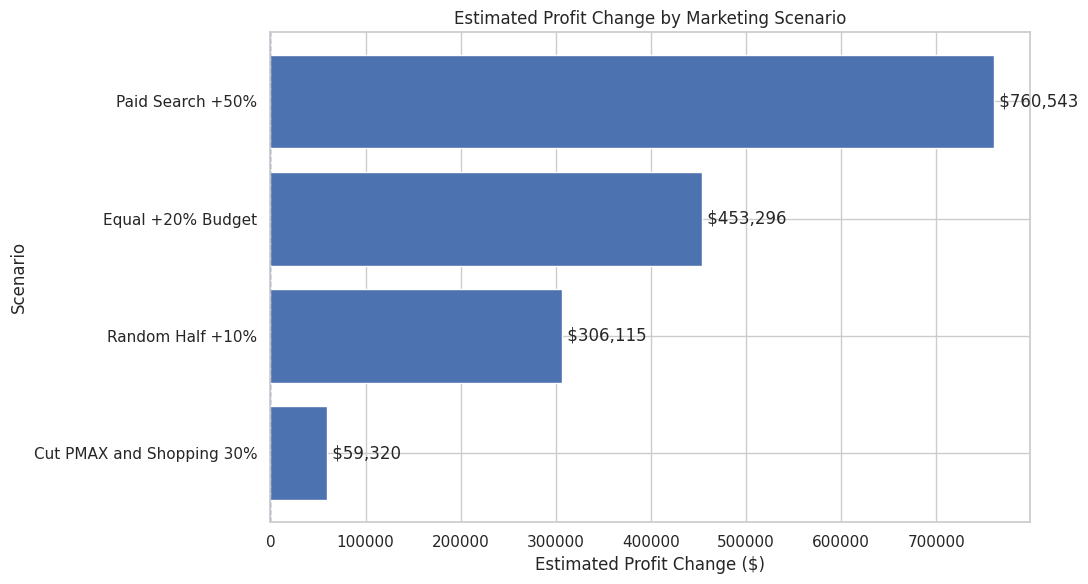

In [151]:
profit_plot_df = (
    scenario_comparison
    .sort_values(
        "Estimated Profit Change",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    profit_plot_df["Scenario"],
    profit_plot_df["Estimated Profit Change"],
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title(
    "Estimated Profit Change by Marketing Scenario"
)

ax.set_xlabel("Estimated Profit Change ($)")
ax.set_ylabel("Scenario")

for index, value in enumerate(
    profit_plot_df["Estimated Profit Change"]
):
    ax.text(
        value,
        index,
        f" ${value:,.0f}",
        va="center",
    )

plt.tight_layout()

fig.savefig(
    CHART_DIR / "scenario_profit_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

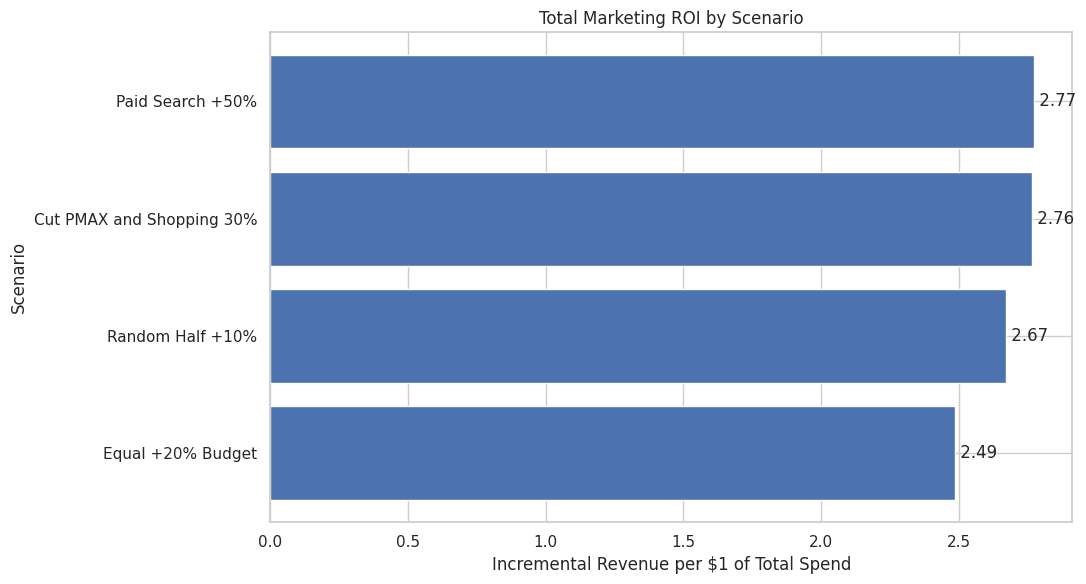

In [152]:
roi_plot_df = (
    scenario_comparison
    .sort_values(
        "Scenario Total ROI",
        ascending=True,
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(
    roi_plot_df["Scenario"],
    roi_plot_df["Scenario Total ROI"],
)

ax.set_title(
    "Total Marketing ROI by Scenario"
)

ax.set_xlabel(
    "Incremental Revenue per $1 of Total Spend"
)

ax.set_ylabel("Scenario")

for index, value in enumerate(
    roi_plot_df["Scenario Total ROI"]
):
    ax.text(
        value,
        index,
        f" {value:.2f}",
        va="center",
    )

plt.tight_layout()

fig.savefig(
    CHART_DIR / "scenario_total_roi_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Final Business Recommendation

The results support reallocating marketing investment rather than increasing
every channel equally.

Google Paid Search should receive the highest priority for additional budget.
A 50% increase in Paid Search spending generated an estimated $980,398 in
additional revenue and 11,608 additional purchases from only $219,855 of extra
investment. This produced an incremental ROI of approximately 4.46 and the
largest estimated profit increase among all tested scenarios.

Meta Facebook and Meta Instagram should remain important channels because they
generate substantial incremental purchases and maintain marginal ROI above
break-even. However, their already large share of total spending means future
increases should be controlled and evaluated regularly.

Google PMAX and Google Shopping appear relatively saturated. Reducing their
spending by 30% saved approximately $126,136 while sacrificing only $66,816 in
revenue, improving estimated profit by about $59,320.

Google Video should also be reviewed because both historical ROI and marginal
ROI were below break-even.

The recommended next-quarter strategy is:

1. Increase Google Paid Search investment.
2. Maintain or cautiously scale profitable Meta channels.
3. Reduce or hold Google PMAX, Google Shopping, and Google Video.
4. Avoid equal budget increases across all channels.
5. Re-estimate the MMM regularly as new campaign data becomes available.

These recommendations are based on modeled posterior estimates and should be
implemented gradually with campaign experiments and ongoing performance
monitoring.

In [154]:
from pathlib import Path

required_outputs = [
    # Task 1
    CHART_DIR / "daily_purchases.png",
    CHART_DIR / "weekly_media_spend_trends.png",
    CHART_DIR / "correlation_heatmap.png",

    # Task 2
    TABLE_DIR / "clean_modeling_dataset.csv",
    TABLE_DIR / "train_dataset.csv",
    TABLE_DIR / "validation_dataset.csv",

    # Task 3
    CHART_DIR / "meridian_actual_vs_expected.png",
    CHART_DIR / "meridian_adstock_decay.png",
    CHART_DIR / "meridian_paid_channel_contribution.png",
    TABLE_DIR / "meridian_model_metrics.csv",
    TABLE_DIR / "meridian_channel_contribution.csv",
    TABLE_DIR / "meridian_adstock_summary.csv",
    TABLE_DIR / "meridian_saturation_summary.csv",

    # Task 4
    TABLE_DIR / "meridian_roi_mroi_clean.csv",
    CHART_DIR / "meridian_roi_mroi_comparison.png",

    # Task 5
    TABLE_DIR / "shap_feature_importance.csv",
    TABLE_DIR / "shap_vs_meridian_contribution.csv",
    CHART_DIR / "shap_summary_beeswarm.png",
    CHART_DIR / "shap_feature_importance.png",

    # Task 6
    TABLE_DIR / "final_scenario_comparison.csv",
    CHART_DIR / "scenario_profit_comparison.png",
    CHART_DIR / "scenario_total_roi_comparison.png",

    # SHAP model
    OUTPUT_DIR / "models" / "shap_surrogate_random_forest.joblib",
]

audit_results = []

for file_path in required_outputs:
    audit_results.append({
        "file": str(
    file_path.relative_to(OUTPUT_DIR.parent)
),
        "exists": file_path.exists(),
        "size_kb": (
            round(file_path.stat().st_size / 1024, 2)
            if file_path.exists()
            else 0
        ),
    })

audit_df = pd.DataFrame(audit_results)

display(audit_df)

missing_files = audit_df.loc[
    ~audit_df["exists"],
    "file",
].tolist()

if missing_files:
    print("\nMissing files:")
    for file in missing_files:
        print("-", file)
else:
    print("\nAll required analytical outputs exist.")

,file,exists,size_kb
0,outputs/charts/daily_purchases.png,True,391.63
1,outputs/charts/weekly_media_spend_trends.png,True,648.78
2,outputs/charts/correlation_heatmap.png,True,590.15
3,outputs/tables/clean_modeling_dataset.csv,True,401.59
4,outputs/tables/train_dataset.csv,True,306.99
5,outputs/tables/validation_dataset.csv,True,86.44
6,outputs/charts/meridian_actual_vs_expected.png,True,477.15
7,outputs/charts/meridian_adstock_decay.png,True,704.98
8,outputs/charts/meridian_paid_channel_contribut...,True,157.59
9,outputs/tables/meridian_model_metrics.csv,True,0.19



All required analytical outputs exist.
